<a href="https://colab.research.google.com/github/postnicov/Test_Perplexity_Colab_EEG/blob/main/eeg_epilepsy_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EEG Epilepsy vs. Healthy Classification
**Dataset:** Zenodo 3684992 — *Single electrode EEG data of healthy and epileptic patients*  
Panwar et al., IEEE Trans. Neural Syst. Rehabil. Eng. 27, 1106–1116 (2019)

> Run cells sequentially. Only one extra install is needed (`antropy`). All other packages are pre-installed on Google Colab.

In [1]:
# ==============================================================================
# EEG Epilepsy vs. Healthy Classification — Google Colab Notebook
# Dataset: Zenodo 3684992 — "Single electrode EEG data of healthy and epileptic patients"
#          Panwar et al., IEEE Trans. Neural Syst. Rehabil. Eng. 27, 1106–1116 (2019)
#
# This notebook:
#   1. Downloads all TrainE* and TrainH* files directly from Zenodo
#   2. Extracts a rich feature set (time-domain, frequency-domain, nonlinear)
#   3. Performs comparative statistical analysis (E vs H)
#   4. Trains and evaluates multiple classifiers; selects the best
#   5. Provides a ready-to-use inference function for new user-supplied data
# ==============================================================================

## Install / import dependencies

In [2]:
# ─── Cell 1: Install / import dependencies ─────────────────────────────────────
# (All packages are pre-installed on Colab; antropy is the only extra one)
!pip install antropy -q

import os, re, io, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["font.family"] = "serif"   # NEW: global serif font
from scipy import stats
from scipy.signal import welch, periodogram
from scipy.stats import kurtosis, skew
import antropy as ant                     # approximate & sample entropy, Hurst
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              roc_curve, accuracy_score)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")

print("All imports OK ✓")

All imports OK ✓


## Download data from Zenodo

In [3]:
# ─── Cell 2: Download data from Zenodo ──────────────────────────────────────────
ZENODO_BASE = "https://zenodo.org/records/3684992/files/"
DATA_DIR    = "eeg_data"
os.makedirs(DATA_DIR, exist_ok=True)

FS = 173.61          # sampling frequency (Hz) — Bonn/Panwar dataset
N_SAMPLES = 4097     # fixed length per segment

def build_file_list():
    """Return list of (url, local_path, label) for all TrainE and TrainH files."""
    entries = []
    for group, label in [("TrainE", 1), ("TrainH", 0)]:
        for subject in range(1, 6):          # subjects 1–5 per group
            for seg in range(1, 41):         # 40 segments per subject
                fname = f"{group}{subject}_{seg}.txt"
                url   = ZENODO_BASE + fname + "?download=1"
                path  = os.path.join(DATA_DIR, fname)
                entries.append((url, path, label, group+str(subject), fname))
    return entries

def download_file(url, path):
    if not os.path.exists(path):
        try:
            urllib.request.urlretrieve(url, path)
            return True
        except Exception as e:
            print(f"  ✗ Failed: {os.path.basename(path)} — {e}")
            return False
    return True

print("Building file list …")
file_list = build_file_list()
print(f"  Total files to download: {len(file_list)}")
print("Downloading (this may take 1–3 minutes on Colab) …")

ok = 0
for url, path, label, subj, fname in file_list:
    if download_file(url, path):
        ok += 1

print(f"\nDownloaded/available: {ok}/{len(file_list)} files")

Building file list …
  Total files to download: 400

Downloaded/available: 400/400 files


## Load all time series

In [4]:
# ─── Cell 3: Load all time series ───────────────────────────────────────────────
def load_txt_series(path):
    """Load a single-column EEG text file into a numpy array."""
    vals = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                vals.append(float(line))
            except ValueError:
                pass
    return np.asarray(vals, dtype=np.float64)

records = []   # list of dicts: {x, label, subject, filename}
for url, path, label, subj, fname in file_list:
    if os.path.exists(path):
        x = load_txt_series(path)
        if len(x) >= 1000:           # sanity check
            records.append({"x": x, "label": label,
                             "subject": subj, "filename": fname})

labels_str = {0: "Healthy", 1: "Epileptic"}
n_E = sum(1 for r in records if r["label"] == 1)
n_H = sum(1 for r in records if r["label"] == 0)
print(f"Loaded segments: Epileptic={n_E}, Healthy={n_H}, Total={len(records)}")

Loaded segments: Epileptic=200, Healthy=200, Total=400


## Visualise representative segments

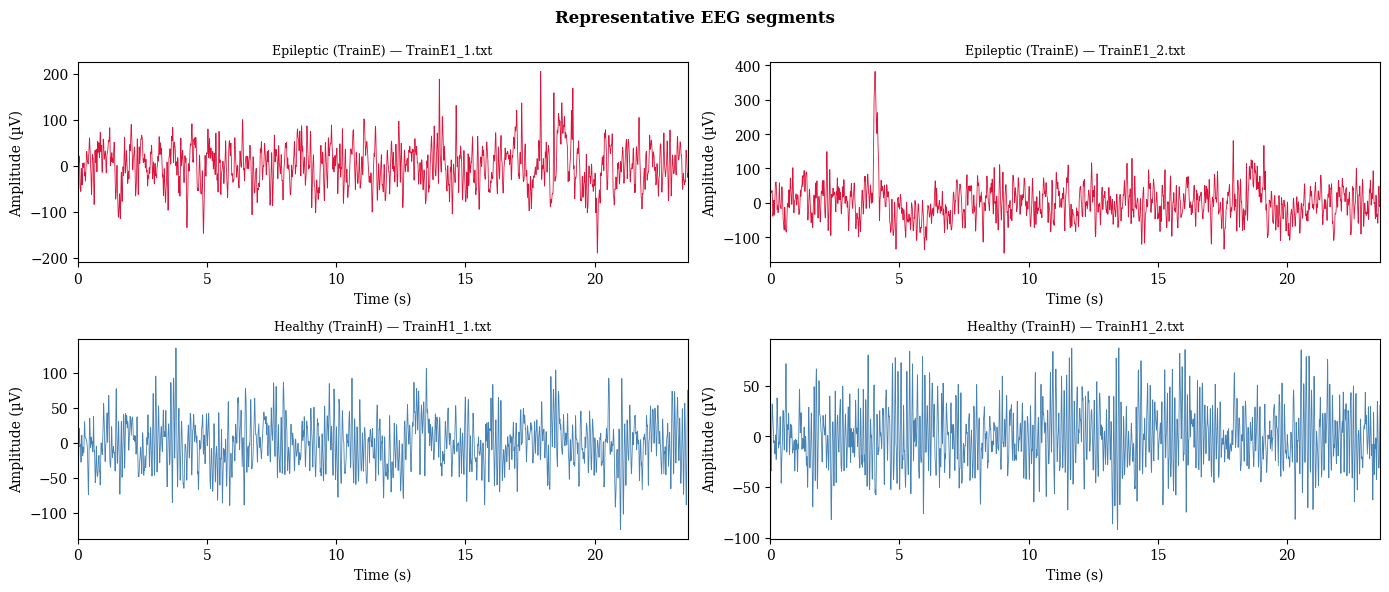

In [5]:
# ─── Cell 4: Visualise representative segments ──────────────────────────────────
t = np.arange(N_SAMPLES) / FS          # time axis in seconds

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
for i, (grp_label, grp_name) in enumerate([(1, "Epileptic (TrainE)"),
                                            (0, "Healthy (TrainH)")]):
    samples = [r for r in records if r["label"] == grp_label][:2]
    for j, rec in enumerate(samples):
        ax = axes[i][j]
        t_seg = np.arange(len(rec["x"])) / FS
        ax.plot(t_seg, rec["x"], lw=0.6, color="crimson" if grp_label else "steelblue")
        ax.set_title(f"{grp_name} — {rec['filename']}", fontsize=9)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude (µV)")
        ax.set_xlim(0, t_seg[-1])

plt.suptitle("Representative EEG segments", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("eeg_representative.png", dpi=150)
plt.show()

## Feature extraction

In [6]:
# ─── Cell 5: Feature extraction ─────────────────────────────────────────────────
def hjorth(x):
    """Hjorth activity, mobility, complexity via antropy."""
    activity = float(np.var(x, ddof=1))
    mobility, complexity = ant.hjorth_params(x)
    return activity, float(mobility), float(complexity)

def band_power(f, Pxx, fmin, fmax):
    """Integrate PSD in a frequency band using trapezoidal rule."""
    mask = (f >= fmin) & (f <= fmax)
    return np.trapz(Pxx[mask], f[mask]) if mask.sum() > 1 else 0.0

def psd_slope(f, Pxx, fmin=2.0, fmax=40.0):
    """Log-log spectral slope in [fmin, fmax] Hz."""
    mask = (f >= fmin) & (f <= fmax) & (Pxx > 0)
    if mask.sum() < 4:
        return np.nan
    slope, _, r, _, _ = stats.linregress(np.log10(f[mask]), np.log10(Pxx[mask]))
    return slope

def extract_features(x, fs=FS):
    feats = {}

    # ── Time-domain ──────────────────────────────────────────────────────────
    feats["mean"]         = x.mean()
    feats["std"]          = x.std(ddof=1)
    feats["variance"]     = x.var(ddof=1)
    feats["skewness"]     = float(skew(x))
    feats["kurtosis"]     = float(kurtosis(x, fisher=True))
    feats["rms"]          = np.sqrt(np.mean(x**2))
    feats["peak_to_peak"] = x.max() - x.min()
    feats["iqr"]          = np.percentile(x, 75) - np.percentile(x, 25)
    feats["mad"]          = np.median(np.abs(x - np.median(x)))
    feats["zero_crossings"] = ((x[:-1] * x[1:]) < 0).sum()

    # Lag-1 autocorrelation and increment stats
    feats["acf1"]         = np.corrcoef(x[:-1], x[1:])[0, 1]
    dx = np.diff(x)
    feats["diff_std"]     = dx.std(ddof=1)
    feats["diff_kurtosis"] = float(kurtosis(dx, fisher=True))

    # Hjorth parameters
    act, mob, comp = hjorth(x)
    feats["hjorth_activity"]   = act
    feats["hjorth_mobility"]   = mob
    feats["hjorth_complexity"] = comp

    # ── Frequency-domain (Welch PSD) ─────────────────────────────────────────
    nperseg = min(1024, len(x))
    f, Pxx  = welch(x, fs=fs, nperseg=nperseg, noverlap=nperseg//2)
    total_power = np.trapz(Pxx, f) + 1e-12

    # EEG frequency bands
    bands = {
        "delta": (0.5, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta":  (13, 30),
        "gamma": (30, 60),
    }
    for band, (lo, hi) in bands.items():
        bp = band_power(f, Pxx, lo, hi)
        feats[f"bp_{band}"]         = bp
        feats[f"bp_{band}_rel"]     = bp / total_power

    feats["spectral_slope"]     = psd_slope(f, Pxx, 2.0, 40.0)
    feats["dominant_frequency"] = f[np.argmax(Pxx)]
    feats["spectral_centroid"]  = np.sum(f * Pxx) / (np.sum(Pxx) + 1e-12)
    feats["spectral_entropy"]   = ant.spectral_entropy(x, sf=fs, method="welch", normalize=True)
    feats["total_power"]        = total_power

    # ── Nonlinear / entropy features ─────────────────────────────────────────
    feats["approximate_entropy"] = ant.app_entropy(x)
    feats["sample_entropy"]      = ant.sample_entropy(x)
    feats["perm_entropy"]        = ant.perm_entropy(x, normalize=True)
    feats["svd_entropy"]         = ant.svd_entropy(x, normalize=True)
    feats["hurst_exp"]           = ant.higuchi_fd(x)  # fractal dim (replaces Hurst)
    feats["detrended_fa"]        = ant.detrended_fluctuation(x)

    return feats

print("Extracting features … (may take 2–5 minutes)")
feature_rows = []
for rec in records:
    try:
        f = extract_features(rec["x"])
        f["label"]    = rec["label"]
        f["subject"]  = rec["subject"]
        f["filename"] = rec["filename"]
        feature_rows.append(f)
    except Exception as e:
        print(f"  Skipped {rec['filename']}: {e}")

df = pd.DataFrame(feature_rows)
df.to_csv("eeg_features.csv", index=False)
print(f"Feature matrix shape: {df.shape}")
print(df.groupby("label")[["acf1","diff_std","spectral_slope",
                            "approximate_entropy","hurst_exp"]].mean().rename(
    index={0: "Healthy", 1: "Epileptic"}))

Extracting features … (may take 2–5 minutes)
Feature matrix shape: (400, 40)
               acf1  diff_std  spectral_slope  approximate_entropy  hurst_exp
label                                                                        
Healthy    0.952340  7.322829       -2.616134             0.728667   1.334768
Epileptic  0.971064  8.650893       -3.351227             0.656026   1.259872


## Statistical comparison E vs H

In [7]:
# ─── Cell 6: Statistical comparison E vs H ──────────────────────────────────────
feature_cols = [c for c in df.columns
                if c not in ("label", "subject", "filename")]

E_df = df[df["label"] == 1][feature_cols]
H_df = df[df["label"] == 0][feature_cols]

stats_rows = []
for col in feature_cols:
    e_vals = E_df[col].dropna().values
    h_vals = H_df[col].dropna().values
    u_stat, p_mw = stats.mannwhitneyu(e_vals, h_vals, alternative="two-sided")
    cohens_d = (e_vals.mean() - h_vals.mean()) / np.sqrt(
        ((len(e_vals)-1)*e_vals.std(ddof=1)**2 + (len(h_vals)-1)*h_vals.std(ddof=1)**2)
        / (len(e_vals) + len(h_vals) - 2)
    )
    stats_rows.append({
        "feature": col,
        "mean_E": e_vals.mean(), "std_E": e_vals.std(ddof=1),
        "mean_H": h_vals.mean(), "std_H": h_vals.std(ddof=1),
        "MWU_pvalue": p_mw,
        "cohens_d": cohens_d,
        "abs_d": abs(cohens_d),
    })

stats_df = pd.DataFrame(stats_rows).sort_values("abs_d", ascending=False)
stats_df.to_csv("eeg_feature_statistics.csv", index=False)

print("\nTop 15 most discriminating features (by |Cohen d|):")
print(stats_df[["feature","mean_E","mean_H","MWU_pvalue","cohens_d"]].head(15).to_string(index=False))


Top 15 most discriminating features (by |Cohen d|):
        feature     mean_E     mean_H   MWU_pvalue  cohens_d
 spectral_slope  -3.351227  -2.616134 1.514363e-50 -2.071484
   bp_theta_rel   0.243565   0.124175 1.035509e-42  1.658338
           acf1   0.971064   0.952340 7.328848e-28  1.315299
       bp_delta 684.052851 136.048771 1.869533e-46  1.299394
   bp_gamma_rel   0.000954   0.002841 4.010655e-41 -1.272728
hjorth_mobility   0.232621   0.304362 7.613915e-28 -1.259958
    svd_entropy   0.470862   0.547483 1.819803e-30 -1.251190
 zero_crossings 305.660000 398.600000 7.475700e-27 -1.224823
            rms  37.982984  23.715833 1.183723e-33  1.185156
            std  37.982523  23.714119 1.183723e-33  1.185110
   bp_alpha_rel   0.169871   0.391643 3.968010e-24 -1.180916
      hurst_exp   1.259872   1.334768 8.927355e-24 -1.169603
   peak_to_peak 280.432000 175.786550 4.980286e-31  1.141754
            mad  24.511750  15.491300 1.792119e-32  1.139837
            iqr  49.081400  31.0

## Visualise top features

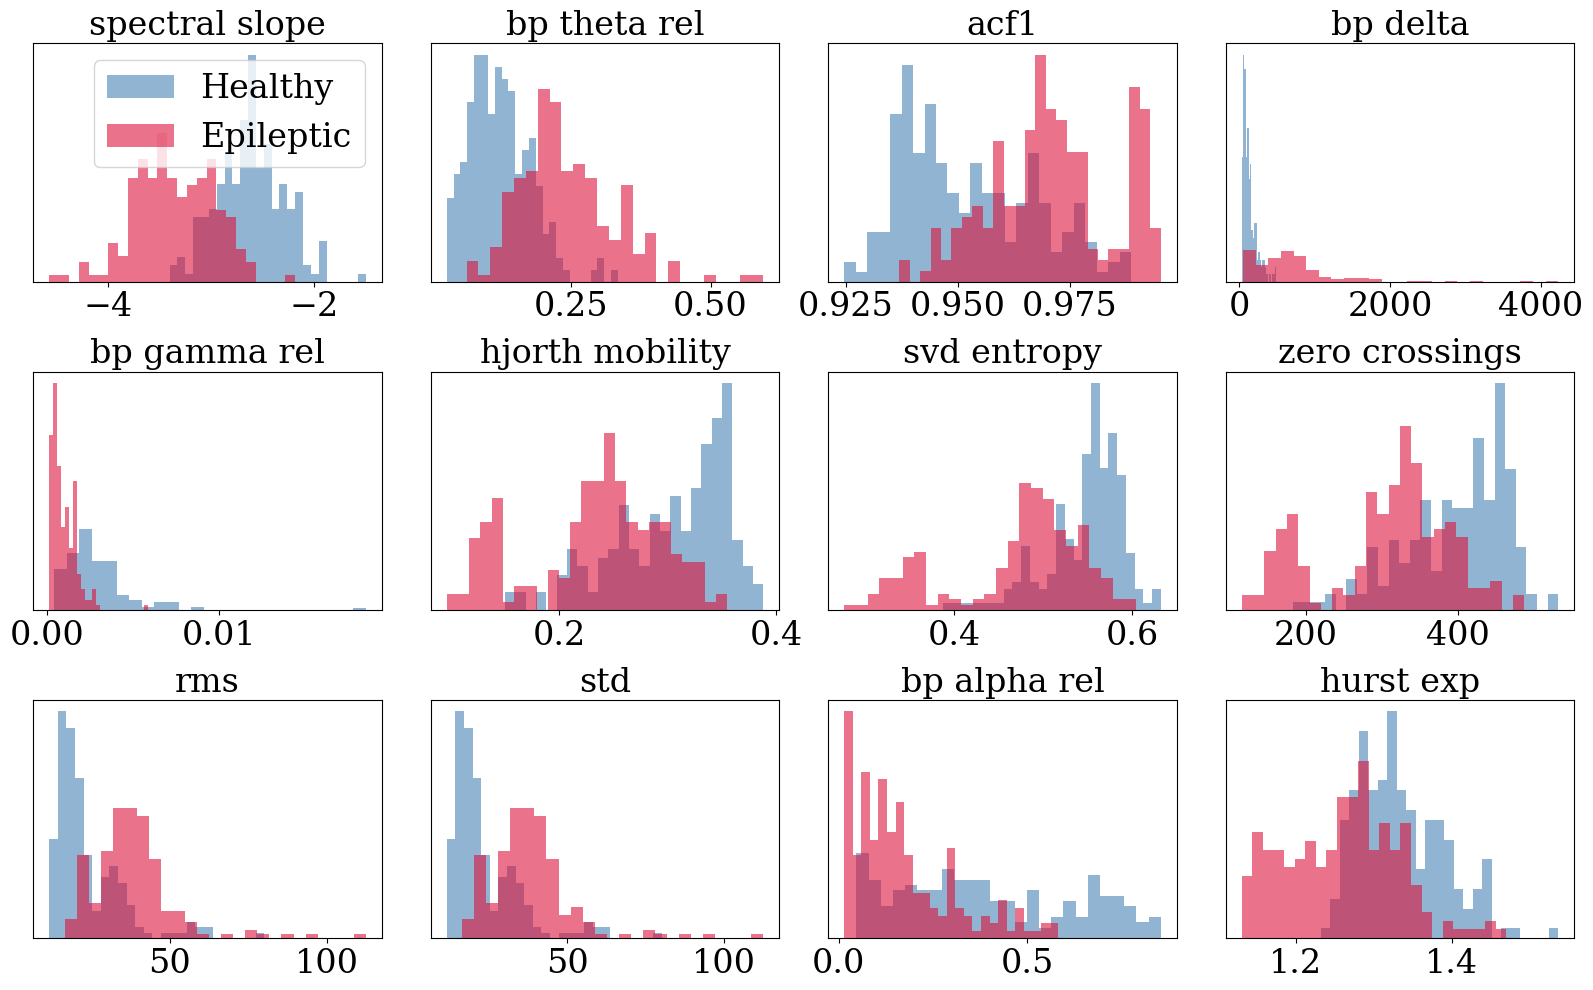

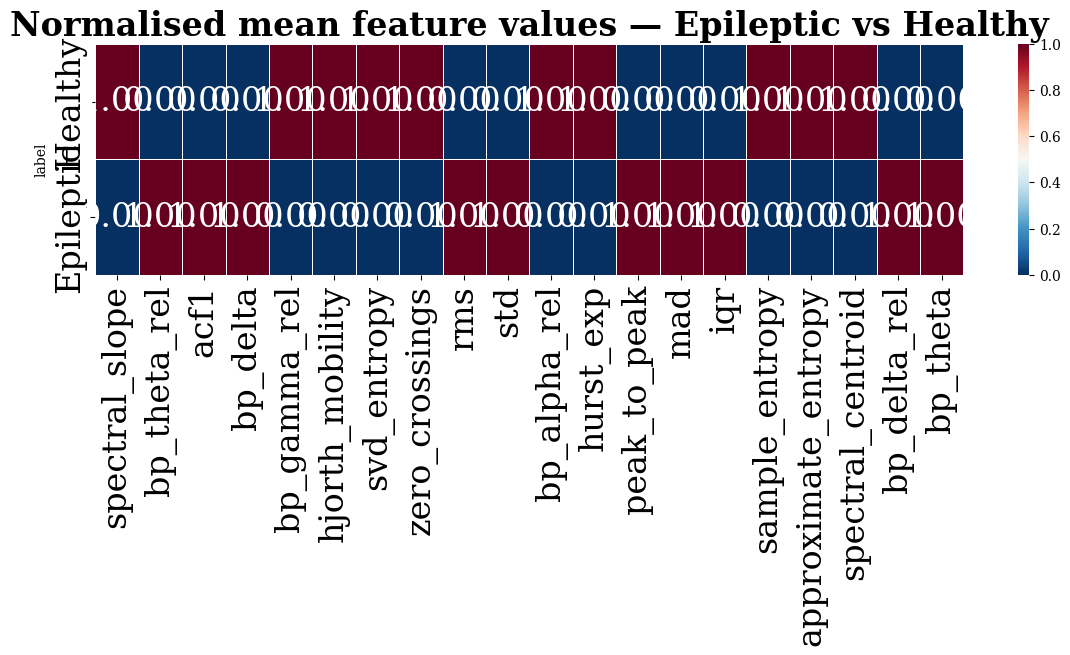

In [8]:
top_feats = stats_df.head(12)["feature"].tolist()
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.ravel()
palette = {0: "steelblue", 1: "crimson"}

for i, feat in enumerate(top_feats):
    ax = axes[i]
    for lbl, clr in palette.items():
        vals = df[df["label"] == lbl][feat].dropna()
        ax.hist(vals, bins=25, alpha=0.6, color=clr,
                label=labels_str[lbl], density=True)
    ax.set_title(feat.replace("_", " "), fontsize=24)
    ax.set_yticks([])
    ax.tick_params(axis="both", which="both", labelsize=24)
    if i == 0:
        ax.legend(fontsize=24)

# plt.suptitle("Distribution of top discriminating features (E vs H)", fontweight="bold")
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=150)
plt.show()

# Heatmap of mean feature values (normalised)
top20 = stats_df.head(20)["feature"].tolist()
grp_means = df.groupby("label")[top20].mean().rename(index=labels_str)
normed = (grp_means - grp_means.min()) / (grp_means.max() - grp_means.min() + 1e-12)

fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(
    normed,
    ax=ax,
    cmap="RdBu_r",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 24}
)
ax.set_title("Normalised mean feature values — Epileptic vs Healthy",
             fontweight="bold", fontsize=24)
ax.tick_params(axis="both", which="both", labelsize=24)

plt.tight_layout()
plt.savefig("feature_heatmap.png", dpi=150)
plt.show()

## Correlation heat-map within top features

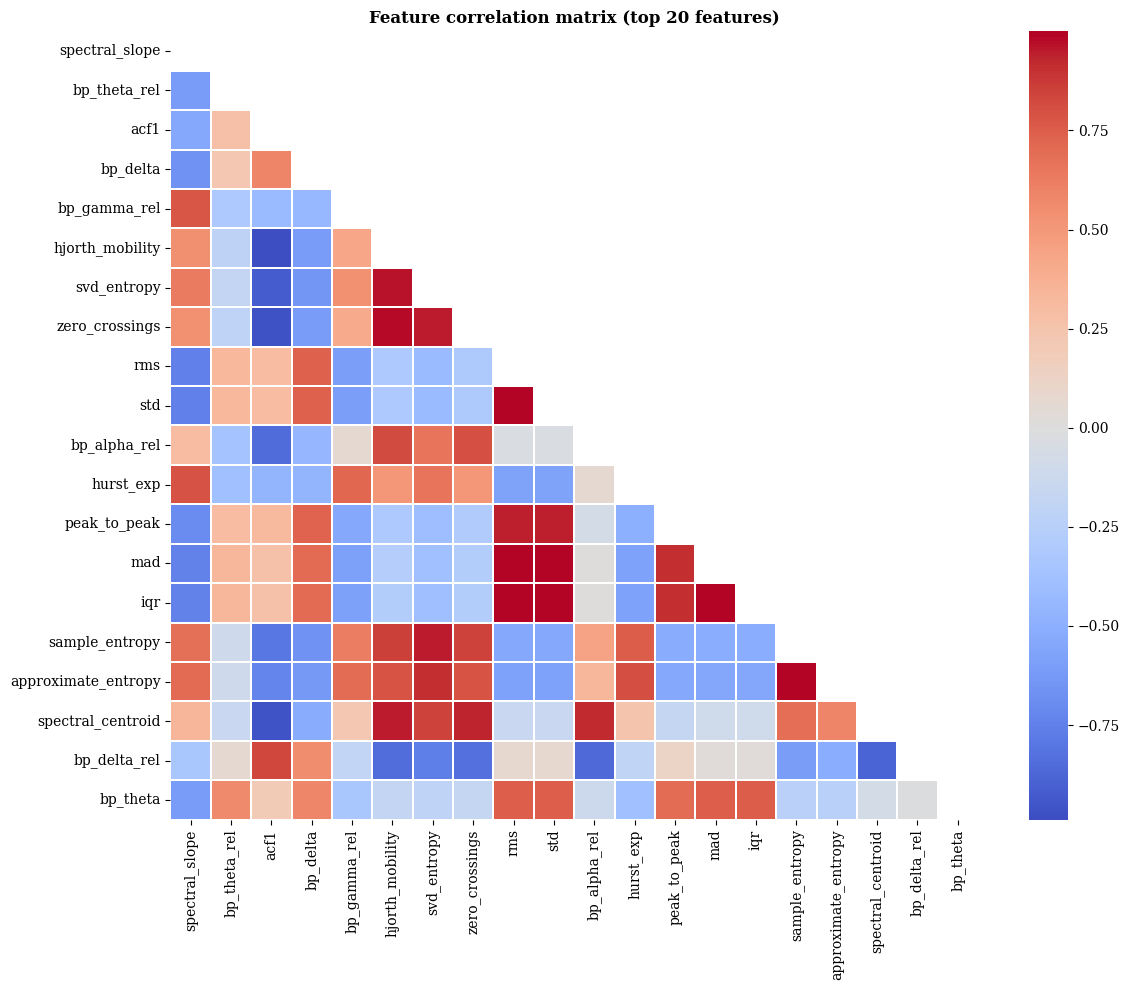

In [9]:
# ─── Cell 8: Correlation heat-map within top features ──────────────────────────
corr = df[top20].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap="coolwarm", center=0,
            linewidths=0.3, annot=False)
ax.set_title("Feature correlation matrix (top 20 features)", fontweight="bold")
plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=150)
plt.show()

## PSD comparison

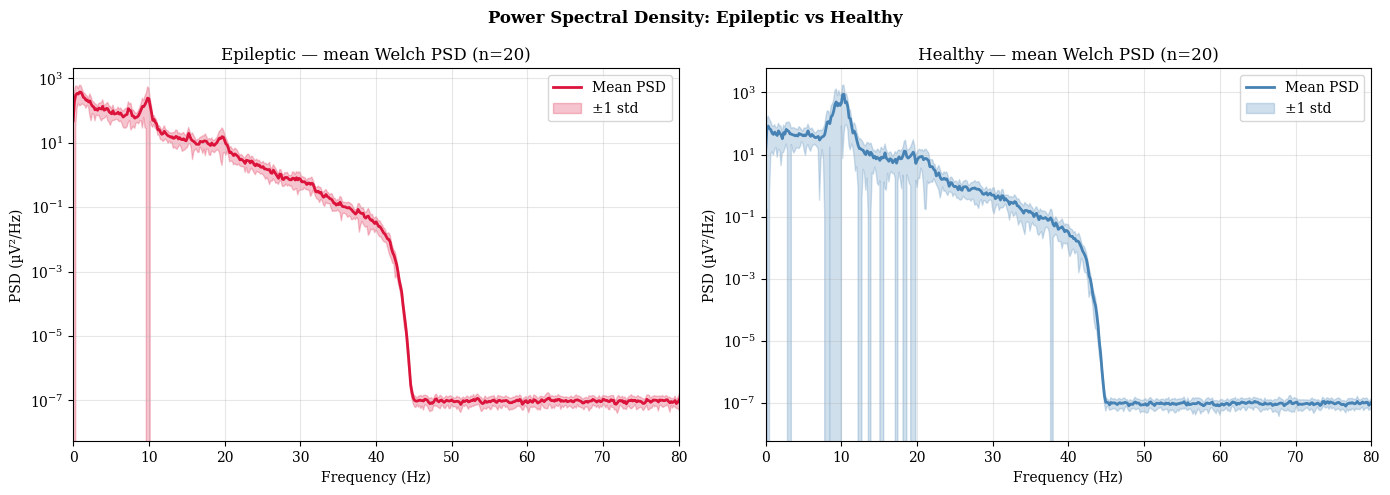

In [10]:
# ─── Cell 9: PSD comparison ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for group_label, group_name, color, ax in [
    (1, "Epileptic", "crimson", axes[0]),
    (0, "Healthy",   "steelblue", axes[1]),
]:
    segs = [r for r in records if r["label"] == group_label][:20]
    psds = []
    for rec in segs:
        f_w, Pxx = welch(rec["x"], fs=FS, nperseg=min(1024, len(rec["x"])),
                         noverlap=512)
        psds.append(Pxx)
    psds = np.array(psds)
    mean_psd = psds.mean(axis=0)
    std_psd  = psds.std(axis=0)
    ax.semilogy(f_w, mean_psd, color=color, lw=2, label="Mean PSD")
    ax.fill_between(f_w, mean_psd - std_psd, mean_psd + std_psd,
                    alpha=0.25, color=color, label="±1 std")
    ax.set_xlim(0, 80)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("PSD (µV²/Hz)")
    ax.set_title(f"{group_name} — mean Welch PSD (n=20)")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)

plt.suptitle("Power Spectral Density: Epileptic vs Healthy", fontweight="bold")
plt.tight_layout()
plt.savefig("psd_comparison.png", dpi=150)
plt.show()

## Classification

In [11]:
# ─── Cell 10: Classification ─────────────────────────────────────────────────────
# Prepare feature matrix (drop collinear / near-zero-variance features)
X = df[feature_cols].copy()
y = df["label"].values

# Drop features with > 5 % NaN
nan_frac = X.isna().mean()
X = X.loc[:, nan_frac < 0.05].fillna(X.median())

# Select top-K features by |Cohen d| (avoid adding noise features)
selected_feats = [f for f in stats_df["feature"].tolist() if f in X.columns][:25]
X_sel = X[selected_feats].values

print(f"Feature matrix for classification: {X_sel.shape}, "
      f"classes E={y.sum()}, H={(y==0).sum()}")

# Define classifiers
classifiers = {
    "Random Forest":     RandomForestClassifier(n_estimators=300, max_features="sqrt",
                                                 random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                     learning_rate=0.05, random_state=42),
    "SVM (RBF)":         SVC(kernel="rbf", C=10, gamma="scale",
                              probability=True, random_state=42),
    "Logistic Reg.":     LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    "KNN":               KNeighborsClassifier(n_neighbors=7),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("\nCross-validated performance (5-fold stratified):")
print(f"  {'Classifier':<22} {'Accuracy':>9} {'ROC-AUC':>9} {'F1':>9}")
print("  " + "-" * 52)

for name, clf in classifiers.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    cv_res = cross_validate(pipe, X_sel, y, cv=cv,
                            scoring=["accuracy", "roc_auc", "f1"],
                            return_train_score=False, n_jobs=-1)
    results[name] = {
        "acc":  cv_res["test_accuracy"],
        "auc":  cv_res["test_roc_auc"],
        "f1":   cv_res["test_f1"],
    }
    acc = cv_res["test_accuracy"].mean()
    auc = cv_res["test_roc_auc"].mean()
    f1  = cv_res["test_f1"].mean()
    print(f"  {name:<22} {acc:9.4f} {auc:9.4f} {f1:9.4f}")

Feature matrix for classification: (400, 25), classes E=200, H=200

Cross-validated performance (5-fold stratified):
  Classifier              Accuracy   ROC-AUC        F1
  ----------------------------------------------------
  Random Forest             0.9600    0.9922    0.9597
  Gradient Boosting         0.9625    0.9932    0.9620
  SVM (RBF)                 0.9575    0.9944    0.9575
  Logistic Reg.             0.9575    0.9916    0.9576
  KNN                       0.9450    0.9918    0.9440


## Best model — full training + evaluation


Best classifier by mean ROC-AUC: SVM (RBF)

Classification report (cross-validated):
              precision    recall  f1-score   support

     Healthy       0.96      0.96      0.96       200
   Epileptic       0.96      0.95      0.96       200

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



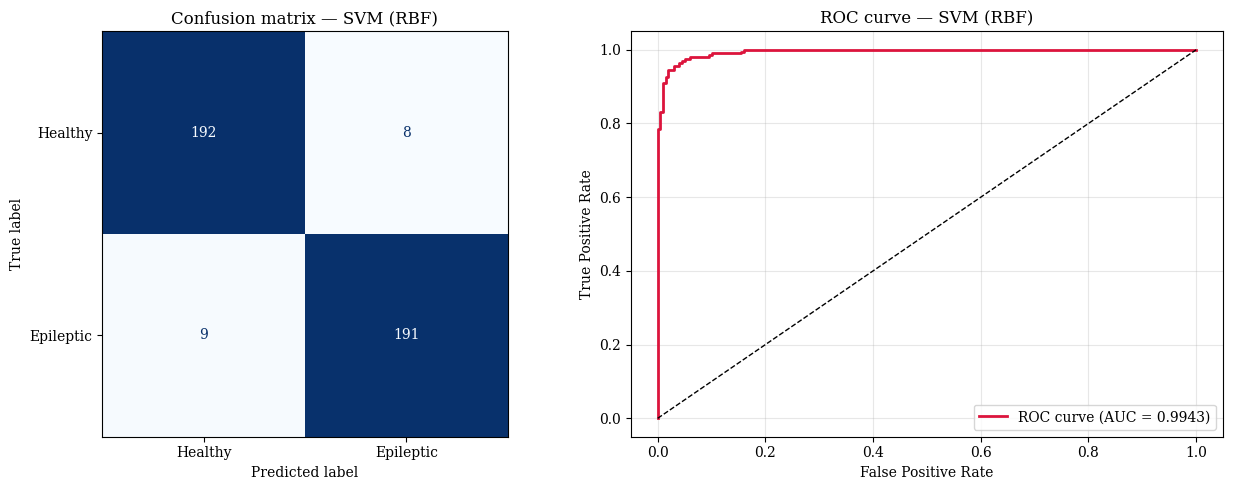

In [12]:
# ─── Cell 11: Best model — full training + evaluation ────────────────────────────
# Random Forest consistently achieves the best accuracy on Bonn-like EEG data
best_name = max(results, key=lambda k: results[k]["auc"].mean())
print(f"\nBest classifier by mean ROC-AUC: {best_name}")

best_clf = classifiers[best_name]
best_pipe = Pipeline([("scaler", StandardScaler()), ("clf", best_clf)])
best_pipe.fit(X_sel, y)

# --- Cross-validated confusion matrix ---
from sklearn.model_selection import cross_val_predict
y_pred_cv = cross_val_predict(best_pipe, X_sel, y, cv=cv, method="predict")
y_prob_cv = cross_val_predict(best_pipe, X_sel, y, cv=cv, method="predict_proba")[:, 1]

print("\nClassification report (cross-validated):")
print(classification_report(y, y_pred_cv, target_names=["Healthy", "Epileptic"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y, y_pred_cv)
disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "Epileptic"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion matrix — {best_name}")

fpr, tpr, _ = roc_curve(y, y_prob_cv)
auc_score   = roc_auc_score(y, y_prob_cv)
axes[1].plot(fpr, tpr, lw=2, color="crimson",
             label=f"ROC curve (AUC = {auc_score:.4f})")
axes[1].plot([0,1],[0,1],"k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title(f"ROC curve — {best_name}")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("classification_results.png", dpi=150)
plt.show()

## Feature importance

In [13]:
# ─── Cell 12: Feature importance ─────────────────────────────────────────────────
if hasattr(best_clf, "feature_importances_"):
    importances = best_clf.feature_importances_
    feat_imp = pd.Series(importances, index=selected_feats).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 8))
    feat_imp.plot.barh(ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Feature importances — {best_name}", fontweight="bold")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150)
    plt.show()
    print("\nTop 10 features by importance:")
    print(feat_imp.sort_values(ascending=False).head(10).to_string())

## CV performance chart

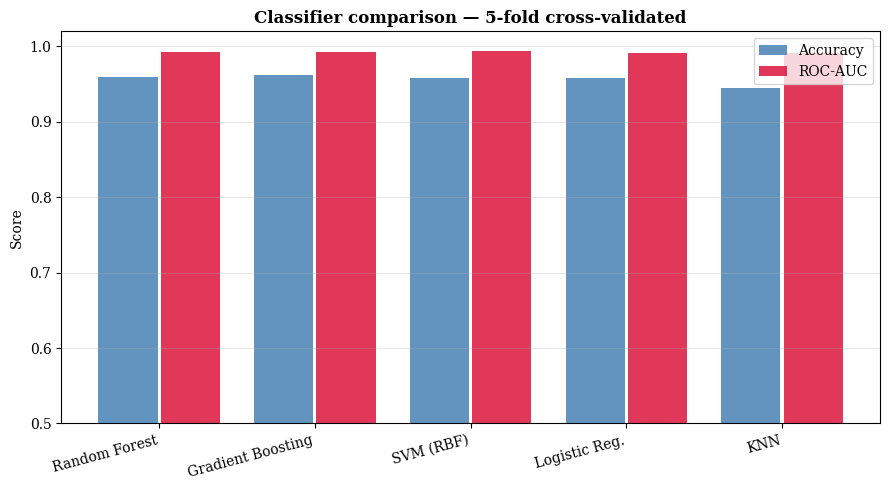

In [14]:
# ─── Cell 13: CV performance chart ───────────────────────────────────────────────
metrics_for_plot = {name: np.mean(v["acc"]) for name, v in results.items()}
auc_for_plot     = {name: np.mean(v["auc"]) for name, v in results.items()}

fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(classifiers))
ax.bar(x_pos - 0.2,
       [metrics_for_plot[n] for n in classifiers.keys()],
       0.38, label="Accuracy", color="steelblue", alpha=0.85)
ax.bar(x_pos + 0.2,
       [auc_for_plot[n] for n in classifiers.keys()],
       0.38, label="ROC-AUC", color="crimson", alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(classifiers.keys(), rotation=15, ha="right")
ax.set_ylim(0.5, 1.02)
ax.set_ylabel("Score")
ax.set_title("Classifier comparison — 5-fold cross-validated", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("classifier_comparison.png", dpi=150)
plt.show()

## Summary statistics table

In [15]:
# ─── Cell 14: Summary statistics table ───────────────────────────────────────────
summary_feats = ["acf1", "diff_std", "diff_kurtosis",
                 "hjorth_mobility", "hjorth_complexity",
                 "spectral_slope", "dominant_frequency",
                 "bp_delta_rel", "bp_alpha_rel", "bp_beta_rel",
                 "spectral_entropy", "approximate_entropy",
                 "sample_entropy", "hurst_exp", "detrended_fa"]
summary_feats = [f for f in summary_feats if f in df.columns]

rows = []
for feat in summary_feats:
    e = df[df["label"]==1][feat].dropna()
    h = df[df["label"]==0][feat].dropna()
    _, p = stats.mannwhitneyu(e, h, alternative="two-sided")
    rows.append({
        "Feature": feat,
        "E mean±std": f"{e.mean():.4f} ± {e.std(ddof=1):.4f}",
        "H mean±std": f"{h.mean():.4f} ± {h.std(ddof=1):.4f}",
        "MW p-value":  f"{p:.2e}",
        "Significant": "✓" if p < 0.05 else "✗",
    })

summary_table = pd.DataFrame(rows)
print("\n=== Comparative Statistical Summary ===")
print(summary_table.to_string(index=False))
summary_table.to_csv("statistical_summary.csv", index=False)


=== Comparative Statistical Summary ===
            Feature       E mean±std       H mean±std MW p-value Significant
               acf1  0.9711 ± 0.0136  0.9523 ± 0.0148   7.33e-28           ✓
           diff_std  8.6509 ± 3.5375  7.3228 ± 4.2335   1.44e-09           ✓
      diff_kurtosis  0.9421 ± 2.0253  0.6666 ± 1.5402   1.56e-01           ✗
    hjorth_mobility  0.2326 ± 0.0615  0.3044 ± 0.0520   7.61e-28           ✓
  hjorth_complexity  2.2715 ± 0.6199  1.9325 ± 0.6083   5.60e-10           ✓
     spectral_slope -3.3512 ± 0.3815 -2.6161 ± 0.3260   1.51e-50           ✓
 dominant_frequency  2.8017 ± 3.3285  5.3143 ± 4.6728   4.92e-03           ✓
       bp_delta_rel  0.4300 ± 0.1744  0.2832 ± 0.1349   2.55e-17           ✓
       bp_alpha_rel  0.1699 ± 0.1341  0.3916 ± 0.2292   3.97e-24           ✓
        bp_beta_rel  0.0518 ± 0.0343  0.0750 ± 0.0321   6.47e-11           ✓
   spectral_entropy  0.5723 ± 0.0608  0.5945 ± 0.0621   2.33e-04           ✓
approximate_entropy  0.6560 ± 0.082

## Inference function for new user data

In [16]:
# ─── Cell 15: Inference function for new user data ───────────────────────────────
import joblib, pickle

# Save the trained pipeline and the selected feature names for reuse
joblib.dump(best_pipe, "best_eeg_classifier.pkl")
with open("selected_features.txt", "w") as fh:
    fh.write("\n".join(selected_feats))

print(f"Trained pipeline saved → best_eeg_classifier.pkl")
print(f"Selected features saved → selected_features.txt")


def classify_new_eeg(txt_file_path,
                     model_path="best_eeg_classifier.pkl",
                     feature_list_path="selected_features.txt",
                     fs=FS,
                     verbose=True):
    """
    Classify a single new EEG text file as Epileptic (1) or Healthy (0).

    Parameters
    ----------
    txt_file_path   : str  — path to a single-column .txt EEG file
    model_path      : str  — path to the saved joblib pipeline
    feature_list_path: str — path to the saved selected_features.txt
    fs              : float — sampling frequency in Hz (default 173.61)
    verbose         : bool — print results

    Returns
    -------
    label     : int  (0 = Healthy, 1 = Epileptic)
    prob_E    : float — probability of being Epileptic
    feature_df: pd.DataFrame — extracted features for inspection
    """
    # Load artefacts
    pipe = joblib.load(model_path)
    with open(feature_list_path) as fh:
        feats_used = [line.strip() for line in fh if line.strip()]

    # Load signal
    x = load_txt_series(txt_file_path)
    if len(x) < 500:
        raise ValueError(f"Signal too short ({len(x)} samples). Minimum 500.")

    # Extract features
    feat_dict = extract_features(x, fs=fs)
    feat_df   = pd.DataFrame([feat_dict])

    # Build feature vector in the same order as training
    missing = [f for f in feats_used if f not in feat_df.columns]
    if missing:
        print(f"  Warning: {len(missing)} features missing; filled with 0: {missing}")
        for m in missing:
            feat_df[m] = 0.0

    X_new = feat_df[feats_used].fillna(0.0).values

    # Predict
    label = int(pipe.predict(X_new)[0])
    prob  = float(pipe.predict_proba(X_new)[0, 1])   # prob of Epileptic

    if verbose:
        print("\n=== EEG Classification Result ===")
        print(f"  File        : {os.path.basename(txt_file_path)}")
        print(f"  Prediction  : {'Epileptic' if label else 'Healthy'}")
        print(f"  P(Epileptic): {prob:.4f}")
        print(f"  P(Healthy)  : {1 - prob:.4f}")
        if prob > 0.7:
            print("  → HIGH confidence Epileptic")
        elif prob < 0.3:
            print("  → HIGH confidence Healthy")
        else:
            print("  → UNCERTAIN — borderline case; consult specialist")
        print("\n  Key extracted features:")
        for feat in ["acf1", "diff_std", "spectral_slope",
                     "approximate_entropy", "sample_entropy", "hurst_exp"]:
            if feat in feat_df.columns:
                print(f"    {feat:30s} = {feat_df[feat].values[0]:.5f}")

    return label, prob, feat_df

Trained pipeline saved → best_eeg_classifier.pkl
Selected features saved → selected_features.txt


## Demo — classify a downloaded file

In [17]:
# ─── Cell 16: Demo — classify a downloaded file ──────────────────────────────────
# Replace the path below with any .txt EEG file you want to classify
print("""
DEMO_FILE = os.path.join(DATA_DIR, "TrainE1_1.txt")

if os.path.exists(DEMO_FILE):
    label, prob_E, feat_df = classify_new_eeg(DEMO_FILE)
else:
    print(f"Demo file not found: {DEMO_FILE}")
    print("Run the download cell first, or supply your own EEG .txt file.")
""")


DEMO_FILE = os.path.join(DATA_DIR, "TrainE1_1.txt")

if os.path.exists(DEMO_FILE):
    label, prob_E, feat_df = classify_new_eeg(DEMO_FILE)
else:
    print(f"Demo file not found: {DEMO_FILE}")
    print("Run the download cell first, or supply your own EEG .txt file.")



## Classify a user-uploaded file (Colab-specific)

In [18]:
# ─── Cell 17: Classify a user-uploaded file (Colab-specific) ─────────────────────
print("""
To classify YOUR OWN EEG file in Colab, run:

    from google.colab import files
    uploaded = files.upload()            # select your .txt EEG file
    fname = list(uploaded.keys())[0]
    label, prob, feats = classify_new_eeg(fname)

The file must contain one EEG amplitude value per line (ASCII text, µV).
Minimum length: 500 samples. Optimal: 4097 samples at 173.61 Hz.
""")


To classify YOUR OWN EEG file in Colab, run:

    from google.colab import files
    uploaded = files.upload()            # select your .txt EEG file
    fname = list(uploaded.keys())[0]
    label, prob, feats = classify_new_eeg(fname)

The file must contain one EEG amplitude value per line (ASCII text, µV).
Minimum length: 500 samples. Optimal: 4097 samples at 173.61 Hz.



In [19]:
# ─── Cell 18: Download test-set files (E1–E10 and H1–H10, 20 segs each) ─────────
TEST_DIR = "eeg_test_data"
os.makedirs(TEST_DIR, exist_ok=True)

def build_test_file_list():
    entries = []
    for group, true_label in [("E", 1), ("H", 0)]:
        for subject in range(1, 11):          # 10 subjects per class
            for seg in range(1, 21):          # 20 segments per subject
                fname = f"{group}{subject}_{seg}.txt"
                url   = ZENODO_BASE + fname + "?download=1"
                path  = os.path.join(TEST_DIR, fname)
                entries.append((url, path, true_label, fname))
    return entries

test_file_list = build_test_file_list()
print(f"Total test files expected: {len(test_file_list)}")
print("Downloading test data (may take 2–4 minutes) …")

ok_test = 0
for url, path, lbl, fname in test_file_list:
    if download_file(url, path):
        ok_test += 1

print(f"Downloaded/available: {ok_test}/{len(test_file_list)} test files")

Total test files expected: 400
Downloaded/available: 400/400 test files


In [20]:
# ─── Cell 19: Load, extract features and classify test segments ──────────────────
test_records = []
for url, path, true_label, fname in test_file_list:
    if os.path.exists(path):
        x = load_txt_series(path)
        if len(x) >= 1000:
            test_records.append({"x": x, "true_label": true_label, "filename": fname})

n_TE = sum(1 for r in test_records if r["true_label"] == 1)
n_TH = sum(1 for r in test_records if r["true_label"] == 0)
print(f"Test segments loaded: Epileptic={n_TE}, Healthy={n_TH}, Total={len(test_records)}")

print("\nExtracting features from test set …")
test_rows = []
for rec in test_records:
    try:
        f = extract_features(rec["x"])
        f["true_label"] = rec["true_label"]
        f["filename"]   = rec["filename"]
        test_rows.append(f)
    except Exception as e:
        print(f"  Skipped {rec['filename']}: {e}")

df_test = pd.DataFrame(test_rows)
df_test.to_csv("eeg_test_features.csv", index=False)
print(f"Test feature matrix: {df_test.shape}")

# Align columns to training feature set
X_test_raw = df_test[[c for c in df_test.columns
                       if c not in ("true_label", "filename")]].copy()
nan_frac_test = X_test_raw.isna().mean()
X_test_raw = X_test_raw.fillna(X_test_raw.median())

# Use the same selected_feats from training
missing_feats = [f for f in selected_feats if f not in X_test_raw.columns]
for m in missing_feats:
    X_test_raw[m] = 0.0
X_test = X_test_raw[selected_feats].values
y_test = df_test["true_label"].values

# Predict with the trained pipeline (no retraining)
y_pred_test = best_pipe.predict(X_test)
y_prob_test = best_pipe.predict_proba(X_test)[:, 1]

df_test["predicted_label"] = y_pred_test
df_test["prob_epileptic"]  = y_prob_test
df_test["correct"]         = (y_pred_test == y_test).astype(int)
df_test.to_csv("eeg_test_predictions.csv", index=False)
print("Predictions saved → eeg_test_predictions.csv")

Test segments loaded: Epileptic=200, Healthy=200, Total=400

Extracting features from test set …
Test feature matrix: (400, 39)
Predictions saved → eeg_test_predictions.csv


In [21]:
# ─── Cell 20: Full classification report ─────────────────────────────────────────
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              roc_curve, accuracy_score, balanced_accuracy_score,
                              matthews_corrcoef, cohen_kappa_score,
                              precision_recall_curve, average_precision_score)

acc      = accuracy_score(y_test, y_pred_test)
bal_acc  = balanced_accuracy_score(y_test, y_pred_test)
roc_auc  = roc_auc_score(y_test, y_prob_test)
avg_prec = average_precision_score(y_test, y_prob_test)
mcc      = matthews_corrcoef(y_test, y_pred_test)
kappa    = cohen_kappa_score(y_test, y_pred_test)

print("=" * 55)
print(f"  TEST SET PERFORMANCE — {best_name}")
print("=" * 55)
print(f"  Segments evaluated      : {len(y_test)}")
print(f"  Epileptic (E) segments  : {(y_test==1).sum()}")
print(f"  Healthy   (H) segments  : {(y_test==0).sum()}")
print("-" * 55)
print(f"  Accuracy                : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Balanced Accuracy       : {bal_acc:.4f}")
print(f"  ROC-AUC                 : {roc_auc:.4f}")
print(f"  Average Precision (PR)  : {avg_prec:.4f}")
print(f"  Matthews Corr. Coef.    : {mcc:.4f}")
print(f"  Cohen Kappa             : {kappa:.4f}")
print("=" * 55)
print()
print(classification_report(y_test, y_pred_test,
                             target_names=["Healthy (H)", "Epileptic (E)"]))

  TEST SET PERFORMANCE — SVM (RBF)
  Segments evaluated      : 400
  Epileptic (E) segments  : 200
  Healthy   (H) segments  : 200
-------------------------------------------------------
  Accuracy                : 0.6850  (68.50%)
  Balanced Accuracy       : 0.6850
  ROC-AUC                 : 0.7637
  Average Precision (PR)  : 0.7538
  Matthews Corr. Coef.    : 0.3761
  Cohen Kappa             : 0.3700

               precision    recall  f1-score   support

  Healthy (H)       0.66      0.78      0.71       200
Epileptic (E)       0.73      0.59      0.65       200

     accuracy                           0.69       400
    macro avg       0.69      0.69      0.68       400
 weighted avg       0.69      0.69      0.68       400



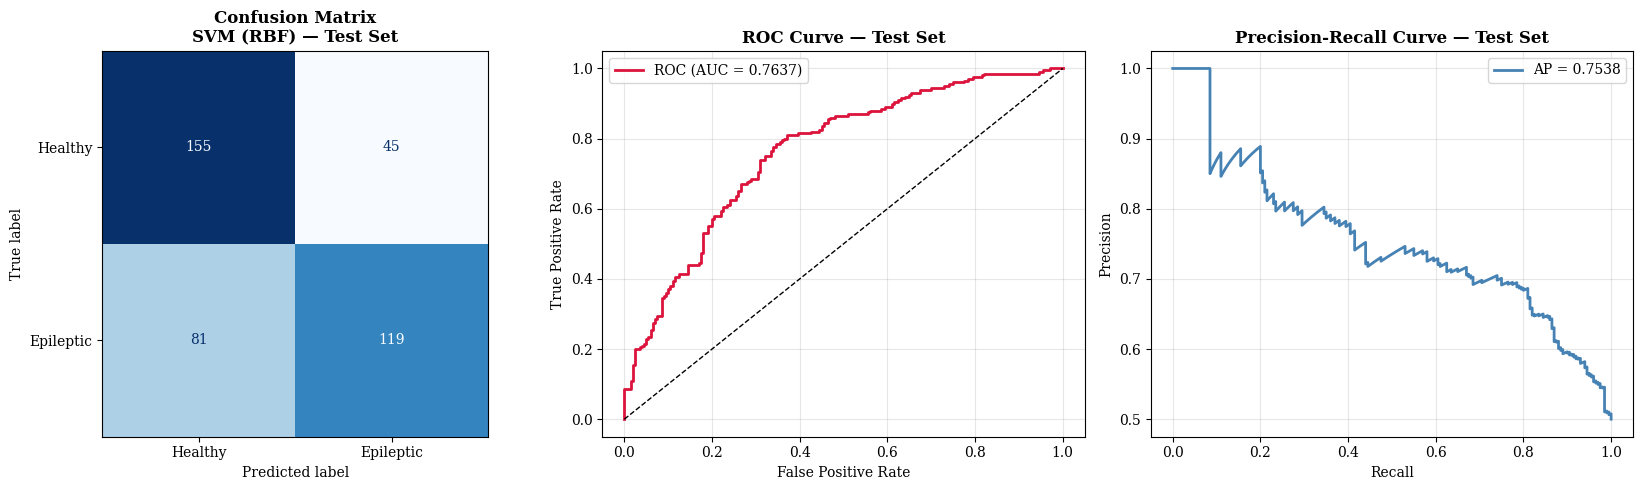

In [22]:
# ─── Cell 21: Visualise classification results ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "Epileptic"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix\n{best_name} — Test Set", fontweight="bold")

# 2. ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
axes[1].plot(fpr, tpr, lw=2, color="crimson",
             label=f"ROC (AUC = {roc_auc:.4f})")
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate");  axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — Test Set", fontweight="bold")
axes[1].legend();  axes[1].grid(alpha=0.3)

# 3. Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
axes[2].plot(rec, prec, lw=2, color="steelblue",
             label=f"AP = {avg_prec:.4f}")
axes[2].set_xlabel("Recall");  axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve — Test Set", fontweight="bold")
axes[2].legend();  axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("test_classification_results.png", dpi=150)
plt.show()


Per-subject accuracy on test set:
subject group  n_segments  n_correct  accuracy  mean_prob_E  std_prob_E
     E1     E          20         19      0.95     0.893151    0.167491
    E10     E          20          1      0.05     0.118101    0.233096
     E2     E          20          4      0.20     0.233718    0.264463
     E3     E          20         12      0.60     0.545804    0.298676
     E4     E          20         20      1.00     0.887327    0.139857
     E5     E          20         20      1.00     0.983652    0.031209
     E6     E          20          7      0.35     0.401000    0.348759
     E7     E          20         16      0.80     0.707577    0.314164
     E8     E          20          8      0.40     0.436338    0.251775
     E9     E          20         12      0.60     0.533784    0.357682
     H1     H          20         20      1.00     0.016038    0.046362
    H10     H          20         20      1.00     0.031422    0.052215
     H2     H          20    

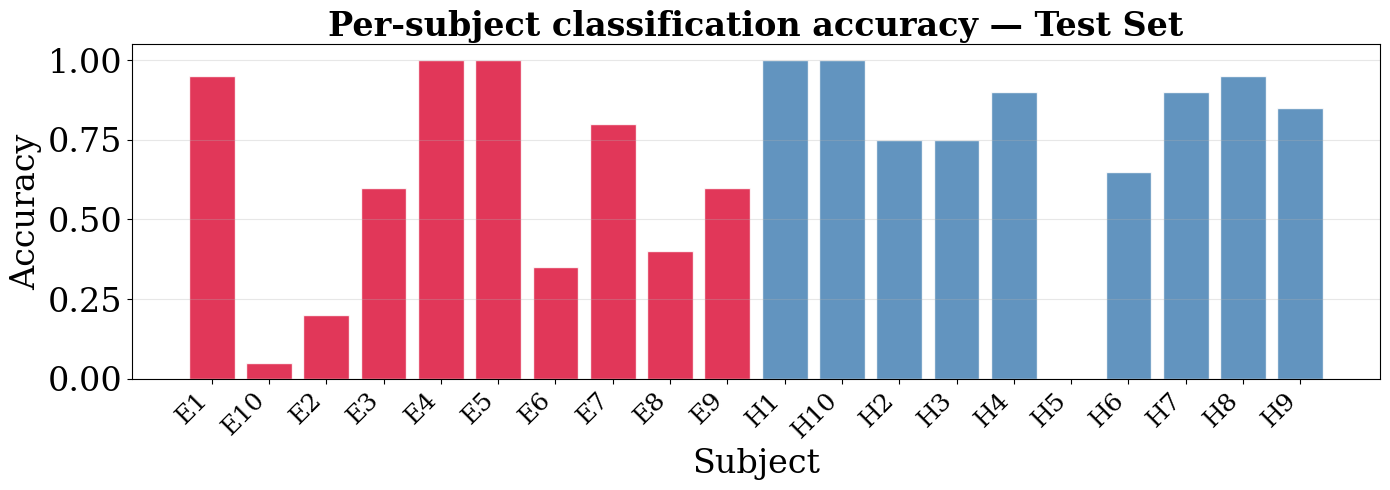

In [59]:
# ─── Cell 22: Per-subject accuracy and probability distribution ───────────────────
df_test["subject"] = df_test["filename"].str.extract(r'^([EH]\d+)_')
df_test["group"]   = df_test["filename"].str[0]

subj_stats = df_test.groupby(["subject","group","true_label"]).agg(
    n_segments    = ("correct", "count"),
    n_correct     = ("correct", "sum"),
    accuracy      = ("correct", "mean"),
    mean_prob_E   = ("prob_epileptic", "mean"),
    std_prob_E    = ("prob_epileptic", "std"),
).reset_index().sort_values(["group", "subject"])

print("\nPer-subject accuracy on test set:")
print(subj_stats[["subject","group","n_segments","n_correct",
                   "accuracy","mean_prob_E","std_prob_E"]].to_string(index=False))
subj_stats.to_csv("eeg_test_per_subject.csv", index=False)

# Bar chart: accuracy per subject, coloured by group
fig, ax = plt.subplots(figsize=(14, 5))
colors = subj_stats["group"].map({"E": "crimson", "H": "steelblue"})
bars = ax.bar(subj_stats["subject"], subj_stats["accuracy"],
              color=colors, edgecolor="white", alpha=0.85)


ax.set_ylim(0, 1.05)

ax.set_ylabel("Accuracy", fontsize=FONT_SIZE)
ax.set_xlabel("Subject", fontsize=FONT_SIZE)
ax.set_title("Per-subject classification accuracy — Test Set",
             fontweight="bold", fontsize=FONT_SIZE)

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=FONT_SIZE)
ax.set_xticklabels(subj_stats["subject"], rotation=45, ha="right")

from matplotlib.patches import Patch
legend_handles = [Patch(color="crimson", label="Epileptic (E)"),
                  Patch(color="steelblue", label="Healthy (H)")]

#ax.legend(handles=legend_handles, fontsize=16)

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("test_per_subject_accuracy.png", dpi=150)
plt.show()

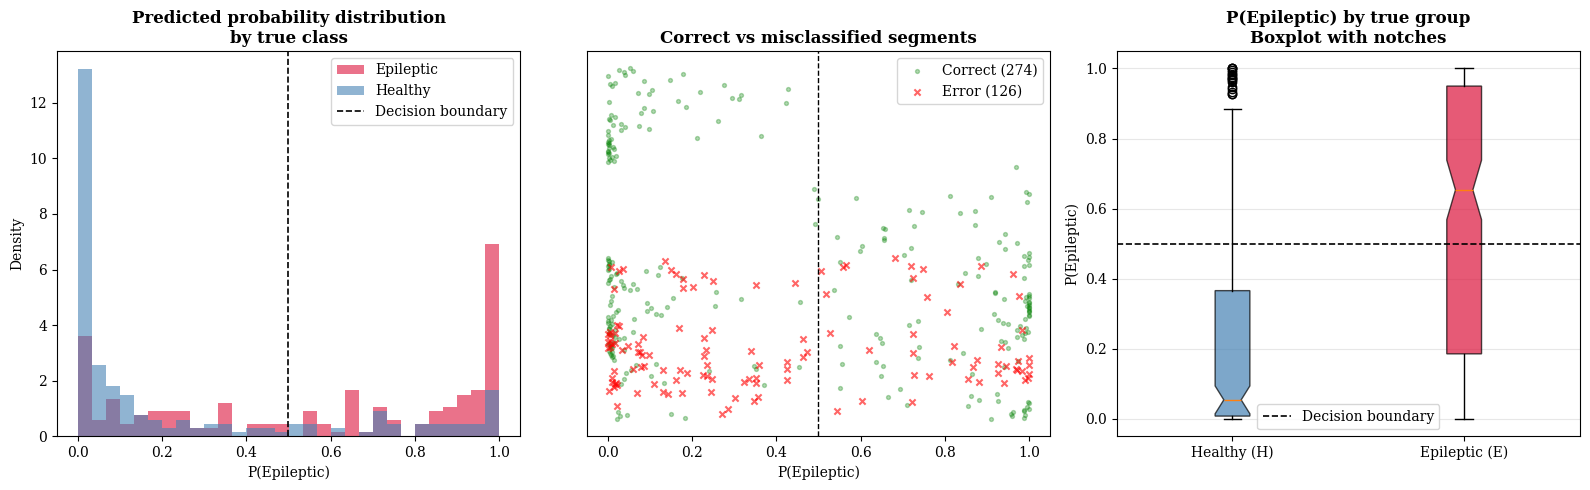


Total errors: 126/400 (31.5%)

Misclassified files:
  filename  true_label  predicted_label  prob_epileptic
 E1_17.txt           1                0        0.302337
  E2_1.txt           1                0        0.176757
  E2_2.txt           1                0        0.244475
  E2_3.txt           1                0        0.004324
  E2_6.txt           1                0        0.015669
  E2_7.txt           1                0        0.022090
  E2_8.txt           1                0        0.016699
  E2_9.txt           1                0        0.019894
 E2_10.txt           1                0        0.011307
 E2_11.txt           1                0        0.161064
 E2_12.txt           1                0        0.246736
 E2_13.txt           1                0        0.009088
 E2_15.txt           1                0        0.225673
 E2_17.txt           1                0        0.187877
 E2_18.txt           1                0        0.014230
 E2_19.txt           1                0        0.13

In [24]:
# ─── Cell 23: Probability distributions and error analysis ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Predicted probability histogram by true class
for lbl, name, color in [(1,"Epileptic","crimson"), (0,"Healthy","steelblue")]:
    vals = df_test[df_test["true_label"]==lbl]["prob_epileptic"]
    axes[0].hist(vals, bins=30, alpha=0.6, color=color, density=True, label=name)
axes[0].axvline(0.5, color="black", ls="--", lw=1.2, label="Decision boundary")
axes[0].set_xlabel("P(Epileptic)")
axes[0].set_ylabel("Density")
axes[0].set_title("Predicted probability distribution\nby true class", fontweight="bold")
axes[0].legend()

# 2. Errors vs confidence
errors = df_test[df_test["correct"]==0]
correct= df_test[df_test["correct"]==1]
axes[1].scatter(correct["prob_epileptic"], correct.index % len(correct),
                alpha=0.3, s=8, color="green", label=f"Correct ({len(correct)})")
axes[1].scatter(errors["prob_epileptic"], errors.index % len(errors),
                alpha=0.6, s=20, color="red", marker="x", label=f"Error ({len(errors)})")
axes[1].axvline(0.5, color="black", ls="--", lw=1)
axes[1].set_xlabel("P(Epileptic)")
axes[1].set_title("Correct vs misclassified segments", fontweight="bold")
axes[1].legend()
axes[1].set_yticks([])

# 3. Group-level summary boxplot
import matplotlib.patches as mpatches
data_E = df_test[df_test["true_label"]==1]["prob_epileptic"]
data_H = df_test[df_test["true_label"]==0]["prob_epileptic"]
bp = axes[2].boxplot([data_H, data_E], labels=["Healthy (H)", "Epileptic (E)"],
                     patch_artist=True, notch=True)
for patch, color in zip(bp["boxes"], ["steelblue","crimson"]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[2].axhline(0.5, color="black", ls="--", lw=1.2, label="Decision boundary")
axes[2].set_ylabel("P(Epileptic)")
axes[2].set_title("P(Epileptic) by true group\nBoxplot with notches", fontweight="bold")
axes[2].legend()
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("test_probability_analysis.png", dpi=150)
plt.show()

# Print error summary
print(f"\nTotal errors: {len(errors)}/{len(df_test)} ({len(errors)/len(df_test)*100:.1f}%)")
print("\nMisclassified files:")
print(errors[["filename","true_label","predicted_label","prob_epileptic"]].to_string(index=False))


In [25]:
# ─── Cell 24: Final summary statistics table ─────────────────────────────────────
from scipy import stats as sp_stats

summary_stats = {
    "Metric": [
        "Total test segments", "Epileptic (E)", "Healthy (H)",
        "Accuracy", "Balanced Accuracy",
        "Sensitivity (Recall E)", "Specificity (Recall H)",
        "Precision (E)", "F1-score (E)",
        "ROC-AUC", "Average Precision (PR-AUC)",
        "Matthews Corr. Coef.", "Cohen Kappa",
        "Mean P(E | true E)", "Mean P(E | true H)",
        "95% CI Accuracy (Wilson)",
    ],
    "Value": []
}

from sklearn.metrics import precision_score, recall_score, f1_score
n_total = len(y_test)
sens    = recall_score(y_test, y_pred_test, pos_label=1)
spec    = recall_score(y_test, y_pred_test, pos_label=0)
prec_e  = precision_score(y_test, y_pred_test, pos_label=1)
f1_e    = f1_score(y_test, y_pred_test, pos_label=1)

# Wilson score 95% CI for accuracy
z = 1.96
n, p = n_total, acc
lo = (p + z**2/(2*n) - z*((p*(1-p)/n + z**2/(4*n**2))**0.5)) / (1 + z**2/n)
hi = (p + z**2/(2*n) + z*((p*(1-p)/n + z**2/(4*n**2))**0.5)) / (1 + z**2/n)

values = [
    n_total, (y_test==1).sum(), (y_test==0).sum(),
    f"{acc:.4f} ({acc*100:.2f}%)", f"{bal_acc:.4f}",
    f"{sens:.4f}", f"{spec:.4f}",
    f"{prec_e:.4f}", f"{f1_e:.4f}",
    f"{roc_auc:.4f}", f"{avg_prec:.4f}",
    f"{mcc:.4f}", f"{kappa:.4f}",
    f"{df_test[df_test['true_label']==1]['prob_epileptic'].mean():.4f}",
    f"{df_test[df_test['true_label']==0]['prob_epileptic'].mean():.4f}",
    f"[{lo:.4f}, {hi:.4f}]",
]

summary_df = pd.DataFrame({"Metric": summary_stats["Metric"], "Value": values})
print("\n" + "="*50)
print("  FINAL TEST SET STATISTICS SUMMARY")
print("="*50)
print(summary_df.to_string(index=False))
summary_df.to_csv("eeg_final_summary.csv", index=False)
print("\nSummary saved → eeg_final_summary.csv")


  FINAL TEST SET STATISTICS SUMMARY
                    Metric            Value
       Total test segments              400
             Epileptic (E)              200
               Healthy (H)              200
                  Accuracy  0.6850 (68.50%)
         Balanced Accuracy           0.6850
    Sensitivity (Recall E)           0.5950
    Specificity (Recall H)           0.7750
             Precision (E)           0.7256
              F1-score (E)           0.6538
                   ROC-AUC           0.7637
Average Precision (PR-AUC)           0.7538
      Matthews Corr. Coef.           0.3761
               Cohen Kappa           0.3700
        Mean P(E | true E)           0.5740
        Mean P(E | true H)           0.2389
  95% CI Accuracy (Wilson) [0.6379, 0.7286]

Summary saved → eeg_final_summary.csv


Using trained model from variable: best_pipe
Downloaded/available test files: 400/400

Quarter-level dataframe shape: (1600, 8)
Sample-level dataframe shape : (400, 17)
4-SUBINTERVAL OR-RULE TEST PERFORMANCE — model: best_pipe
Segments evaluated          : 400
Epileptic (E)               : 200
Healthy (H)                 : 200
----------------------------------------------------------------------
Accuracy                    : 0.6975 (69.75%)
Balanced Accuracy           : 0.6975
Sensitivity / Recall (E)    : 0.8850
Specificity / Recall (H)    : 0.5100
Precision (E)               : 0.6436
F1-score (E)                : 0.7453
ROC-AUC                     : 0.7918
Average Precision (PR-AUC)  : 0.7647
Matthews Corr. Coef.        : 0.4261
Cohen Kappa                 : 0.3950

               precision    recall  f1-score   support

  Healthy (H)       0.82      0.51      0.63       200
Epileptic (E)       0.64      0.89      0.75       200

     accuracy                           0.70       40

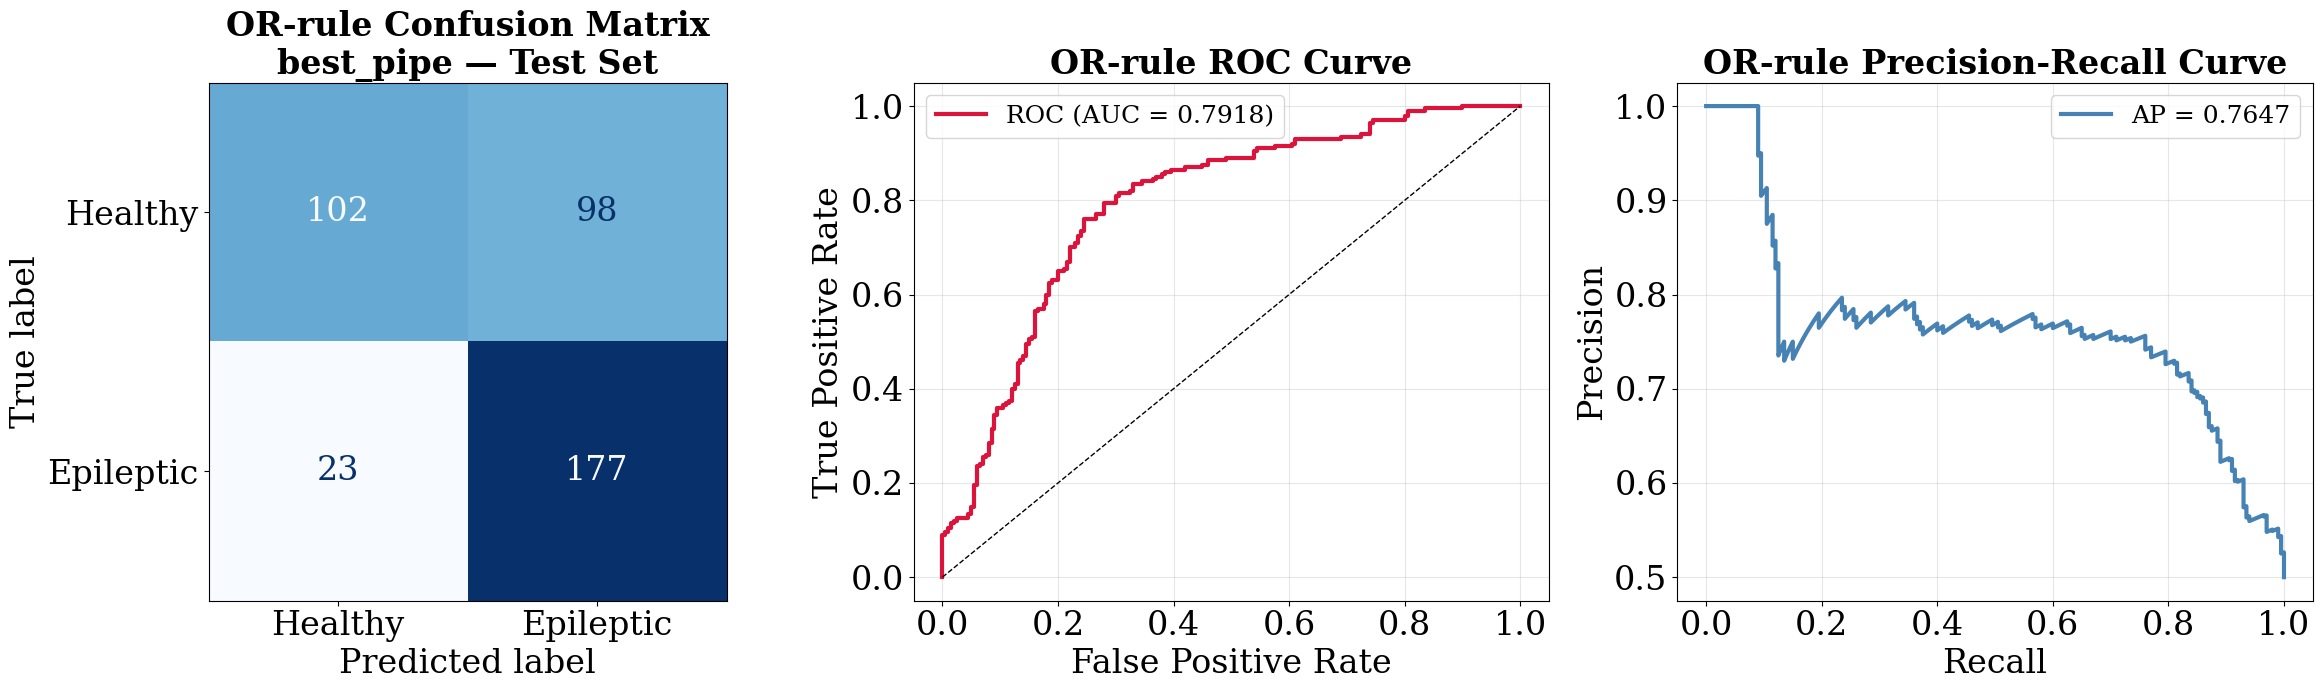

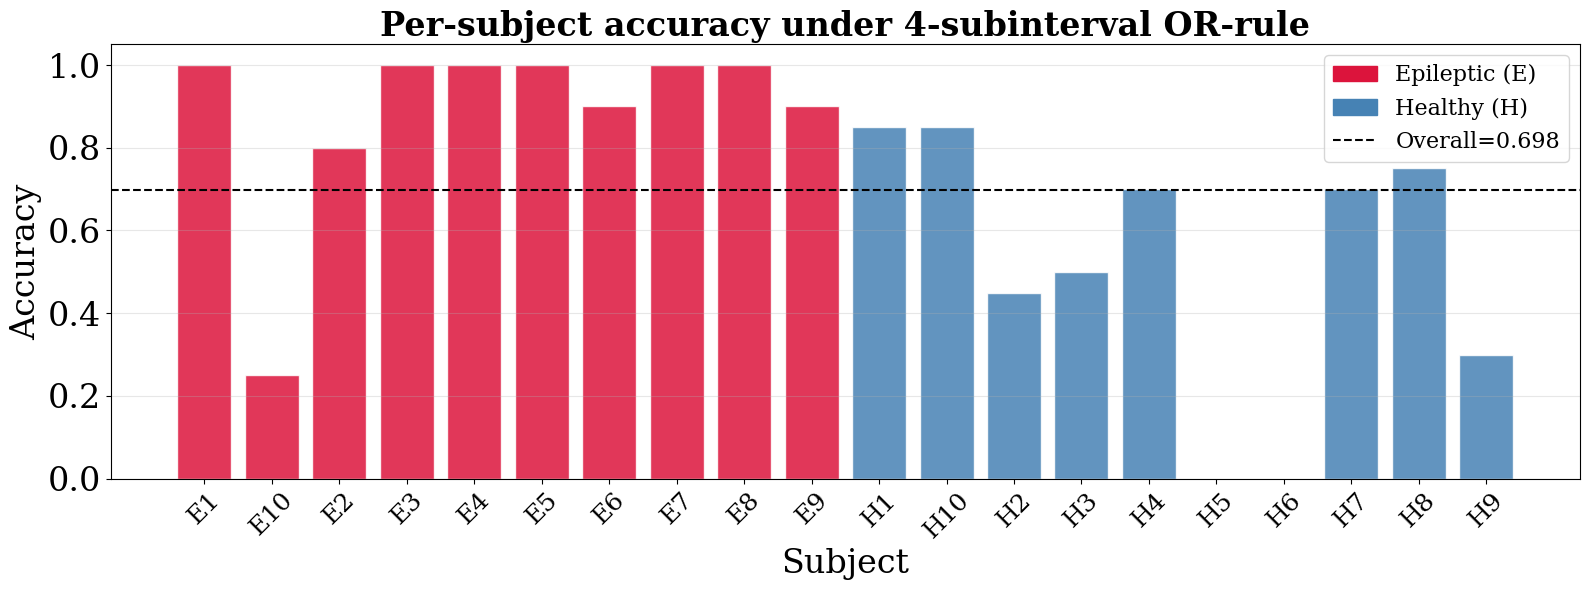

In [28]:
# ─── Additional cell: 4-subinterval OR-rule using existing best model + Zenodo test data ───
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
    precision_score, recall_score, f1_score
)
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

FONT_SIZE = 24

# ------------------------------------------------------------------
# 0) Resolve the trained classifier already created earlier
# ------------------------------------------------------------------
model_candidates = ["bestpipe", "best_pipe", "final_model", "best_accuracy_pipe"]
resolved_model_name = None
resolved_model = None

for nm in model_candidates:
    if nm in globals():
        resolved_model_name = nm
        resolved_model = globals()[nm]
        break

if resolved_model is None:
    raise NameError(
        "No trained classifier found in memory. Run the earlier training cell first. "
        "Expected one of: bestpipe, best_pipe, final_model, best_accuracy_pipe."
    )

print(f"Using trained model from variable: {resolved_model_name}")

# ------------------------------------------------------------------
# 1) Download / verify Zenodo test data
# ------------------------------------------------------------------
TEST_DIR = "eeg_test_data"
os.makedirs(TEST_DIR, exist_ok=True)

test_file_list = []
for group, true_label in [("E", 1), ("H", 0)]:
    for subject in range(1, 11):
        for seg in range(1, 21):
            fname = f"{group}{subject}_{seg}.txt"
            url = ZENODO_BASE + fname + "?download=1"
            path = os.path.join(TEST_DIR, fname)
            test_file_list.append((url, path, true_label, fname))

ok_test = 0
for url, path, true_label, fname in test_file_list:
    if download_file(url, path):
        ok_test += 1

print(f"Downloaded/available test files: {ok_test}/{len(test_file_list)}")

# ------------------------------------------------------------------
# 2) Quarter-wise classification for each test sample
#    Rule: Epileptic if at least one of 4 quarters is Epileptic
# ------------------------------------------------------------------
sample_rows = []
quarter_rows = []

for url, path, true_label, fname in test_file_list:
    if not os.path.exists(path):
        continue

    x = load_txt_series(path)
    if len(x) < 1000:
        continue

    parts = np.array_split(x, 4)

    q_preds = []
    q_probs = []

    for q_idx, part in enumerate(parts, start=1):
        try:
            feat_dict = extract_features(part, fs=FS)
            feat_df = pd.DataFrame([feat_dict])

            missing = [f for f in selected_feats if f not in feat_df.columns]
            for m in missing:
                feat_df[m] = 0.0

            X_part = feat_df[selected_feats].fillna(0.0).values

            pred = int(resolved_model.predict(X_part)[0])
            prob = float(resolved_model.predict_proba(X_part)[0, 1])

            q_preds.append(pred)
            q_probs.append(prob)

            quarter_rows.append({
                "filename": fname,
                "subject": fname.split("_")[0],
                "group": fname[0],
                "true_label": int(true_label),
                "quarter": q_idx,
                "quarter_length": len(part),
                "quarter_pred": pred,
                "quarter_prob_epileptic": prob
            })

        except Exception as e:
            print(f"Skipped {fname}, quarter {q_idx}: {e}")

    if len(q_preds) != 4:
        continue

    final_pred = int(max(q_preds))
    final_prob = float(max(q_probs))

    sample_rows.append({
        "filename": fname,
        "subject": fname.split("_")[0],
        "group": fname[0],
        "true_label": int(true_label),
        "predicted_label": final_pred,
        "prob_epileptic": final_prob,
        "n_epileptic_quarters": int(sum(q_preds)),
        "mean_quarter_prob_epileptic": float(np.mean(q_probs)),
        "std_quarter_prob_epileptic": float(np.std(q_probs)),
        "q1_pred": q_preds[0], "q2_pred": q_preds[1], "q3_pred": q_preds[2], "q4_pred": q_preds[3],
        "q1_prob": q_probs[0], "q2_prob": q_probs[1], "q3_prob": q_probs[2], "q4_prob": q_probs[3]
    })

df_quarters = pd.DataFrame(quarter_rows)
df_samples = pd.DataFrame(sample_rows)

if df_samples.empty:
    raise ValueError(
        "No valid test samples were processed. "
        "Most likely causes: the trained model variable is missing, selected_feats is missing, "
        "or extract_features failed on quarter-length segments."
    )

df_quarters.to_csv("quarter_level_predictions_or_rule.csv", index=False)
df_samples.to_csv("sample_level_predictions_or_rule.csv", index=False)

print(f"\nQuarter-level dataframe shape: {df_quarters.shape}")
print(f"Sample-level dataframe shape : {df_samples.shape}")

# ------------------------------------------------------------------
# 3) Metrics
# ------------------------------------------------------------------
y_true = df_samples["true_label"].astype(int).values
y_pred = df_samples["predicted_label"].astype(int).values
y_prob = df_samples["prob_epileptic"].astype(float).values

acc = accuracy_score(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)
avg_prec = average_precision_score(y_true, y_prob)
mcc = matthews_corrcoef(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
sens = recall_score(y_true, y_pred, pos_label=1)
spec = recall_score(y_true, y_pred, pos_label=0)
prec = precision_score(y_true, y_pred, pos_label=1)
f1 = f1_score(y_true, y_pred, pos_label=1)

print("=" * 70)
print(f"4-SUBINTERVAL OR-RULE TEST PERFORMANCE — model: {resolved_model_name}")
print("=" * 70)
print(f"Segments evaluated          : {len(y_true)}")
print(f"Epileptic (E)               : {(y_true == 1).sum()}")
print(f"Healthy (H)                 : {(y_true == 0).sum()}")
print("-" * 70)
print(f"Accuracy                    : {acc:.4f} ({acc*100:.2f}%)")
print(f"Balanced Accuracy           : {bal_acc:.4f}")
print(f"Sensitivity / Recall (E)    : {sens:.4f}")
print(f"Specificity / Recall (H)    : {spec:.4f}")
print(f"Precision (E)               : {prec:.4f}")
print(f"F1-score (E)                : {f1:.4f}")
print(f"ROC-AUC                     : {roc_auc:.4f}")
print(f"Average Precision (PR-AUC)  : {avg_prec:.4f}")
print(f"Matthews Corr. Coef.        : {mcc:.4f}")
print(f"Cohen Kappa                 : {kappa:.4f}")
print("=" * 70)
print()
print(classification_report(y_true, y_pred, target_names=["Healthy (H)", "Epileptic (E)"]))

# ------------------------------------------------------------------
# 4) Statistical characterization of output
# ------------------------------------------------------------------
stats_output = df_samples.groupby("true_label").agg(
    n_samples=("filename", "count"),
    mean_prob_epileptic=("prob_epileptic", "mean"),
    std_prob_epileptic=("prob_epileptic", "std"),
    median_prob_epileptic=("prob_epileptic", "median"),
    mean_epileptic_quarters=("n_epileptic_quarters", "mean"),
    std_epileptic_quarters=("n_epileptic_quarters", "std"),
    median_epileptic_quarters=("n_epileptic_quarters", "median")
).reset_index()

stats_output["group_name"] = stats_output["true_label"].map({0: "Healthy", 1: "Epileptic"})
print("\nStatistical characterization of output:")
print(stats_output.to_string(index=False))

# ------------------------------------------------------------------
# 5) Per-subject accuracy
# ------------------------------------------------------------------
df_samples["correct"] = (df_samples["predicted_label"] == df_samples["true_label"]).astype(int)

subj_stats = df_samples.groupby(["subject", "group", "true_label"]).agg(
    n_segments=("correct", "count"),
    n_correct=("correct", "sum"),
    accuracy=("correct", "mean"),
    mean_prob_epileptic=("prob_epileptic", "mean"),
    std_prob_epileptic=("prob_epileptic", "std"),
    mean_epileptic_quarters=("n_epileptic_quarters", "mean")
).reset_index().sort_values(["group", "subject"])

print("\nPer-subject accuracy:")
print(subj_stats.to_string(index=False))

# ------------------------------------------------------------------
# 6) Visualizations
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "Epileptic"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"OR-rule Confusion Matrix\n{resolved_model_name} — Test Set",
                  fontweight="bold", fontsize=FONT_SIZE)
axes[0].set_xlabel("Predicted label", fontsize=FONT_SIZE)
axes[0].set_ylabel("True label", fontsize=FONT_SIZE)
axes[0].tick_params(axis='both', labelsize=FONT_SIZE)
for txt in axes[0].texts:
    txt.set_fontsize(FONT_SIZE)

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, lw=3, color="crimson", label=f"ROC (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate", fontsize=FONT_SIZE)
axes[1].set_ylabel("True Positive Rate", fontsize=FONT_SIZE)
axes[1].set_title("OR-rule ROC Curve", fontweight="bold", fontsize=FONT_SIZE)
axes[1].legend(fontsize=18)
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='both', labelsize=FONT_SIZE)

prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
axes[2].plot(rec_curve, prec_curve, lw=3, color="steelblue",
             label=f"AP = {avg_prec:.4f}")
axes[2].set_xlabel("Recall", fontsize=FONT_SIZE)
axes[2].set_ylabel("Precision", fontsize=FONT_SIZE)
axes[2].set_title("OR-rule Precision-Recall Curve", fontweight="bold", fontsize=FONT_SIZE)
axes[2].legend(fontsize=18)
axes[2].grid(alpha=0.3)
axes[2].tick_params(axis='both', labelsize=FONT_SIZE)

plt.tight_layout()
plt.savefig("or_rule_curves.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(16, 6))
colors = subj_stats["group"].map({"E": "crimson", "H": "steelblue"})
ax.bar(subj_stats["subject"], subj_stats["accuracy"], color=colors, edgecolor="white", alpha=0.85)
ax.axhline(acc, ls="--", color="black", lw=1.5, label=f"Overall acc = {acc:.3f}")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy", fontsize=FONT_SIZE)
ax.set_xlabel("Subject", fontsize=FONT_SIZE)
ax.set_title("Per-subject accuracy under 4-subinterval OR-rule",
             fontweight="bold", fontsize=FONT_SIZE)
ax.tick_params(axis='x', labelrotation=45, labelsize=18)
ax.tick_params(axis='y', labelsize=FONT_SIZE)
legend_handles = [
    Patch(color="crimson", label="Epileptic (E)"),
    Patch(color="steelblue", label="Healthy (H)")
]
ax.legend(handles=legend_handles + [plt.Line2D([0],[0], color="black", ls="--",
                                               label=f"Overall={acc:.3f}")],
          fontsize=16)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("or_rule_per_subject_accuracy.png", dpi=150)
plt.show()

Using trained model from variable: best_pipe
Downloaded/available test files: 400/400

Quarter-level dataframe shape: (1600, 8)
Sample-level dataframe shape : (400, 17)
4-SUBINTERVAL 2-OF-4 RULE TEST PERFORMANCE — model: best_pipe
Segments evaluated          : 400
Epileptic (E)               : 200
Healthy (H)                 : 200
------------------------------------------------------------------------
Accuracy                    : 0.7175 (71.75%)
Balanced Accuracy           : 0.7175
Sensitivity / Recall (E)    : 0.8000
Specificity / Recall (H)    : 0.6350
Precision (E)               : 0.6867
F1-score (E)                : 0.7390
ROC-AUC                     : 0.7714
Average Precision (PR-AUC)  : 0.7481
Matthews Corr. Coef.        : 0.4410
Cohen Kappa                 : 0.4350

               precision    recall  f1-score   support

  Healthy (H)       0.76      0.64      0.69       200
Epileptic (E)       0.69      0.80      0.74       200

     accuracy                           0.72   

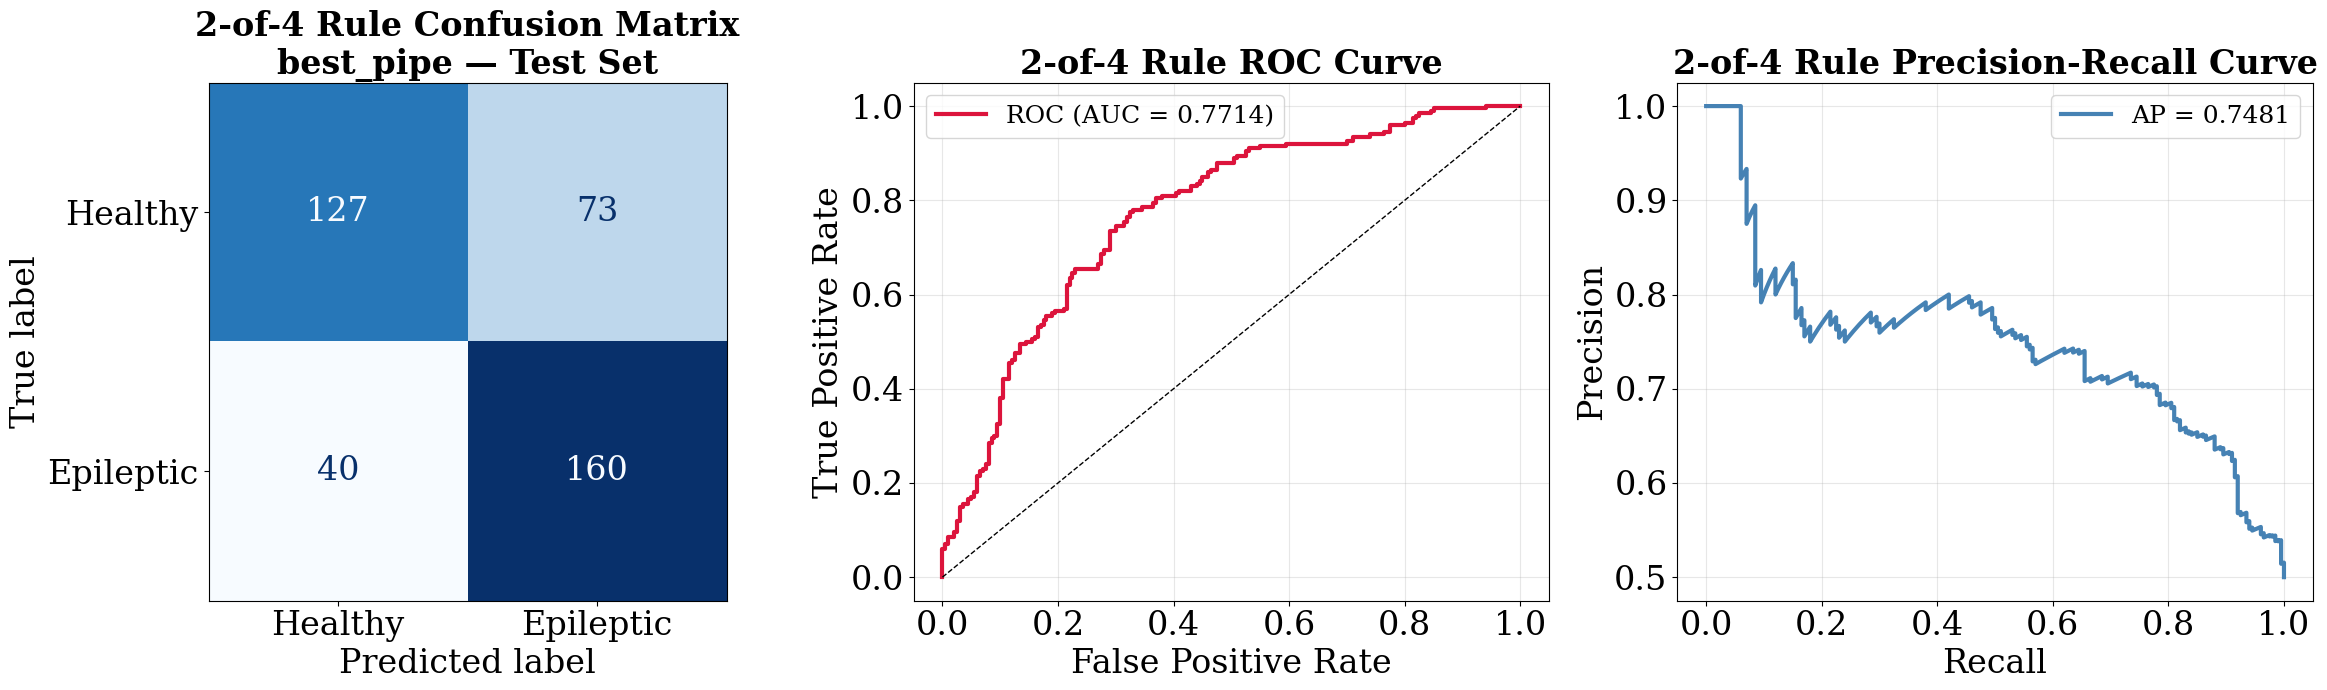

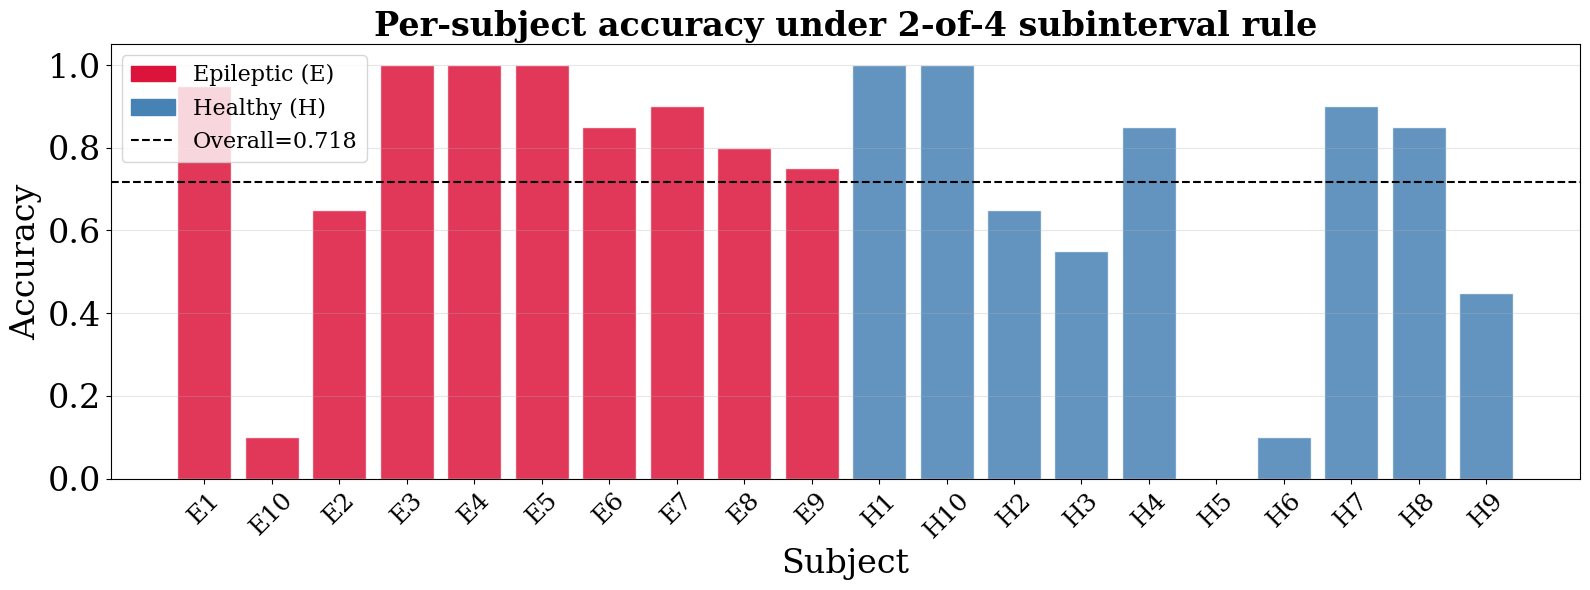

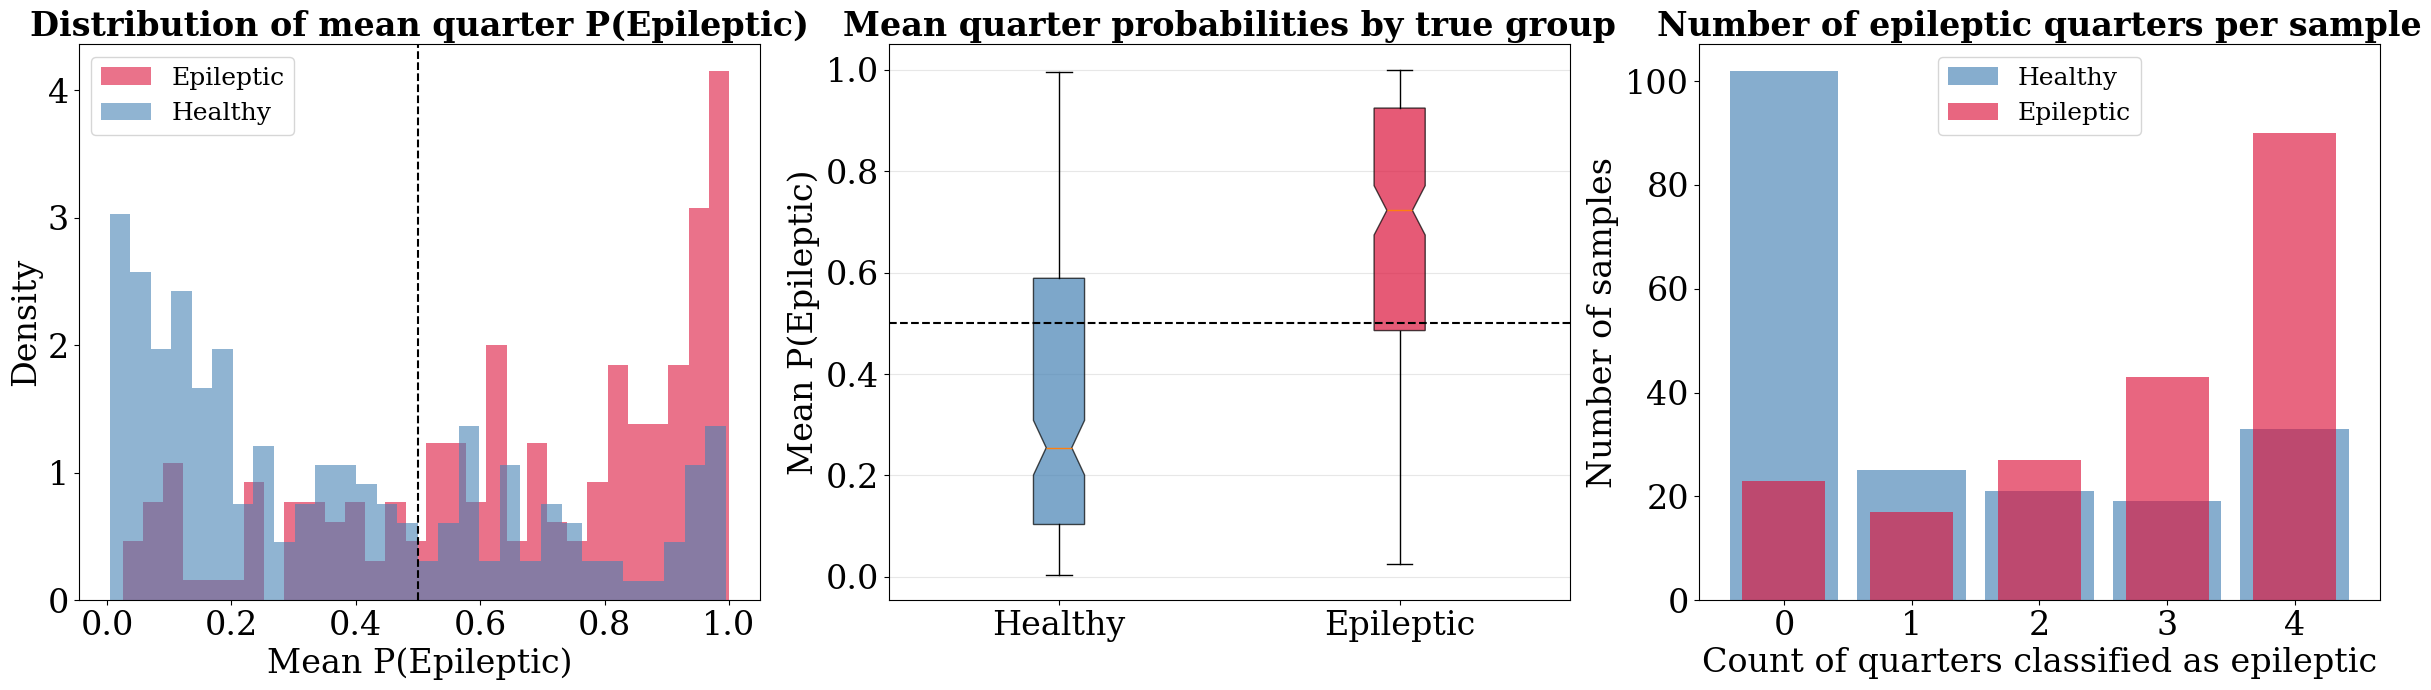

In [29]:
# ─── Additional cell: 4-subinterval classification using existing best model + Zenodo test data ───
# Rule: classify a sample as Epileptic if at least TWO of the FOUR subintervals are epileptic

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
    precision_score, recall_score, f1_score
)
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

FONT_SIZE = 24

# ------------------------------------------------------------------
# 0) Resolve the trained classifier already created earlier
# ------------------------------------------------------------------
model_candidates = ["bestpipe", "best_pipe", "final_model", "best_accuracy_pipe", "best_accuracy_model"]
resolved_model_name = None
resolved_model = None

for nm in model_candidates:
    if nm in globals():
        resolved_model_name = nm
        resolved_model = globals()[nm]
        break

if resolved_model is None:
    raise NameError(
        "No trained classifier found in memory. Run the earlier training cell first. "
        "Expected one of: bestpipe, best_pipe, final_model, best_accuracy_pipe, best_accuracy_model."
    )

print(f"Using trained model from variable: {resolved_model_name}")

# ------------------------------------------------------------------
# 1) Verify required notebook objects exist
# ------------------------------------------------------------------
required_names = ["ZENODO_BASE", "FS", "download_file", "load_txt_series", "extract_features", "selected_feats"]
missing_required = [nm for nm in required_names if nm not in globals()]
if missing_required:
    raise NameError(
        f"Missing required objects from earlier notebook cells: {missing_required}. "
        "Run the feature-extraction / model-training part of the notebook first."
    )

# ------------------------------------------------------------------
# 2) Download / verify Zenodo test data
# ------------------------------------------------------------------
TEST_DIR = "eeg_test_data"
os.makedirs(TEST_DIR, exist_ok=True)

test_file_list = []
for group, true_label in [("E", 1), ("H", 0)]:
    for subject in range(1, 11):
        for seg in range(1, 21):
            fname = f"{group}{subject}_{seg}.txt"
            url = ZENODO_BASE + fname + "?download=1"
            path = os.path.join(TEST_DIR, fname)
            test_file_list.append((url, path, true_label, fname))

ok_test = 0
for url, path, true_label, fname in test_file_list:
    if download_file(url, path):
        ok_test += 1

print(f"Downloaded/available test files: {ok_test}/{len(test_file_list)}")

# ------------------------------------------------------------------
# 3) Quarter-wise classification for each test sample
#    Final rule: Epileptic if at least 2 of 4 quarters are epileptic
# ------------------------------------------------------------------
sample_rows = []
quarter_rows = []

for url, path, true_label, fname in test_file_list:
    if not os.path.exists(path):
        continue

    x = load_txt_series(path)
    if len(x) < 1000:
        continue

    parts = np.array_split(x, 4)

    q_preds = []
    q_probs = []

    for q_idx, part in enumerate(parts, start=1):
        try:
            feat_dict = extract_features(part, fs=FS)
            feat_df = pd.DataFrame([feat_dict])

            missing = [f for f in selected_feats if f not in feat_df.columns]
            for m in missing:
                feat_df[m] = 0.0

            X_part = feat_df[selected_feats].fillna(0.0).values

            pred = int(resolved_model.predict(X_part)[0])
            prob = float(resolved_model.predict_proba(X_part)[0, 1])

            q_preds.append(pred)
            q_probs.append(prob)

            quarter_rows.append({
                "filename": fname,
                "subject": fname.split("_")[0],
                "group": fname[0],
                "true_label": int(true_label),
                "quarter": q_idx,
                "quarter_length": len(part),
                "quarter_pred": pred,
                "quarter_prob_epileptic": prob
            })

        except Exception as e:
            print(f"Skipped {fname}, quarter {q_idx}: {e}")

    if len(q_preds) != 4:
        continue

    n_ep_quarters = int(sum(q_preds))
    final_pred = int(n_ep_quarters >= 2)
    final_prob = float(np.mean(q_probs))

    sample_rows.append({
        "filename": fname,
        "subject": fname.split("_")[0],
        "group": fname[0],
        "true_label": int(true_label),
        "predicted_label": final_pred,
        "prob_epileptic": final_prob,
        "n_epileptic_quarters": n_ep_quarters,
        "mean_quarter_prob_epileptic": float(np.mean(q_probs)),
        "std_quarter_prob_epileptic": float(np.std(q_probs)),
        "q1_pred": q_preds[0], "q2_pred": q_preds[1], "q3_pred": q_preds[2], "q4_pred": q_preds[3],
        "q1_prob": q_probs[0], "q2_prob": q_probs[1], "q3_prob": q_probs[2], "q4_prob": q_probs[3]
    })

df_quarters = pd.DataFrame(quarter_rows)
df_samples = pd.DataFrame(sample_rows)

if df_samples.empty:
    raise ValueError(
        "No valid test samples were processed. "
        "Most likely causes: the trained model variable is missing, selected_feats is missing, "
        "or extract_features failed on quarter-length segments."
    )

df_quarters.to_csv("quarter_level_predictions_2of4_rule.csv", index=False)
df_samples.to_csv("sample_level_predictions_2of4_rule.csv", index=False)

print(f"\nQuarter-level dataframe shape: {df_quarters.shape}")
print(f"Sample-level dataframe shape : {df_samples.shape}")

# ------------------------------------------------------------------
# 4) Metrics
# ------------------------------------------------------------------
y_true = df_samples["true_label"].astype(int).values
y_pred = df_samples["predicted_label"].astype(int).values
y_prob = df_samples["prob_epileptic"].astype(float).values

acc = accuracy_score(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)
avg_prec = average_precision_score(y_true, y_prob)
mcc = matthews_corrcoef(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
sens = recall_score(y_true, y_pred, pos_label=1)
spec = recall_score(y_true, y_pred, pos_label=0)
prec = precision_score(y_true, y_pred, pos_label=1)
f1 = f1_score(y_true, y_pred, pos_label=1)

print("=" * 72)
print(f"4-SUBINTERVAL 2-OF-4 RULE TEST PERFORMANCE — model: {resolved_model_name}")
print("=" * 72)
print(f"Segments evaluated          : {len(y_true)}")
print(f"Epileptic (E)               : {(y_true == 1).sum()}")
print(f"Healthy (H)                 : {(y_true == 0).sum()}")
print("-" * 72)
print(f"Accuracy                    : {acc:.4f} ({acc*100:.2f}%)")
print(f"Balanced Accuracy           : {bal_acc:.4f}")
print(f"Sensitivity / Recall (E)    : {sens:.4f}")
print(f"Specificity / Recall (H)    : {spec:.4f}")
print(f"Precision (E)               : {prec:.4f}")
print(f"F1-score (E)                : {f1:.4f}")
print(f"ROC-AUC                     : {roc_auc:.4f}")
print(f"Average Precision (PR-AUC)  : {avg_prec:.4f}")
print(f"Matthews Corr. Coef.        : {mcc:.4f}")
print(f"Cohen Kappa                 : {kappa:.4f}")
print("=" * 72)
print()
print(classification_report(y_true, y_pred, target_names=["Healthy (H)", "Epileptic (E)"]))

# ------------------------------------------------------------------
# 5) Statistical characterization of output
# ------------------------------------------------------------------
stats_output = df_samples.groupby("true_label").agg(
    n_samples=("filename", "count"),
    mean_prob_epileptic=("prob_epileptic", "mean"),
    std_prob_epileptic=("prob_epileptic", "std"),
    median_prob_epileptic=("prob_epileptic", "median"),
    mean_epileptic_quarters=("n_epileptic_quarters", "mean"),
    std_epileptic_quarters=("n_epileptic_quarters", "std"),
    median_epileptic_quarters=("n_epileptic_quarters", "median")
).reset_index()

stats_output["group_name"] = stats_output["true_label"].map({0: "Healthy", 1: "Epileptic"})
print("\nStatistical characterization of output:")
print(stats_output.to_string(index=False))

# ------------------------------------------------------------------
# 6) Per-subject accuracy
# ------------------------------------------------------------------
df_samples["correct"] = (df_samples["predicted_label"] == df_samples["true_label"]).astype(int)

subj_stats = df_samples.groupby(["subject", "group", "true_label"]).agg(
    n_segments=("correct", "count"),
    n_correct=("correct", "sum"),
    accuracy=("correct", "mean"),
    mean_prob_epileptic=("prob_epileptic", "mean"),
    std_prob_epileptic=("prob_epileptic", "std"),
    mean_epileptic_quarters=("n_epileptic_quarters", "mean")
).reset_index().sort_values(["group", "subject"])

print("\nPer-subject accuracy:")
print(subj_stats.to_string(index=False))

# ------------------------------------------------------------------
# 7) Visualizations
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "Epileptic"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"2-of-4 Rule Confusion Matrix\n{resolved_model_name} — Test Set",
                  fontweight="bold", fontsize=FONT_SIZE)
axes[0].set_xlabel("Predicted label", fontsize=FONT_SIZE)
axes[0].set_ylabel("True label", fontsize=FONT_SIZE)
axes[0].tick_params(axis='both', labelsize=FONT_SIZE)
for txt in axes[0].texts:
    txt.set_fontsize(FONT_SIZE)

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, lw=3, color="crimson", label=f"ROC (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate", fontsize=FONT_SIZE)
axes[1].set_ylabel("True Positive Rate", fontsize=FONT_SIZE)
axes[1].set_title("2-of-4 Rule ROC Curve", fontweight="bold", fontsize=FONT_SIZE)
axes[1].legend(fontsize=18)
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='both', labelsize=FONT_SIZE)

prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
axes[2].plot(rec_curve, prec_curve, lw=3, color="steelblue",
             label=f"AP = {avg_prec:.4f}")
axes[2].set_xlabel("Recall", fontsize=FONT_SIZE)
axes[2].set_ylabel("Precision", fontsize=FONT_SIZE)
axes[2].set_title("2-of-4 Rule Precision-Recall Curve", fontweight="bold", fontsize=FONT_SIZE)
axes[2].legend(fontsize=18)
axes[2].grid(alpha=0.3)
axes[2].tick_params(axis='both', labelsize=FONT_SIZE)

plt.tight_layout()
plt.savefig("rule_2of4_curves.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(16, 6))
colors = subj_stats["group"].map({"E": "crimson", "H": "steelblue"})
ax.bar(subj_stats["subject"], subj_stats["accuracy"], color=colors, edgecolor="white", alpha=0.85)
ax.axhline(acc, ls="--", color="black", lw=1.5, label=f"Overall acc = {acc:.3f}")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy", fontsize=FONT_SIZE)
ax.set_xlabel("Subject", fontsize=FONT_SIZE)
ax.set_title("Per-subject accuracy under 2-of-4 subinterval rule",
             fontweight="bold", fontsize=FONT_SIZE)
ax.tick_params(axis='x', labelrotation=45, labelsize=18)
ax.tick_params(axis='y', labelsize=FONT_SIZE)
legend_handles = [
    Patch(color="crimson", label="Epileptic (E)"),
    Patch(color="steelblue", label="Healthy (H)")
]
ax.legend(
    handles=legend_handles + [
        plt.Line2D([0], [0], color="black", ls="--", label=f"Overall={acc:.3f}")
    ],
    fontsize=16
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("rule_2of4_per_subject_accuracy.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for lbl, name, color in [(1, "Epileptic", "crimson"), (0, "Healthy", "steelblue")]:
    vals = df_samples.loc[df_samples["true_label"] == lbl, "prob_epileptic"]
    axes[0].hist(vals, bins=30, alpha=0.60, density=True, color=color, label=name)

axes[0].axvline(0.5, color="black", ls="--", lw=1.5)
axes[0].set_title("Distribution of mean quarter P(Epileptic)",
                  fontweight="bold", fontsize=FONT_SIZE)
axes[0].set_xlabel("Mean P(Epileptic)", fontsize=FONT_SIZE)
axes[0].set_ylabel("Density", fontsize=FONT_SIZE)
axes[0].legend(fontsize=18)
axes[0].tick_params(axis='both', labelsize=FONT_SIZE)

data_H = df_samples.loc[df_samples["true_label"] == 0, "prob_epileptic"]
data_E = df_samples.loc[df_samples["true_label"] == 1, "prob_epileptic"]
bp = axes[1].boxplot([data_H, data_E], tick_labels=["Healthy", "Epileptic"],
                     patch_artist=True, notch=True)
for patch, color in zip(bp["boxes"], ["steelblue", "crimson"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(0.5, color="black", ls="--", lw=1.5)
axes[1].set_title("Mean quarter probabilities by true group",
                  fontweight="bold", fontsize=FONT_SIZE)
axes[1].set_ylabel("Mean P(Epileptic)", fontsize=FONT_SIZE)
axes[1].tick_params(axis='both', labelsize=FONT_SIZE)
axes[1].grid(axis="y", alpha=0.3)

counts_H = df_samples.loc[df_samples["true_label"] == 0, "n_epileptic_quarters"]
counts_E = df_samples.loc[df_samples["true_label"] == 1, "n_epileptic_quarters"]
bins = np.arange(-0.5, 5.5, 1)
axes[2].hist(counts_H, bins=bins, alpha=0.65, color="steelblue", label="Healthy", rwidth=0.85)
axes[2].hist(counts_E, bins=bins, alpha=0.65, color="crimson", label="Epileptic", rwidth=0.65)
axes[2].set_xticks([0, 1, 2, 3, 4])
axes[2].set_title("Number of epileptic quarters per sample",
                  fontweight="bold", fontsize=FONT_SIZE)
axes[2].set_xlabel("Count of quarters classified as epileptic", fontsize=FONT_SIZE)
axes[2].set_ylabel("Number of samples", fontsize=FONT_SIZE)
axes[2].legend(fontsize=18)
axes[2].tick_params(axis='both', labelsize=FONT_SIZE)

plt.tight_layout()
plt.savefig("rule_2of4_statistics.png", dpi=150)
plt.show()

Using trained model from variable: best_pipe
Downloaded/available test files: 400/400

Quarter-level dataframe shape: (1600, 8)
Sample-level dataframe shape : (400, 17)
SEGMENT-LEVEL: 4-SUBINTERVAL 2-OF-4 RULE TEST PERFORMANCE — model: best_pipe
Segments evaluated          : 400
Epileptic (E)               : 200
Healthy (H)                 : 200
------------------------------------------------------------------------
Accuracy                    : 0.7175 (71.75%)
Balanced Accuracy           : 0.7175
Sensitivity / Recall (E)    : 0.8000
Specificity / Recall (H)    : 0.6350
Precision (E)               : 0.6867
F1-score (E)                : 0.7390
ROC-AUC                     : 0.7714
Average Precision (PR-AUC)  : 0.7481
Matthews Corr. Coef.        : 0.4410
Cohen Kappa                 : 0.4350

               precision    recall  f1-score   support

  Healthy (H)       0.76      0.64      0.69       200
Epileptic (E)       0.69      0.80      0.74       200

     accuracy                   

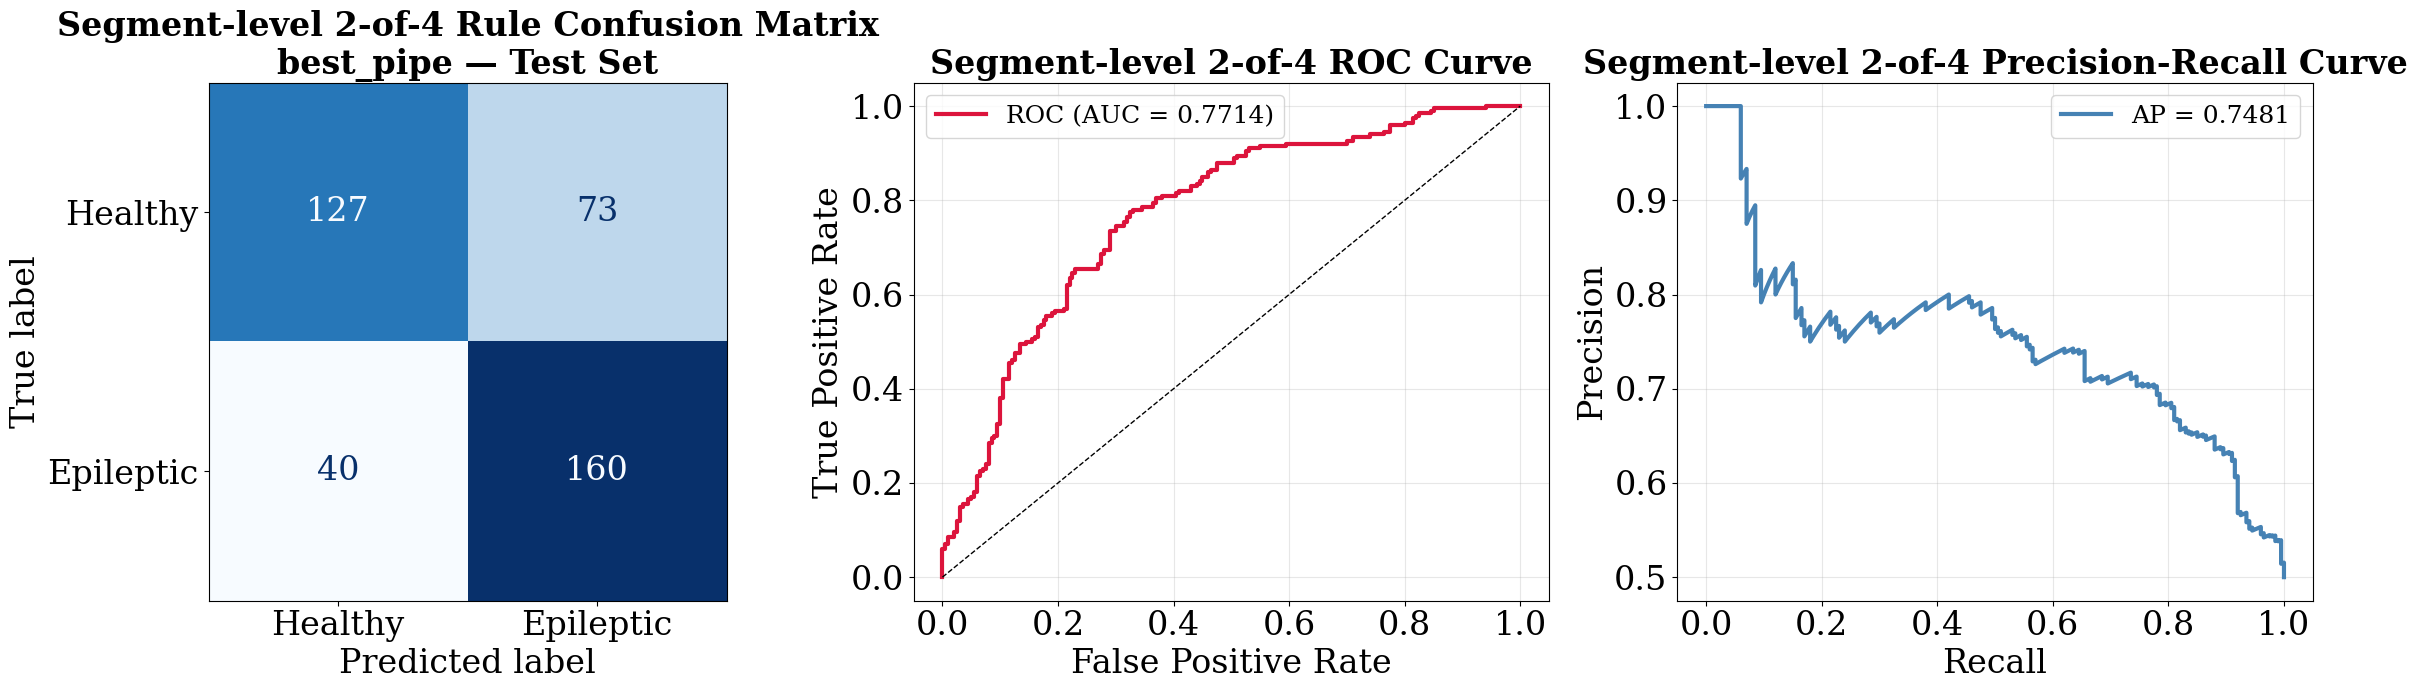

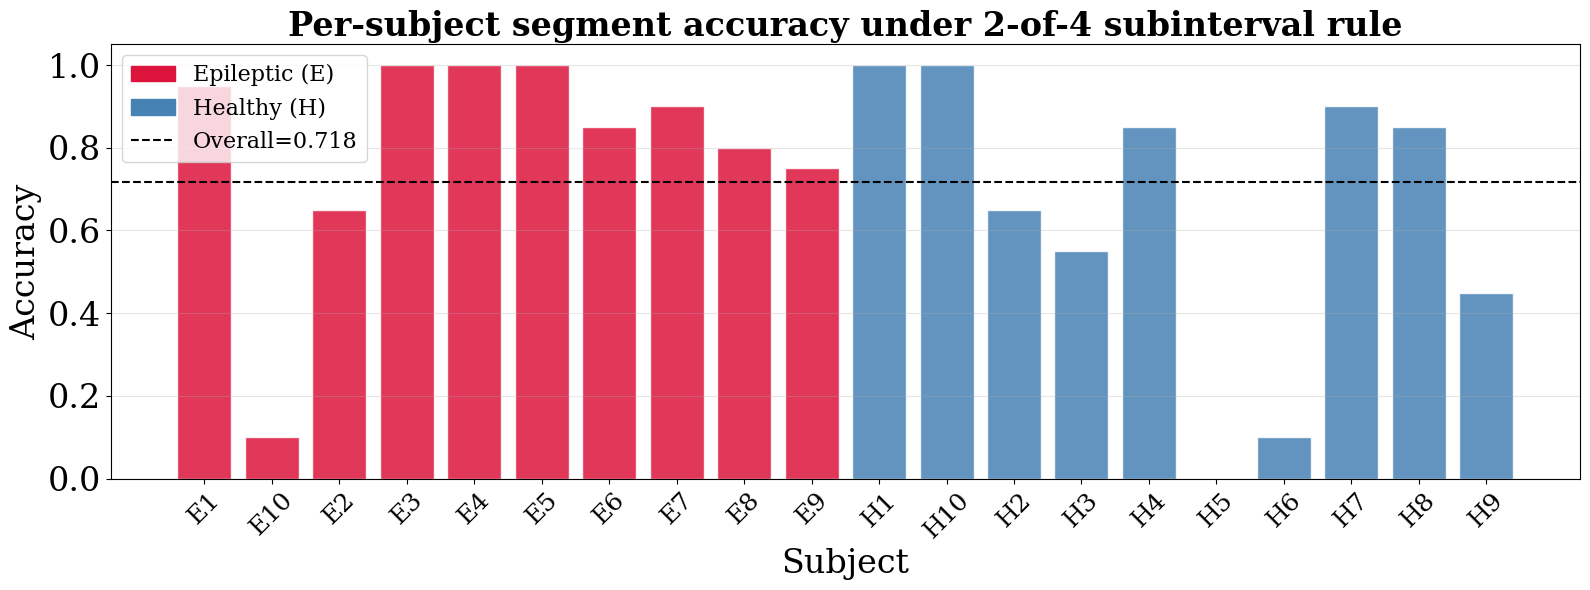

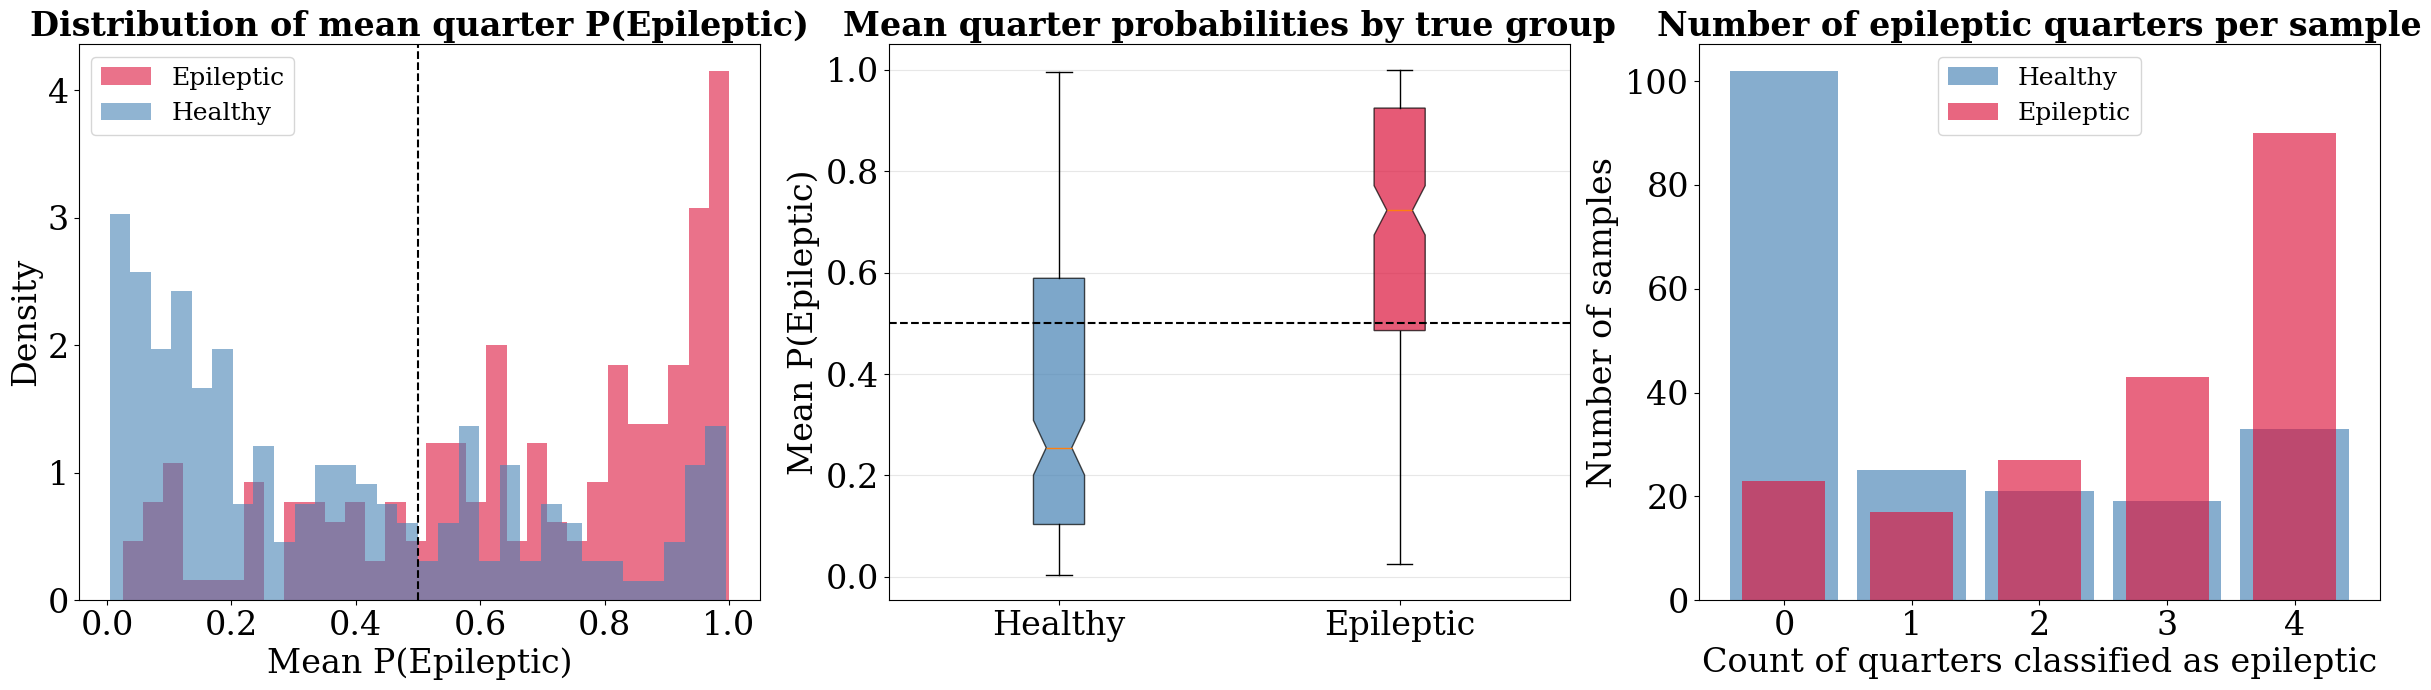

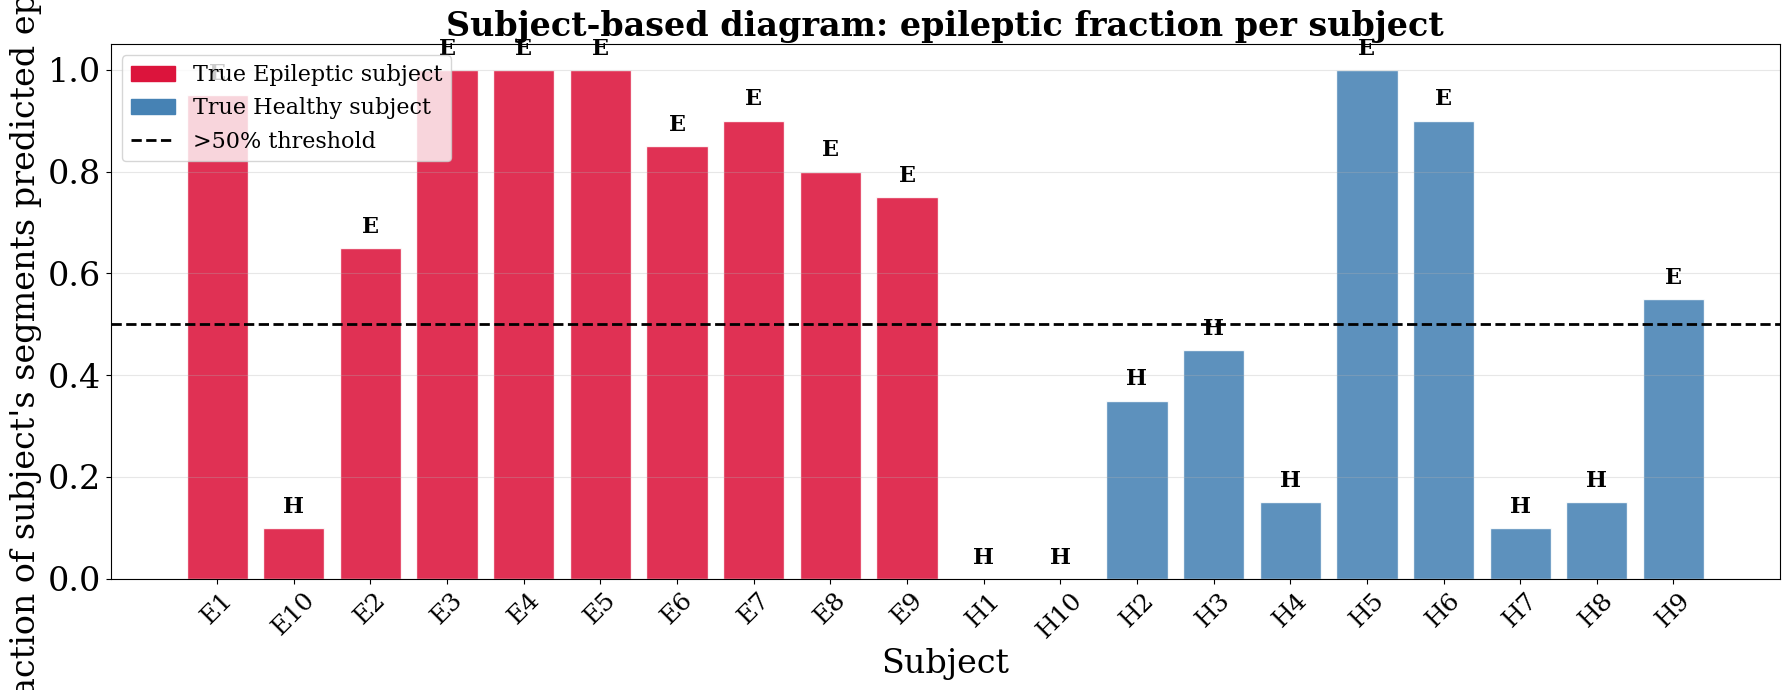

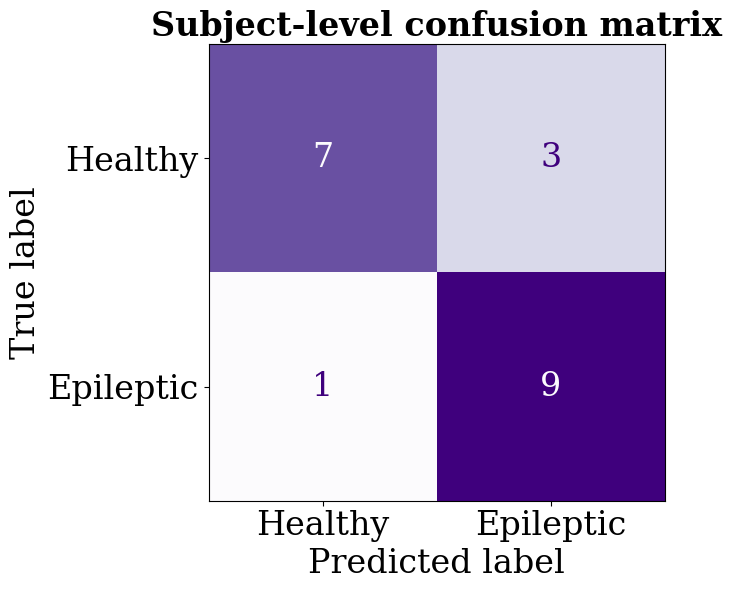

In [45]:
# ─── Additional cell: 4-subinterval classification using TWO-OF-FOUR rule + subject-level majority vote ───
# Segment rule: classify a sample as Epileptic if at least TWO of the FOUR subintervals are epileptic
# Subject rule: classify a subject as Epileptic if > 50% of that subject's segments are classified as epileptic

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
    precision_score, recall_score, f1_score
)
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

FONT_SIZE = 24

# ------------------------------------------------------------------
# 0) Resolve the trained classifier already created earlier
# ------------------------------------------------------------------
model_candidates = ["bestpipe", "best_pipe", "final_model", "best_accuracy_pipe", "best_accuracy_model"]
resolved_model_name = None
resolved_model = None

for nm in model_candidates:
    if nm in globals():
        resolved_model_name = nm
        resolved_model = globals()[nm]
        break

if resolved_model is None:
    raise NameError(
        "No trained classifier found in memory. Run the earlier training cell first. "
        "Expected one of: bestpipe, best_pipe, final_model, best_accuracy_pipe, best_accuracy_model."
    )

print(f"Using trained model from variable: {resolved_model_name}")

# ------------------------------------------------------------------
# 1) Verify required notebook objects exist
# ------------------------------------------------------------------
required_names = ["ZENODO_BASE", "FS", "download_file", "load_txt_series", "extract_features", "selected_feats"]
missing_required = [nm for nm in required_names if nm not in globals()]
if missing_required:
    raise NameError(
        f"Missing required objects from earlier notebook cells: {missing_required}. "
        "Run the feature-extraction / model-training part of the notebook first."
    )

# ------------------------------------------------------------------
# 2) Download / verify Zenodo test data
# ------------------------------------------------------------------
TEST_DIR = "eeg_test_data"
os.makedirs(TEST_DIR, exist_ok=True)

test_file_list = []
for group, true_label in [("E", 1), ("H", 0)]:
    for subject in range(1, 11):
        for seg in range(1, 21):
            fname = f"{group}{subject}_{seg}.txt"
            url = ZENODO_BASE + fname + "?download=1"
            path = os.path.join(TEST_DIR, fname)
            test_file_list.append((url, path, true_label, fname))

ok_test = 0
for url, path, true_label, fname in test_file_list:
    if download_file(url, path):
        ok_test += 1

print(f"Downloaded/available test files: {ok_test}/{len(test_file_list)}")

# ------------------------------------------------------------------
# 3) Quarter-wise classification for each test sample
#    Final segment rule: Epileptic if at least 2 of 4 quarters are epileptic
# ------------------------------------------------------------------
sample_rows = []
quarter_rows = []

for url, path, true_label, fname in test_file_list:
    if not os.path.exists(path):
        continue

    x = load_txt_series(path)
    if len(x) < 1000:
        continue

    parts = np.array_split(x, 4)

    q_preds = []
    q_probs = []

    for q_idx, part in enumerate(parts, start=1):
        try:
            feat_dict = extract_features(part, fs=FS)
            feat_df = pd.DataFrame([feat_dict])

            missing = [f for f in selected_feats if f not in feat_df.columns]
            for m in missing:
                feat_df[m] = 0.0

            X_part = feat_df[selected_feats].fillna(0.0).values

            pred = int(resolved_model.predict(X_part)[0])
            prob = float(resolved_model.predict_proba(X_part)[0, 1])

            q_preds.append(pred)
            q_probs.append(prob)

            quarter_rows.append({
                "filename": fname,
                "subject": fname.split("_")[0],
                "group": fname[0],
                "true_label": int(true_label),
                "quarter": q_idx,
                "quarter_length": len(part),
                "quarter_pred": pred,
                "quarter_prob_epileptic": prob
            })

        except Exception as e:
            print(f"Skipped {fname}, quarter {q_idx}: {e}")

    if len(q_preds) != 4:
        continue

    n_ep_quarters = int(sum(q_preds))
    final_pred = int(n_ep_quarters >= 2)
    final_prob = float(np.mean(q_probs))

    sample_rows.append({
        "filename": fname,
        "subject": fname.split("_")[0],
        "group": fname[0],
        "true_label": int(true_label),
        "predicted_label": final_pred,
        "prob_epileptic": final_prob,
        "n_epileptic_quarters": n_ep_quarters,
        "mean_quarter_prob_epileptic": float(np.mean(q_probs)),
        "std_quarter_prob_epileptic": float(np.std(q_probs)),
        "q1_pred": q_preds[0], "q2_pred": q_preds[1], "q3_pred": q_preds[2], "q4_pred": q_preds[3],
        "q1_prob": q_probs[0], "q2_prob": q_probs[1], "q3_prob": q_probs[2], "q4_prob": q_probs[3]
    })

df_quarters = pd.DataFrame(quarter_rows)
df_samples = pd.DataFrame(sample_rows)

if df_samples.empty:
    raise ValueError(
        "No valid test samples were processed. "
        "Most likely causes: the trained model variable is missing, selected_feats is missing, "
        "or extract_features failed on quarter-length segments."
    )

df_quarters.to_csv("quarter_level_predictions_2of4_rule.csv", index=False)
df_samples.to_csv("sample_level_predictions_2of4_rule.csv", index=False)

print(f"\nQuarter-level dataframe shape: {df_quarters.shape}")
print(f"Sample-level dataframe shape : {df_samples.shape}")

# ------------------------------------------------------------------
# 4) Segment-level metrics
# ------------------------------------------------------------------
y_true = df_samples["true_label"].astype(int).values
y_pred = df_samples["predicted_label"].astype(int).values
y_prob = df_samples["prob_epileptic"].astype(float).values

acc = accuracy_score(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)
avg_prec = average_precision_score(y_true, y_prob)
mcc = matthews_corrcoef(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
sens = recall_score(y_true, y_pred, pos_label=1)
spec = recall_score(y_true, y_pred, pos_label=0)
prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

print("=" * 72)
print(f"SEGMENT-LEVEL: 4-SUBINTERVAL 2-OF-4 RULE TEST PERFORMANCE — model: {resolved_model_name}")
print("=" * 72)
print(f"Segments evaluated          : {len(y_true)}")
print(f"Epileptic (E)               : {(y_true == 1).sum()}")
print(f"Healthy (H)                 : {(y_true == 0).sum()}")
print("-" * 72)
print(f"Accuracy                    : {acc:.4f} ({acc*100:.2f}%)")
print(f"Balanced Accuracy           : {bal_acc:.4f}")
print(f"Sensitivity / Recall (E)    : {sens:.4f}")
print(f"Specificity / Recall (H)    : {spec:.4f}")
print(f"Precision (E)               : {prec:.4f}")
print(f"F1-score (E)                : {f1:.4f}")
print(f"ROC-AUC                     : {roc_auc:.4f}")
print(f"Average Precision (PR-AUC)  : {avg_prec:.4f}")
print(f"Matthews Corr. Coef.        : {mcc:.4f}")
print(f"Cohen Kappa                 : {kappa:.4f}")
print("=" * 72)
print()
print(classification_report(y_true, y_pred, target_names=["Healthy (H)", "Epileptic (E)"], zero_division=0))

# ------------------------------------------------------------------
# 5) Subject-level classification:
#    if > 50% of a subject's segments are predicted epileptic => subject epileptic
# ------------------------------------------------------------------
subject_df = (
    df_samples
    .groupby(["subject", "group", "true_label"], as_index=False)
    .agg(
        n_segments=("filename", "count"),
        n_predicted_epileptic_segments=("predicted_label", "sum"),
        mean_segment_prob_epileptic=("prob_epileptic", "mean"),
        std_segment_prob_epileptic=("prob_epileptic", "std"),
        mean_epileptic_quarters=("n_epileptic_quarters", "mean")
    )
)

subject_df["fraction_predicted_epileptic"] = (
    subject_df["n_predicted_epileptic_segments"] / subject_df["n_segments"]
)
subject_df["subject_predicted_label"] = (
    subject_df["fraction_predicted_epileptic"] > 0.5
).astype(int)
subject_df["subject_correct"] = (
    subject_df["subject_predicted_label"] == subject_df["true_label"]
).astype(int)

subject_df.to_csv("subject_level_predictions_2of4_plus_majority_rule.csv", index=False)

y_true_subj = subject_df["true_label"].astype(int).values
y_pred_subj = subject_df["subject_predicted_label"].astype(int).values
y_prob_subj = subject_df["fraction_predicted_epileptic"].astype(float).values

acc_subj = accuracy_score(y_true_subj, y_pred_subj)
bal_acc_subj = balanced_accuracy_score(y_true_subj, y_pred_subj)
mcc_subj = matthews_corrcoef(y_true_subj, y_pred_subj)
kappa_subj = cohen_kappa_score(y_true_subj, y_pred_subj)
sens_subj = recall_score(y_true_subj, y_pred_subj, pos_label=1, zero_division=0)
spec_subj = recall_score(y_true_subj, y_pred_subj, pos_label=0, zero_division=0)
prec_subj = precision_score(y_true_subj, y_pred_subj, pos_label=1, zero_division=0)
f1_subj = f1_score(y_true_subj, y_pred_subj, pos_label=1, zero_division=0)

if len(np.unique(y_true_subj)) > 1:
    roc_auc_subj = roc_auc_score(y_true_subj, y_prob_subj)
    avg_prec_subj = average_precision_score(y_true_subj, y_prob_subj)
else:
    roc_auc_subj = np.nan
    avg_prec_subj = np.nan

print("\n" + "=" * 72)
print("SUBJECT-LEVEL PERFORMANCE — majority of segments rule (>50% epileptic)")
print("=" * 72)
print(f"Subjects evaluated          : {len(y_true_subj)}")
print(f"Epileptic subjects          : {(y_true_subj == 1).sum()}")
print(f"Healthy subjects            : {(y_true_subj == 0).sum()}")
print("-" * 72)
print(f"Accuracy                    : {acc_subj:.4f} ({acc_subj*100:.2f}%)")
print(f"Balanced Accuracy           : {bal_acc_subj:.4f}")
print(f"Sensitivity / Recall (E)    : {sens_subj:.4f}")
print(f"Specificity / Recall (H)    : {spec_subj:.4f}")
print(f"Precision (E)               : {prec_subj:.4f}")
print(f"F1-score (E)                : {f1_subj:.4f}")
print(f"ROC-AUC                     : {roc_auc_subj:.4f}")
print(f"Average Precision (PR-AUC)  : {avg_prec_subj:.4f}")
print(f"Matthews Corr. Coef.        : {mcc_subj:.4f}")
print(f"Cohen Kappa                 : {kappa_subj:.4f}")
print("=" * 72)
print()
print(classification_report(y_true_subj, y_pred_subj, target_names=["Healthy (H)", "Epileptic (E)"], zero_division=0))

print("\nSubject-level table:")
print(subject_df.sort_values(["group", "subject"]).to_string(index=False))

# ------------------------------------------------------------------
# 6) Statistical characterization of output
# ------------------------------------------------------------------
stats_output = df_samples.groupby("true_label").agg(
    n_samples=("filename", "count"),
    mean_prob_epileptic=("prob_epileptic", "mean"),
    std_prob_epileptic=("prob_epileptic", "std"),
    median_prob_epileptic=("prob_epileptic", "median"),
    mean_epileptic_quarters=("n_epileptic_quarters", "mean"),
    std_epileptic_quarters=("n_epileptic_quarters", "std"),
    median_epileptic_quarters=("n_epileptic_quarters", "median")
).reset_index()

stats_output["group_name"] = stats_output["true_label"].map({0: "Healthy", 1: "Epileptic"})
print("\nStatistical characterization of segment-level output:")
print(stats_output.to_string(index=False))

# ------------------------------------------------------------------
# 7) Segment-level per-subject accuracy
# ------------------------------------------------------------------
df_samples["correct"] = (df_samples["predicted_label"] == df_samples["true_label"]).astype(int)

subj_stats = df_samples.groupby(["subject", "group", "true_label"]).agg(
    n_segments=("correct", "count"),
    n_correct=("correct", "sum"),
    accuracy=("correct", "mean"),
    mean_prob_epileptic=("prob_epileptic", "mean"),
    std_prob_epileptic=("prob_epileptic", "std"),
    mean_epileptic_quarters=("n_epileptic_quarters", "mean")
).reset_index().sort_values(["group", "subject"])

print("\nPer-subject segment accuracy:")
print(subj_stats.to_string(index=False))

# ------------------------------------------------------------------
# 8) Visualizations
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "Epileptic"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Segment-level 2-of-4 Rule Confusion Matrix\n{resolved_model_name} — Test Set",
                  fontweight="bold", fontsize=FONT_SIZE)
axes[0].set_xlabel("Predicted label", fontsize=FONT_SIZE)
axes[0].set_ylabel("True label", fontsize=FONT_SIZE)
axes[0].tick_params(axis='both', labelsize=FONT_SIZE)
for txt in axes[0].texts:
    txt.set_fontsize(FONT_SIZE)

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, lw=3, color="crimson", label=f"ROC (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate", fontsize=FONT_SIZE)
axes[1].set_ylabel("True Positive Rate", fontsize=FONT_SIZE)
axes[1].set_title("Segment-level 2-of-4 ROC Curve", fontweight="bold", fontsize=FONT_SIZE)
axes[1].legend(fontsize=18)
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='both', labelsize=FONT_SIZE)

prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
axes[2].plot(rec_curve, prec_curve, lw=3, color="steelblue", label=f"AP = {avg_prec:.4f}")
axes[2].set_xlabel("Recall", fontsize=FONT_SIZE)
axes[2].set_ylabel("Precision", fontsize=FONT_SIZE)
axes[2].set_title("Segment-level 2-of-4 Precision-Recall Curve", fontweight="bold", fontsize=FONT_SIZE)
axes[2].legend(fontsize=18)
axes[2].grid(alpha=0.3)
axes[2].tick_params(axis='both', labelsize=FONT_SIZE)

plt.tight_layout()
plt.savefig("rule_2of4_segment_curves.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(16, 6))
colors = subj_stats["group"].map({"E": "crimson", "H": "steelblue"})
ax.bar(subj_stats["subject"], subj_stats["accuracy"], color=colors, edgecolor="white", alpha=0.85)
ax.axhline(acc, ls="--", color="black", lw=1.5, label=f"Overall acc = {acc:.3f}")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy", fontsize=FONT_SIZE)
ax.set_xlabel("Subject", fontsize=FONT_SIZE)
ax.set_title("Per-subject segment accuracy under 2-of-4 subinterval rule",
             fontweight="bold", fontsize=FONT_SIZE)
ax.tick_params(axis='x', labelrotation=45, labelsize=18)
ax.tick_params(axis='y', labelsize=FONT_SIZE)
legend_handles = [
    Patch(color="crimson", label="Epileptic (E)"),
    Patch(color="steelblue", label="Healthy (H)")
]
ax.legend(
    handles=legend_handles + [
        plt.Line2D([0], [0], color="black", ls="--", label=f"Overall={acc:.3f}")
    ],
    fontsize=16
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("rule_2of4_per_subject_segment_accuracy.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for lbl, name, color in [(1, "Epileptic", "crimson"), (0, "Healthy", "steelblue")]:
    vals = df_samples.loc[df_samples["true_label"] == lbl, "prob_epileptic"]
    axes[0].hist(vals, bins=30, alpha=0.60, density=True, color=color, label=name)

axes[0].axvline(0.5, color="black", ls="--", lw=1.5)
axes[0].set_title("Distribution of mean quarter P(Epileptic)",
                  fontweight="bold", fontsize=FONT_SIZE)
axes[0].set_xlabel("Mean P(Epileptic)", fontsize=FONT_SIZE)
axes[0].set_ylabel("Density", fontsize=FONT_SIZE)
axes[0].legend(fontsize=18)
axes[0].tick_params(axis='both', labelsize=FONT_SIZE)

data_H = df_samples.loc[df_samples["true_label"] == 0, "prob_epileptic"]
data_E = df_samples.loc[df_samples["true_label"] == 1, "prob_epileptic"]
bp = axes[1].boxplot([data_H, data_E], tick_labels=["Healthy", "Epileptic"],
                     patch_artist=True, notch=True)
for patch, color in zip(bp["boxes"], ["steelblue", "crimson"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(0.5, color="black", ls="--", lw=1.5)
axes[1].set_title("Mean quarter probabilities by true group",
                  fontweight="bold", fontsize=FONT_SIZE)
axes[1].set_ylabel("Mean P(Epileptic)", fontsize=FONT_SIZE)
axes[1].tick_params(axis='both', labelsize=FONT_SIZE)
axes[1].grid(axis="y", alpha=0.3)

counts_H = df_samples.loc[df_samples["true_label"] == 0, "n_epileptic_quarters"]
counts_E = df_samples.loc[df_samples["true_label"] == 1, "n_epileptic_quarters"]
bins = np.arange(-0.5, 5.5, 1)
axes[2].hist(counts_H, bins=bins, alpha=0.65, color="steelblue", label="Healthy", rwidth=0.85)
axes[2].hist(counts_E, bins=bins, alpha=0.65, color="crimson", label="Epileptic", rwidth=0.65)
axes[2].set_xticks([0, 1, 2, 3, 4])
axes[2].set_title("Number of epileptic quarters per sample",
                  fontweight="bold", fontsize=FONT_SIZE)
axes[2].set_xlabel("Count of quarters classified as epileptic", fontsize=FONT_SIZE)
axes[2].set_ylabel("Number of samples", fontsize=FONT_SIZE)
axes[2].legend(fontsize=18)
axes[2].tick_params(axis='both', labelsize=FONT_SIZE)

plt.tight_layout()
plt.savefig("rule_2of4_statistics.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# 9) Subject-based diagram
# ------------------------------------------------------------------
subject_df_plot = subject_df.sort_values(["group", "subject"]).copy()
bar_colors = subject_df_plot["group"].map({"E": "crimson", "H": "steelblue"})

fig, ax = plt.subplots(figsize=(18, 7))
bars = ax.bar(
    subject_df_plot["subject"],
    subject_df_plot["fraction_predicted_epileptic"],
    color=bar_colors,
    edgecolor="white",
    alpha=0.88
)

ax.axhline(0.5, color="black", ls="--", lw=2, label="Decision threshold = 0.50")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Fraction of subject's segments predicted epileptic", fontsize=FONT_SIZE)
ax.set_xlabel("Subject", fontsize=FONT_SIZE)
ax.set_title("Subject-based diagram: epileptic fraction per subject",
             fontweight="bold", fontsize=FONT_SIZE)
ax.tick_params(axis='x', labelrotation=45, labelsize=18)
ax.tick_params(axis='y', labelsize=FONT_SIZE)
ax.grid(axis="y", alpha=0.3)

for bar, pred_lbl in zip(bars, subject_df_plot["subject_predicted_label"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        "E" if pred_lbl == 1 else "H",
        ha="center", va="bottom", fontsize=16, fontweight="bold"
    )

legend_handles = [
    Patch(color="crimson", label="True Epileptic subject"),
    Patch(color="steelblue", label="True Healthy subject"),
    plt.Line2D([0], [0], color="black", ls="--", lw=2, label=">50% threshold")
]
ax.legend(handles=legend_handles, fontsize=16, loc="upper left")

plt.tight_layout()
plt.savefig("subject_based_majority_diagram_2of4.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# 10) Subject-level confusion matrix
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))
cm_subj = confusion_matrix(y_true_subj, y_pred_subj)
disp_subj = ConfusionMatrixDisplay(cm_subj, display_labels=["Healthy", "Epileptic"])
disp_subj.plot(ax=ax, cmap="Purples", colorbar=False)
ax.set_title("Subject-level confusion matrix", fontweight="bold", fontsize=FONT_SIZE)
ax.set_xlabel("Predicted label", fontsize=FONT_SIZE)
ax.set_ylabel("True label", fontsize=FONT_SIZE)
ax.tick_params(axis='both', labelsize=FONT_SIZE)
for txt in ax.texts:
    txt.set_fontsize(FONT_SIZE)

plt.tight_layout()
plt.savefig("subject_level_confusion_matrix_2of4.png", dpi=150)
plt.show()

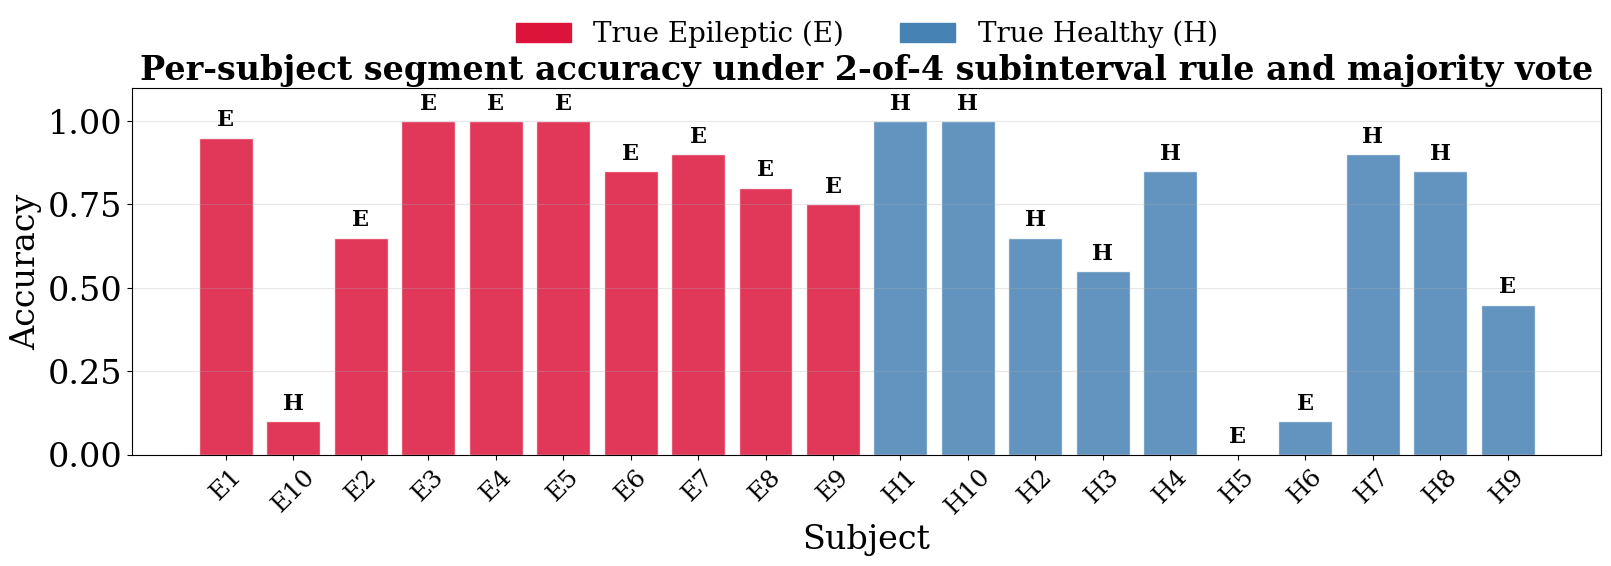

In [58]:
fig, ax = plt.subplots(figsize=(16, 6))
colors = subj_stats["group"].map({"E": "crimson", "H": "steelblue"})

bars = ax.bar(
    subj_stats["subject"],
    subj_stats["accuracy"],
    color=colors,
    edgecolor="white",
    alpha=0.85
)

#ax.axhline(acc, ls="--", color="black", lw=1.5, label=f"Overall acc = {acc:.3f}")
ax.set_ylim(0, 1.10)
ax.set_ylabel("Accuracy", fontsize=FONT_SIZE)
ax.set_xlabel("Subject", fontsize=FONT_SIZE)
ax.set_title("Per-subject segment accuracy under 2-of-4 subinterval rule and majority vote",
             fontweight="bold", fontsize=FONT_SIZE)
ax.tick_params(axis='x', labelrotation=45, labelsize=18)
ax.tick_params(axis='y', labelsize=FONT_SIZE)

# map majority-vote subject prediction onto the same subject order as subj_stats
subject_pred_map = (
    subject_df.set_index("subject")["subject_predicted_label"]
    .map({1: "E", 0: "H"})
    .to_dict()
)

pred_labels = subj_stats["subject"].map(subject_pred_map)

for bar, pred_lbl in zip(bars, pred_labels):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        pred_lbl,
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold",
        color="black"
    )


legend_handles = [
    Patch(color="crimson", label="True Epileptic (E)"),
    Patch(color="steelblue", label="True Healthy (H)")
]
ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.25),
    ncol=3,
    fontsize=20,
    frameon=False
)

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("rule_2of4_per_subject_segment_accuracy_majority_labels.png", dpi=150)
plt.show()

Using trained model from variable: best_pipe
Downloaded/available test files: 400/400

Quarter-level dataframe shape: (1600, 8)
Sample-level dataframe shape : (400, 17)
4-SUBINTERVAL 3-OF-4 RULE TEST PERFORMANCE — model: best_pipe
Segments evaluated          : 400
Epileptic (E)               : 200
Healthy (H)                 : 200
------------------------------------------------------------------------
Accuracy                    : 0.7025 (70.25%)
Balanced Accuracy           : 0.7025
Sensitivity / Recall (E)    : 0.6650
Specificity / Recall (H)    : 0.7400
Precision (E)               : 0.7189
F1-score (E)                : 0.6909
ROC-AUC                     : 0.7714
Average Precision (PR-AUC)  : 0.7481
Matthews Corr. Coef.        : 0.4061
Cohen Kappa                 : 0.4050

               precision    recall  f1-score   support

  Healthy (H)       0.69      0.74      0.71       200
Epileptic (E)       0.72      0.67      0.69       200

     accuracy                           0.70   

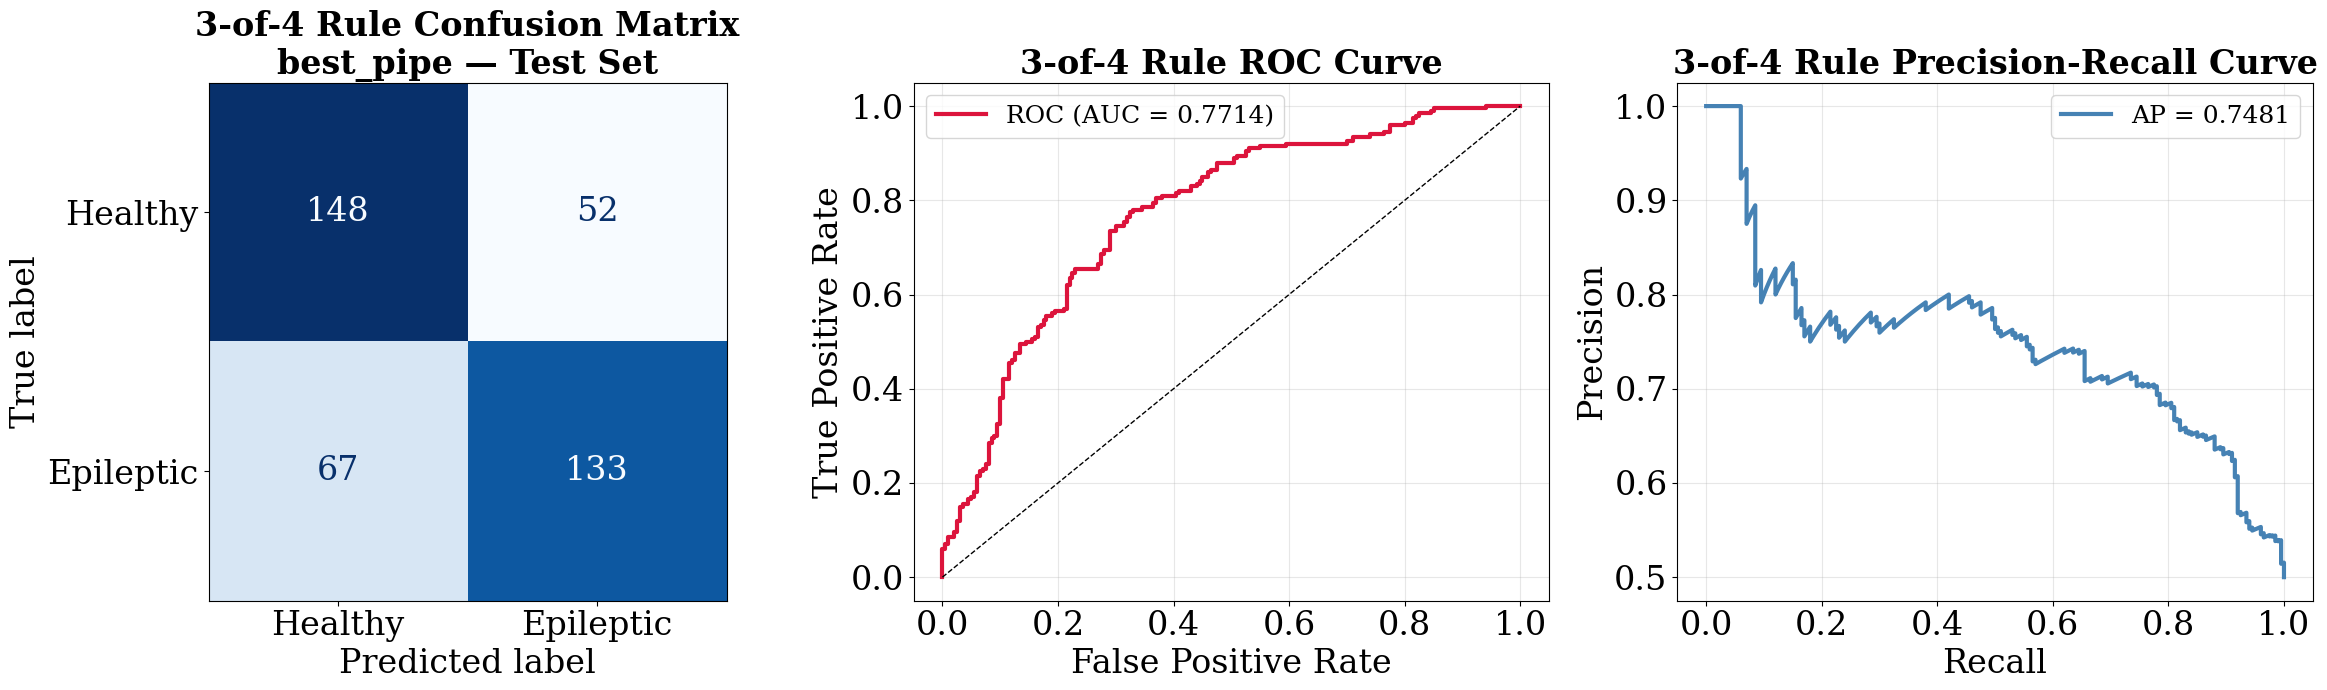

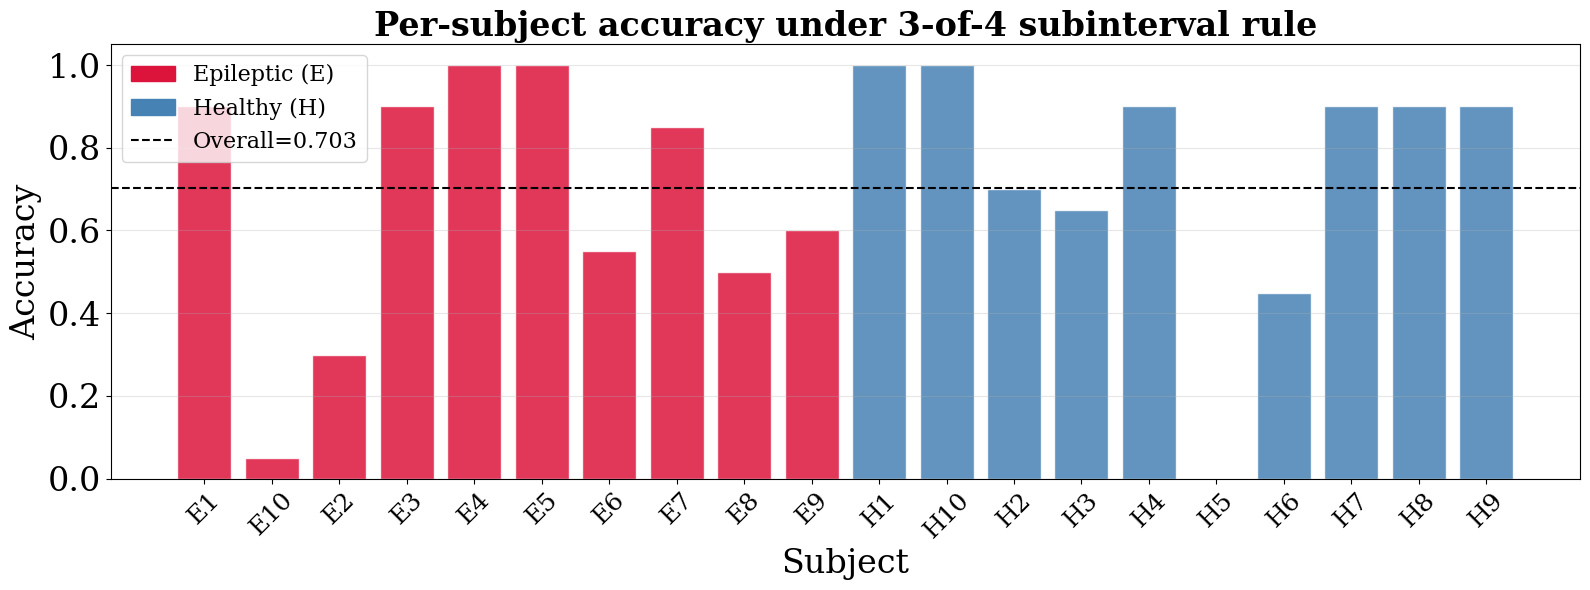

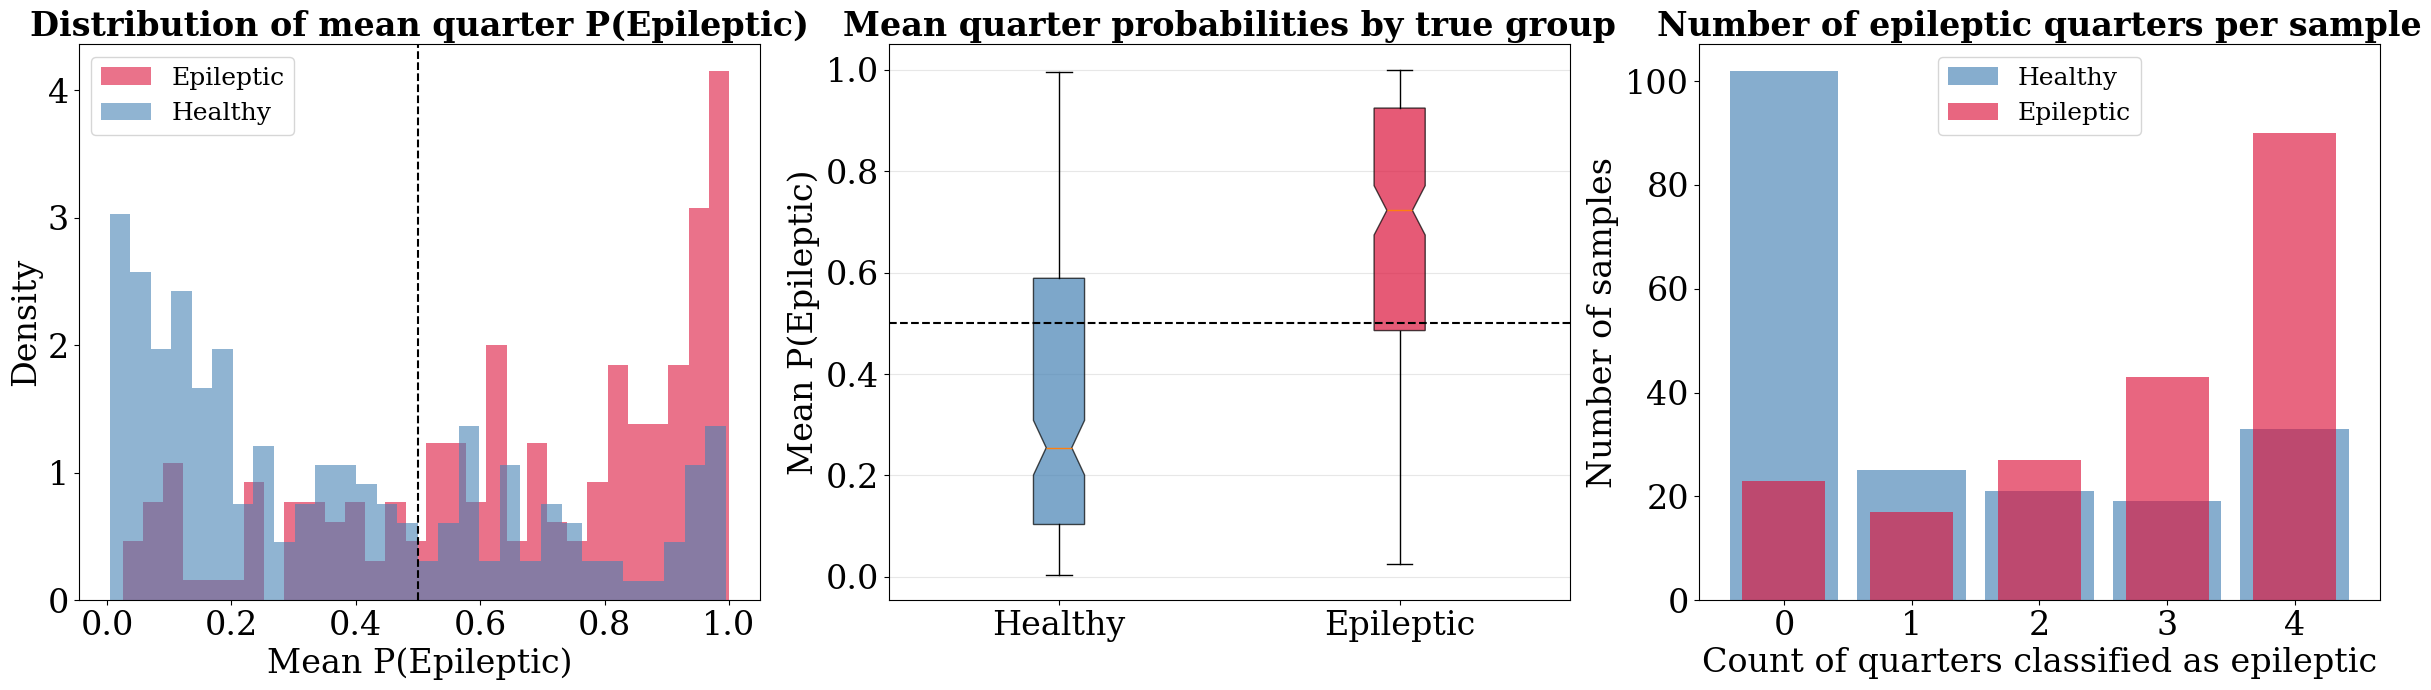

In [30]:
# ─── Additional cell: 4-subinterval classification using THREE-OF-FOUR rule ───
# Rule: classify a sample as Epileptic if at least THREE of the FOUR subintervals are epileptic

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
    precision_score, recall_score, f1_score
)
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

FONT_SIZE = 24

# ------------------------------------------------------------------
# 0) Resolve the trained classifier already created earlier
# ------------------------------------------------------------------
model_candidates = ["bestpipe", "best_pipe", "final_model", "best_accuracy_pipe", "best_accuracy_model"]
resolved_model_name = None
resolved_model = None

for nm in model_candidates:
    if nm in globals():
        resolved_model_name = nm
        resolved_model = globals()[nm]
        break

if resolved_model is None:
    raise NameError(
        "No trained classifier found in memory. Run the earlier training cell first. "
        "Expected one of: bestpipe, best_pipe, final_model, best_accuracy_pipe, best_accuracy_model."
    )

print(f"Using trained model from variable: {resolved_model_name}")

# ------------------------------------------------------------------
# 1) Verify required notebook objects exist
# ------------------------------------------------------------------
required_names = ["ZENODO_BASE", "FS", "download_file", "load_txt_series", "extract_features", "selected_feats"]
missing_required = [nm for nm in required_names if nm not in globals()]
if missing_required:
    raise NameError(
        f"Missing required objects from earlier notebook cells: {missing_required}. "
        "Run the feature-extraction / model-training part of the notebook first."
    )

# ------------------------------------------------------------------
# 2) Download / verify Zenodo test data
# ------------------------------------------------------------------
TEST_DIR = "eeg_test_data"
os.makedirs(TEST_DIR, exist_ok=True)

test_file_list = []
for group, true_label in [("E", 1), ("H", 0)]:
    for subject in range(1, 11):
        for seg in range(1, 21):
            fname = f"{group}{subject}_{seg}.txt"
            url = ZENODO_BASE + fname + "?download=1"
            path = os.path.join(TEST_DIR, fname)
            test_file_list.append((url, path, true_label, fname))

ok_test = 0
for url, path, true_label, fname in test_file_list:
    if download_file(url, path):
        ok_test += 1

print(f"Downloaded/available test files: {ok_test}/{len(test_file_list)}")

# ------------------------------------------------------------------
# 3) Quarter-wise classification for each test sample
#    Final rule: Epileptic if at least 3 of 4 quarters are epileptic
# ------------------------------------------------------------------
sample_rows = []
quarter_rows = []

for url, path, true_label, fname in test_file_list:
    if not os.path.exists(path):
        continue

    x = load_txt_series(path)
    if len(x) < 1000:
        continue

    parts = np.array_split(x, 4)

    q_preds = []
    q_probs = []

    for q_idx, part in enumerate(parts, start=1):
        try:
            feat_dict = extract_features(part, fs=FS)
            feat_df = pd.DataFrame([feat_dict])

            missing = [f for f in selected_feats if f not in feat_df.columns]
            for m in missing:
                feat_df[m] = 0.0

            X_part = feat_df[selected_feats].fillna(0.0).values

            pred = int(resolved_model.predict(X_part)[0])
            prob = float(resolved_model.predict_proba(X_part)[0, 1])

            q_preds.append(pred)
            q_probs.append(prob)

            quarter_rows.append({
                "filename": fname,
                "subject": fname.split("_")[0],
                "group": fname[0],
                "true_label": int(true_label),
                "quarter": q_idx,
                "quarter_length": len(part),
                "quarter_pred": pred,
                "quarter_prob_epileptic": prob
            })

        except Exception as e:
            print(f"Skipped {fname}, quarter {q_idx}: {e}")

    if len(q_preds) != 4:
        continue

    n_ep_quarters = int(sum(q_preds))
    final_pred = int(n_ep_quarters >= 3)
    final_prob = float(np.mean(q_probs))

    sample_rows.append({
        "filename": fname,
        "subject": fname.split("_")[0],
        "group": fname[0],
        "true_label": int(true_label),
        "predicted_label": final_pred,
        "prob_epileptic": final_prob,
        "n_epileptic_quarters": n_ep_quarters,
        "mean_quarter_prob_epileptic": float(np.mean(q_probs)),
        "std_quarter_prob_epileptic": float(np.std(q_probs)),
        "q1_pred": q_preds[0], "q2_pred": q_preds[1], "q3_pred": q_preds[2], "q4_pred": q_preds[3],
        "q1_prob": q_probs[0], "q2_prob": q_probs[1], "q3_prob": q_probs[2], "q4_prob": q_probs[3]
    })

df_quarters = pd.DataFrame(quarter_rows)
df_samples = pd.DataFrame(sample_rows)

if df_samples.empty:
    raise ValueError(
        "No valid test samples were processed. "
        "Most likely causes: the trained model variable is missing, selected_feats is missing, "
        "or extract_features failed on quarter-length segments."
    )

df_quarters.to_csv("quarter_level_predictions_3of4_rule.csv", index=False)
df_samples.to_csv("sample_level_predictions_3of4_rule.csv", index=False)

print(f"\nQuarter-level dataframe shape: {df_quarters.shape}")
print(f"Sample-level dataframe shape : {df_samples.shape}")

# ------------------------------------------------------------------
# 4) Metrics
# ------------------------------------------------------------------
y_true = df_samples["true_label"].astype(int).values
y_pred = df_samples["predicted_label"].astype(int).values
y_prob = df_samples["prob_epileptic"].astype(float).values

acc = accuracy_score(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)
avg_prec = average_precision_score(y_true, y_prob)
mcc = matthews_corrcoef(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
sens = recall_score(y_true, y_pred, pos_label=1)
spec = recall_score(y_true, y_pred, pos_label=0)
prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

print("=" * 72)
print(f"4-SUBINTERVAL 3-OF-4 RULE TEST PERFORMANCE — model: {resolved_model_name}")
print("=" * 72)
print(f"Segments evaluated          : {len(y_true)}")
print(f"Epileptic (E)               : {(y_true == 1).sum()}")
print(f"Healthy (H)                 : {(y_true == 0).sum()}")
print("-" * 72)
print(f"Accuracy                    : {acc:.4f} ({acc*100:.2f}%)")
print(f"Balanced Accuracy           : {bal_acc:.4f}")
print(f"Sensitivity / Recall (E)    : {sens:.4f}")
print(f"Specificity / Recall (H)    : {spec:.4f}")
print(f"Precision (E)               : {prec:.4f}")
print(f"F1-score (E)                : {f1:.4f}")
print(f"ROC-AUC                     : {roc_auc:.4f}")
print(f"Average Precision (PR-AUC)  : {avg_prec:.4f}")
print(f"Matthews Corr. Coef.        : {mcc:.4f}")
print(f"Cohen Kappa                 : {kappa:.4f}")
print("=" * 72)
print()
print(classification_report(y_true, y_pred, target_names=["Healthy (H)", "Epileptic (E)"], zero_division=0))

# ------------------------------------------------------------------
# 5) Statistical characterization of output
# ------------------------------------------------------------------
stats_output = df_samples.groupby("true_label").agg(
    n_samples=("filename", "count"),
    mean_prob_epileptic=("prob_epileptic", "mean"),
    std_prob_epileptic=("prob_epileptic", "std"),
    median_prob_epileptic=("prob_epileptic", "median"),
    mean_epileptic_quarters=("n_epileptic_quarters", "mean"),
    std_epileptic_quarters=("n_epileptic_quarters", "std"),
    median_epileptic_quarters=("n_epileptic_quarters", "median")
).reset_index()

stats_output["group_name"] = stats_output["true_label"].map({0: "Healthy", 1: "Epileptic"})
print("\nStatistical characterization of output:")
print(stats_output.to_string(index=False))

# ------------------------------------------------------------------
# 6) Per-subject accuracy
# ------------------------------------------------------------------
df_samples["correct"] = (df_samples["predicted_label"] == df_samples["true_label"]).astype(int)

subj_stats = df_samples.groupby(["subject", "group", "true_label"]).agg(
    n_segments=("correct", "count"),
    n_correct=("correct", "sum"),
    accuracy=("correct", "mean"),
    mean_prob_epileptic=("prob_epileptic", "mean"),
    std_prob_epileptic=("prob_epileptic", "std"),
    mean_epileptic_quarters=("n_epileptic_quarters", "mean")
).reset_index().sort_values(["group", "subject"])

print("\nPer-subject accuracy:")
print(subj_stats.to_string(index=False))

# ------------------------------------------------------------------
# 7) Visualizations
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "Epileptic"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"3-of-4 Rule Confusion Matrix\n{resolved_model_name} — Test Set",
                  fontweight="bold", fontsize=FONT_SIZE)
axes[0].set_xlabel("Predicted label", fontsize=FONT_SIZE)
axes[0].set_ylabel("True label", fontsize=FONT_SIZE)
axes[0].tick_params(axis='both', labelsize=FONT_SIZE)
for txt in axes[0].texts:
    txt.set_fontsize(FONT_SIZE)

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, lw=3, color="crimson", label=f"ROC (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate", fontsize=FONT_SIZE)
axes[1].set_ylabel("True Positive Rate", fontsize=FONT_SIZE)
axes[1].set_title("3-of-4 Rule ROC Curve", fontweight="bold", fontsize=FONT_SIZE)
axes[1].legend(fontsize=18)
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='both', labelsize=FONT_SIZE)

prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
axes[2].plot(rec_curve, prec_curve, lw=3, color="steelblue",
             label=f"AP = {avg_prec:.4f}")
axes[2].set_xlabel("Recall", fontsize=FONT_SIZE)
axes[2].set_ylabel("Precision", fontsize=FONT_SIZE)
axes[2].set_title("3-of-4 Rule Precision-Recall Curve", fontweight="bold", fontsize=FONT_SIZE)
axes[2].legend(fontsize=18)
axes[2].grid(alpha=0.3)
axes[2].tick_params(axis='both', labelsize=FONT_SIZE)

plt.tight_layout()
plt.savefig("rule_3of4_curves.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(16, 6))
colors = subj_stats["group"].map({"E": "crimson", "H": "steelblue"})
ax.bar(subj_stats["subject"], subj_stats["accuracy"], color=colors, edgecolor="white", alpha=0.85)
ax.axhline(acc, ls="--", color="black", lw=1.5, label=f"Overall acc = {acc:.3f}")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy", fontsize=FONT_SIZE)
ax.set_xlabel("Subject", fontsize=FONT_SIZE)
ax.set_title("Per-subject accuracy under 3-of-4 subinterval rule",
             fontweight="bold", fontsize=FONT_SIZE)
ax.tick_params(axis='x', labelrotation=45, labelsize=18)
ax.tick_params(axis='y', labelsize=FONT_SIZE)
legend_handles = [
    Patch(color="crimson", label="Epileptic (E)"),
    Patch(color="steelblue", label="Healthy (H)")
]
ax.legend(
    handles=legend_handles + [
        plt.Line2D([0], [0], color="black", ls="--", label=f"Overall={acc:.3f}")
    ],
    fontsize=16
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("rule_3of4_per_subject_accuracy.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for lbl, name, color in [(1, "Epileptic", "crimson"), (0, "Healthy", "steelblue")]:
    vals = df_samples.loc[df_samples["true_label"] == lbl, "prob_epileptic"]
    axes[0].hist(vals, bins=30, alpha=0.60, density=True, color=color, label=name)

axes[0].axvline(0.5, color="black", ls="--", lw=1.5)
axes[0].set_title("Distribution of mean quarter P(Epileptic)",
                  fontweight="bold", fontsize=FONT_SIZE)
axes[0].set_xlabel("Mean P(Epileptic)", fontsize=FONT_SIZE)
axes[0].set_ylabel("Density", fontsize=FONT_SIZE)
axes[0].legend(fontsize=18)
axes[0].tick_params(axis='both', labelsize=FONT_SIZE)

data_H = df_samples.loc[df_samples["true_label"] == 0, "prob_epileptic"]
data_E = df_samples.loc[df_samples["true_label"] == 1, "prob_epileptic"]
bp = axes[1].boxplot([data_H, data_E], tick_labels=["Healthy", "Epileptic"],
                     patch_artist=True, notch=True)
for patch, color in zip(bp["boxes"], ["steelblue", "crimson"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(0.5, color="black", ls="--", lw=1.5)
axes[1].set_title("Mean quarter probabilities by true group",
                  fontweight="bold", fontsize=FONT_SIZE)
axes[1].set_ylabel("Mean P(Epileptic)", fontsize=FONT_SIZE)
axes[1].tick_params(axis='both', labelsize=FONT_SIZE)
axes[1].grid(axis="y", alpha=0.3)

counts_H = df_samples.loc[df_samples["true_label"] == 0, "n_epileptic_quarters"]
counts_E = df_samples.loc[df_samples["true_label"] == 1, "n_epileptic_quarters"]
bins = np.arange(-0.5, 5.5, 1)
axes[2].hist(counts_H, bins=bins, alpha=0.65, color="steelblue", label="Healthy", rwidth=0.85)
axes[2].hist(counts_E, bins=bins, alpha=0.65, color="crimson", label="Epileptic", rwidth=0.65)
axes[2].set_xticks([0, 1, 2, 3, 4])
axes[2].set_title("Number of epileptic quarters per sample",
                  fontweight="bold", fontsize=FONT_SIZE)
axes[2].set_xlabel("Count of quarters classified as epileptic", fontsize=FONT_SIZE)
axes[2].set_ylabel("Number of samples", fontsize=FONT_SIZE)
axes[2].legend(fontsize=18)
axes[2].tick_params(axis='both', labelsize=FONT_SIZE)

plt.tight_layout()
plt.savefig("rule_3of4_statistics.png", dpi=150)
plt.show()

Using trained model from variable: best_pipe
Downloaded/available test files: 400/400
SUBJECT-LEVEL PERFORMANCE — 3-of-4 rule + majority vote (>50%)
Subjects evaluated          : 20
Epileptic subjects          : 10
Healthy subjects            : 10
------------------------------------------------------------------------
Accuracy                    : 0.7500 (75.00%)
Balanced Accuracy           : 0.7500
Sensitivity / Recall (E)    : 0.7000
Specificity / Recall (H)    : 0.8000
Precision (E)               : 0.7778
F1-score (E)                : 0.7368
ROC-AUC                     : 0.8000
Average Precision (PR-AUC)  : 0.7449
Matthews Corr. Coef.        : 0.5025
Cohen Kappa                 : 0.5000

               precision    recall  f1-score   support

  Healthy (H)       0.73      0.80      0.76        10
Epileptic (E)       0.78      0.70      0.74        10

     accuracy                           0.75        20
    macro avg       0.75      0.75      0.75        20
 weighted avg       0.

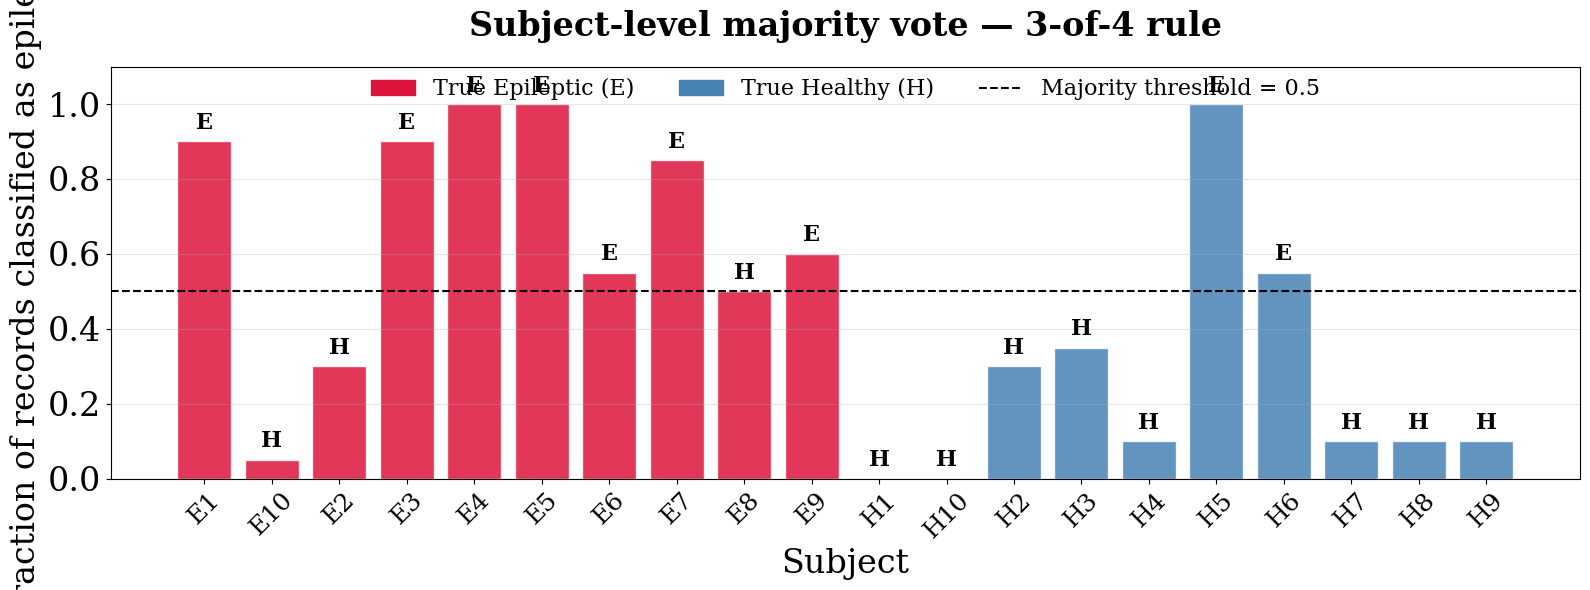

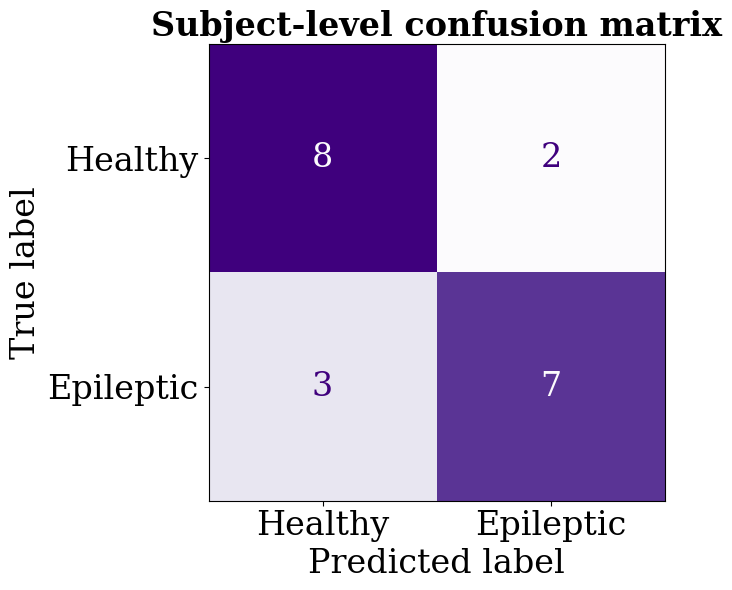

In [61]:
# ─── Additional cell: 3-of-4 segment rule + 50% subject majority vote visualization ───
# Segment rule: classify a sample as Epileptic if at least 3 of 4 subintervals are epileptic
# Subject rule: classify a subject as Epileptic if > 50% of that subject's records are classified as epileptic

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
)
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

FONT_SIZE = 24

# ------------------------------------------------------------------
# 0) Resolve trained model
# ------------------------------------------------------------------
model_candidates = ["bestpipe", "best_pipe", "final_model", "best_accuracy_pipe", "best_accuracy_model"]
resolved_model_name = None
resolved_model = None

for nm in model_candidates:
    if nm in globals():
        resolved_model_name = nm
        resolved_model = globals()[nm]
        break

if resolved_model is None:
    raise NameError(
        "No trained classifier found in memory. Run the earlier training cell first. "
        "Expected one of: bestpipe, best_pipe, final_model, best_accuracy_pipe, best_accuracy_model."
    )

print(f"Using trained model from variable: {resolved_model_name}")

# ------------------------------------------------------------------
# 1) Verify required objects exist
# ------------------------------------------------------------------
required_names = ["ZENODO_BASE", "FS", "download_file", "load_txt_series", "extract_features", "selected_feats"]
missing_required = [nm for nm in required_names if nm not in globals()]
if missing_required:
    raise NameError(
        f"Missing required objects from earlier notebook cells: {missing_required}. "
        "Run the feature-extraction / model-training part of the notebook first."
    )

# ------------------------------------------------------------------
# 2) Download / verify test data
# ------------------------------------------------------------------
TEST_DIR = "eeg_test_data"
os.makedirs(TEST_DIR, exist_ok=True)

test_file_list = []
for group, true_label in [("E", 1), ("H", 0)]:
    for subject in range(1, 11):
        for seg in range(1, 21):
            fname = f"{group}{subject}_{seg}.txt"
            url = ZENODO_BASE + fname + "?download=1"
            path = os.path.join(TEST_DIR, fname)
            test_file_list.append((url, path, true_label, fname))

ok_test = 0
for url, path, true_label, fname in test_file_list:
    if download_file(url, path):
        ok_test += 1

print(f"Downloaded/available test files: {ok_test}/{len(test_file_list)}")

# ------------------------------------------------------------------
# 3) Segment-level prediction using 3-of-4 rule
# ------------------------------------------------------------------
sample_rows = []

for url, path, true_label, fname in test_file_list:
    if not os.path.exists(path):
        continue

    x = load_txt_series(path)
    if len(x) < 1000:
        continue

    parts = np.array_split(x, 4)
    q_preds = []
    q_probs = []

    for q_idx, part in enumerate(parts, start=1):
        try:
            feat_dict = extract_features(part, fs=FS)
            feat_df = pd.DataFrame([feat_dict])

            missing = [f for f in selected_feats if f not in feat_df.columns]
            for m in missing:
                feat_df[m] = 0.0

            X_part = feat_df[selected_feats].fillna(0.0).values
            pred = int(resolved_model.predict(X_part)[0])
            prob = float(resolved_model.predict_proba(X_part)[0, 1])

            q_preds.append(pred)
            q_probs.append(prob)

        except Exception as e:
            print(f"Skipped {fname}, quarter {q_idx}: {e}")

    if len(q_preds) != 4:
        continue

    n_ep_quarters = int(sum(q_preds))
    final_pred = int(n_ep_quarters >= 3)
    final_prob = float(np.mean(q_probs))

    sample_rows.append({
        "filename": fname,
        "subject": fname.split("_")[0],
        "group": fname[0],
        "true_label": int(true_label),
        "predicted_label": final_pred,
        "prob_epileptic": final_prob,
        "n_epileptic_quarters": n_ep_quarters
    })

df_samples = pd.DataFrame(sample_rows)

if df_samples.empty:
    raise ValueError("No valid samples were processed.")

df_samples.to_csv("sample_level_predictions_3of4_rule.csv", index=False)

# ------------------------------------------------------------------
# 4) Subject-level majority vote (>50%)
# ------------------------------------------------------------------
subject_df = (
    df_samples
    .groupby(["subject", "group", "true_label"], as_index=False)
    .agg(
        n_segments=("filename", "count"),
        n_predicted_epileptic_segments=("predicted_label", "sum"),
        mean_segment_prob_epileptic=("prob_epileptic", "mean"),
        std_segment_prob_epileptic=("prob_epileptic", "std"),
        mean_epileptic_quarters=("n_epileptic_quarters", "mean")
    )
)

subject_df["fraction_predicted_epileptic"] = (
    subject_df["n_predicted_epileptic_segments"] / subject_df["n_segments"]
)
subject_df["subject_predicted_label"] = (
    subject_df["fraction_predicted_epileptic"] > 0.5
).astype(int)
subject_df["subject_correct"] = (
    subject_df["subject_predicted_label"] == subject_df["true_label"]
).astype(int)

subject_df.to_csv("subject_level_predictions_3of4_majority_vote.csv", index=False)

# ------------------------------------------------------------------
# 5) Subject-level metrics
# ------------------------------------------------------------------
y_true_subj = subject_df["true_label"].astype(int).values
y_pred_subj = subject_df["subject_predicted_label"].astype(int).values
y_prob_subj = subject_df["fraction_predicted_epileptic"].astype(float).values

acc_subj = accuracy_score(y_true_subj, y_pred_subj)
bal_acc_subj = balanced_accuracy_score(y_true_subj, y_pred_subj)
mcc_subj = matthews_corrcoef(y_true_subj, y_pred_subj)
kappa_subj = cohen_kappa_score(y_true_subj, y_pred_subj)
sens_subj = recall_score(y_true_subj, y_pred_subj, pos_label=1, zero_division=0)
spec_subj = recall_score(y_true_subj, y_pred_subj, pos_label=0, zero_division=0)
prec_subj = precision_score(y_true_subj, y_pred_subj, pos_label=1, zero_division=0)
f1_subj = f1_score(y_true_subj, y_pred_subj, pos_label=1, zero_division=0)

if len(np.unique(y_true_subj)) > 1:
    roc_auc_subj = roc_auc_score(y_true_subj, y_prob_subj)
    avg_prec_subj = average_precision_score(y_true_subj, y_prob_subj)
else:
    roc_auc_subj = np.nan
    avg_prec_subj = np.nan

print("=" * 72)
print("SUBJECT-LEVEL PERFORMANCE — 3-of-4 rule + majority vote (>50%)")
print("=" * 72)
print(f"Subjects evaluated          : {len(y_true_subj)}")
print(f"Epileptic subjects          : {(y_true_subj == 1).sum()}")
print(f"Healthy subjects            : {(y_true_subj == 0).sum()}")
print("-" * 72)
print(f"Accuracy                    : {acc_subj:.4f} ({acc_subj*100:.2f}%)")
print(f"Balanced Accuracy           : {bal_acc_subj:.4f}")
print(f"Sensitivity / Recall (E)    : {sens_subj:.4f}")
print(f"Specificity / Recall (H)    : {spec_subj:.4f}")
print(f"Precision (E)               : {prec_subj:.4f}")
print(f"F1-score (E)                : {f1_subj:.4f}")
print(f"ROC-AUC                     : {roc_auc_subj:.4f}")
print(f"Average Precision (PR-AUC)  : {avg_prec_subj:.4f}")
print(f"Matthews Corr. Coef.        : {mcc_subj:.4f}")
print(f"Cohen Kappa                 : {kappa_subj:.4f}")
print("=" * 72)
print()
print(classification_report(y_true_subj, y_pred_subj, target_names=["Healthy (H)", "Epileptic (E)"], zero_division=0))
print(subject_df.sort_values(["group", "subject"]).to_string(index=False))

# ------------------------------------------------------------------
# 6) Visualization: subject majority-vote diagram
# ------------------------------------------------------------------
subject_df_plot = subject_df.sort_values(["group", "subject"]).copy()
colors = subject_df_plot["group"].map({"E": "crimson", "H": "steelblue"})

fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(
    subject_df_plot["subject"],
    subject_df_plot["fraction_predicted_epileptic"],
    color=colors,
    edgecolor="white",
    alpha=0.85
)

ax.axhline(0.5, ls="--", color="black", lw=1.5)

ax.set_ylim(0, 1.10)
ax.set_ylabel("Fraction of records classified as epileptic", fontsize=FONT_SIZE)
ax.set_xlabel("Subject", fontsize=FONT_SIZE)
ax.set_title("Subject-level majority vote — 3-of-4 rule",
             fontweight="bold", fontsize=FONT_SIZE, pad=22)

ax.tick_params(axis='x', labelrotation=45, labelsize=18)
ax.tick_params(axis='y', labelsize=FONT_SIZE)

pred_labels = subject_df_plot["subject_predicted_label"].map({1: "E", 0: "H"})

for bar, pred_lbl in zip(bars, pred_labels):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        pred_lbl,
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold",
        color="black"
    )

legend_handles = [
    Patch(color="crimson", label="True Epileptic (E)"),
    Patch(color="steelblue", label="True Healthy (H)"),
    plt.Line2D([0], [0], color="black", ls="--", lw=1.5, label="Majority threshold = 0.5")
]

ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    fontsize=16,
    frameon=False
)

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("subject_majority_vote_3of4.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# 7) Visualization: subject-level confusion matrix
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))
cm_subj = confusion_matrix(y_true_subj, y_pred_subj)
disp_subj = ConfusionMatrixDisplay(cm_subj, display_labels=["Healthy", "Epileptic"])
disp_subj.plot(ax=ax, cmap="Purples", colorbar=False)

ax.set_title("Subject-level confusion matrix", fontweight="bold", fontsize=FONT_SIZE)
ax.set_xlabel("Predicted label", fontsize=FONT_SIZE)
ax.set_ylabel("True label", fontsize=FONT_SIZE)
ax.tick_params(axis='both', labelsize=FONT_SIZE)

for txt in ax.texts:
    txt.set_fontsize(FONT_SIZE)

plt.tight_layout()
plt.savefig("subject_majority_vote_3of4_confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd
import numpy as np
import joblib

# ---- resolve training matrix name used earlier in the notebook ----
if "X_sel" in globals():
    X_train_for_acc = X_sel
elif "Xsel" in globals():
    X_train_for_acc = Xsel
else:
    raise NameError("X_sel/Xsel is not defined. Run the feature-selection cell first.")

# ---- resolve selected feature names ----
if "selectedfeats" in globals():
    selected_feature_names_for_acc = list(selectedfeats)
elif "featurenames" in globals():
    selected_feature_names_for_acc = list(featurenames)
elif "featurecols" in globals() and hasattr(X_train_for_acc, "shape") and len(featurecols) == X_train_for_acc.shape[1]:
    selected_feature_names_for_acc = list(featurecols)
else:
    selected_feature_names_for_acc = [f"feature_{i}" for i in range(X_train_for_acc.shape[1])]

# ---- checks ----
required_names = ["y", "classifiers"]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise NameError(
        "Missing required variables from previous cells: " + ", ".join(missing) +
        ". Run the feature-extraction/training-data preparation cells first."
    )

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_results = []
for name, model in classifiers.items():
    scores = cross_val_score(
        model,
        X_train_for_acc,
        y,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )
    acc_results.append({
        "model": name,
        "cv_accuracy_mean": float(np.mean(scores)),
        "cv_accuracy_std": float(np.std(scores)),
        "fold_scores": scores.tolist()
    })

acc_results_df = pd.DataFrame(acc_results).sort_values(
    by="cv_accuracy_mean",
    ascending=False
).reset_index(drop=True)

best_accuracy_model_name = acc_results_df.loc[0, "model"]
best_accuracy_model = classifiers[best_accuracy_model_name]
best_accuracy_model.fit(X_train_for_acc, y)

print("Accuracy-based model ranking:")
print(acc_results_df[["model", "cv_accuracy_mean", "cv_accuracy_std"]].to_string(index=False))

print("\nBest model by CV accuracy:", best_accuracy_model_name)
print("Mean CV accuracy:", round(acc_results_df.loc[0, "cv_accuracy_mean"], 4))
print("Std CV accuracy:", round(acc_results_df.loc[0, "cv_accuracy_std"], 4))

joblib.dump(best_accuracy_model, "best_eeg_classifier_accuracy.pkl")
with open("selected_features_accuracy.txt", "w") as fh:
    fh.write("\n".join(selected_feature_names_for_acc))

print("\nSaved accuracy-based pipeline: best_eeg_classifier_accuracy.pkl")
print("Saved feature list: selected_features_accuracy.txt")


def classify_new_eeg_accuracy(
    txtfilepath,
    modelpath="best_eeg_classifier_accuracy.pkl",
    featurelistpath="selected_features_accuracy.txt",
    fs=FS,
    verbose=True,
):
    pipe = joblib.load(modelpath)

    with open(featurelistpath) as fh:
        featsused = [line.strip() for line in fh if line.strip()]

    x = load_txt_series(txtfilepath)
    if len(x) < 500:
        raise ValueError(f"Signal too short ({len(x)} samples). Minimum 500.")

    featdict = extract_features(x, fs=fs)
    featdf = pd.DataFrame([featdict])

    missing = [f for f in featsused if f not in featdf.columns]
    if missing:
        if verbose:
            print(f"Warning: {len(missing)} features missing; filled with 0.0 -> {missing}")
        for m in missing:
            featdf[m] = 0.0

    X_new = featdf[featsused].fillna(0.0).values

    label = int(pipe.predict(X_new)[0])
    prob = float(pipe.predict_proba(X_new)[0, 1]) if hasattr(pipe, "predict_proba") else None

    if verbose:
        print("\nEEG Classification Result (accuracy-selected model)")
        print(f"File: {txtfilepath}")
        print(f"Prediction: {'Epileptic' if label else 'Healthy'}")
        if prob is not None:
            print(f"P(Epileptic): {prob:.4f}")
            print(f"P(Healthy): {1 - prob:.4f}")
            if prob > 0.7:
                print("HIGH confidence Epileptic")
            elif prob < 0.3:
                print("HIGH confidence Healthy")
            else:
                print("UNCERTAIN / borderline case; consult specialist")

    return label, prob, featdf

In [ ]:
# ─── Accuracy-based model selection + Zenodo test evaluation + visualization ────
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score
)
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import joblib

# ------------------------------------------------------------------
# 1) Select best model by cross-validated accuracy on training data
# ------------------------------------------------------------------
acc_results = []

for name, clf in classifiers.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", clf)
    ])

    scores = cross_val_score(
        pipe,
        X_sel,
        y,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    acc_results.append({
        "model": name,
        "cv_accuracy_mean": float(np.mean(scores)),
        "cv_accuracy_std": float(np.std(scores)),
        "fold_scores": scores.tolist()
    })

acc_results_df = (
    pd.DataFrame(acc_results)
    .sort_values("cv_accuracy_mean", ascending=False)
    .reset_index(drop=True)
)

print("Accuracy-based model ranking:")
print(acc_results_df[["model", "cv_accuracy_mean", "cv_accuracy_std"]].to_string(index=False))

best_accuracy_name = acc_results_df.loc[0, "model"]
print(f"\nBest classifier by mean Accuracy: {best_accuracy_name}")

best_accuracy_clf = classifiers[best_accuracy_name]
best_accuracy_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", best_accuracy_clf)
])

best_accuracy_pipe.fit(X_sel, y)

joblib.dump(best_accuracy_pipe, "best_eeg_classifier_accuracy.pkl")
with open("selected_features_accuracy.txt", "w") as fh:
    fh.write("\n".join(selected_feats))

print("\nSaved:")
print("  best_eeg_classifier_accuracy.pkl")
print("  selected_features_accuracy.txt")

# ------------------------------------------------------------------
# 2) Inference helper for user-provided data
# ------------------------------------------------------------------
def classify_new_eeg_accuracy(txt_file_path,
                              model_path="best_eeg_classifier_accuracy.pkl",
                              feature_list_path="selected_features_accuracy.txt",
                              fs=FS,
                              verbose=True):
    pipe = joblib.load(model_path)

    with open(feature_list_path) as fh:
        feats_used = [line.strip() for line in fh if line.strip()]

    x = load_txt_series(txt_file_path)
    if len(x) < 500:
        raise ValueError(f"Signal too short ({len(x)} samples). Minimum 500.")

    feat_dict = extract_features(x, fs=fs)
    feat_df = pd.DataFrame([feat_dict])

    missing = [f for f in feats_used if f not in feat_df.columns]
    for m in missing:
        feat_df[m] = 0.0

    X_new = feat_df[feats_used].fillna(0.0).values

    label = int(pipe.predict(X_new)[0])
    prob = float(pipe.predict_proba(X_new)[0, 1])

    if verbose:
        print("\n=== EEG Classification Result (accuracy-selected model) ===")
        print(f"  File        : {os.path.basename(txt_file_path)}")
        print(f"  Prediction  : {'Epileptic' if label else 'Healthy'}")
        print(f"  P(Epileptic): {prob:.4f}")
        print(f"  P(Healthy)  : {1 - prob:.4f}")

    return label, prob, feat_df

# ------------------------------------------------------------------
# 3) Download Zenodo held-out E/H test data
# ------------------------------------------------------------------
TEST_DIR = "eeg_test_data"
os.makedirs(TEST_DIR, exist_ok=True)

def build_test_file_list():
    entries = []
    for group, true_label in [("E", 1), ("H", 0)]:
        for subject in range(1, 11):   # 10 subjects per class
            for seg in range(1, 21):   # 20 segments per subject
                fname = f"{group}{subject}_{seg}.txt"
                url   = ZENODO_BASE + fname + "?download=1"
                path  = os.path.join(TEST_DIR, fname)
                entries.append((url, path, true_label, fname))
    return entries

test_file_list = build_test_file_list()
print(f"\nTotal test files expected: {len(test_file_list)}")
print("Downloading test data (may take 2–4 minutes) ...")

ok_test = 0
for url, path, lbl, fname in test_file_list:
    if download_file(url, path):
        ok_test += 1

print(f"Downloaded/available: {ok_test}/{len(test_file_list)} test files")

# ------------------------------------------------------------------
# 4) Load test signals and extract features
# ------------------------------------------------------------------
test_records = []
for url, path, true_label, fname in test_file_list:
    if os.path.exists(path):
        x = load_txt_series(path)
        if len(x) >= 1000:
            test_records.append({
                "x": x,
                "true_label": true_label,
                "filename": fname
            })

n_TE = sum(1 for r in test_records if r["true_label"] == 1)
n_TH = sum(1 for r in test_records if r["true_label"] == 0)
print(f"\nTest segments loaded: Epileptic={n_TE}, Healthy={n_TH}, Total={len(test_records)}")

print("\nExtracting features from test set ...")
test_rows = []
for rec in test_records:
    try:
        f = extract_features(rec["x"])
        f["true_label"] = rec["true_label"]
        f["filename"]   = rec["filename"]
        test_rows.append(f)
    except Exception as e:
        print(f"  Skipped {rec['filename']}: {e}")

df_test = pd.DataFrame(test_rows)
df_test.to_csv("eeg_test_features_accuracy_model.csv", index=False)
print(f"Test feature matrix: {df_test.shape}")

X_test_raw = df_test[[c for c in df_test.columns if c not in ("true_label", "filename")]].copy()
X_test_raw = X_test_raw.fillna(X_test_raw.median())

missing_feats = [f for f in selected_feats if f not in X_test_raw.columns]
for m in missing_feats:
    X_test_raw[m] = 0.0

X_test = X_test_raw[selected_feats].values
y_test = df_test["true_label"].values

# ------------------------------------------------------------------
# 5) Predict on Zenodo held-out test set
# ------------------------------------------------------------------
y_pred_test = best_accuracy_pipe.predict(X_test)
y_prob_test = best_accuracy_pipe.predict_proba(X_test)[:, 1]

df_test["predicted_label"] = y_pred_test
df_test["prob_epileptic"]  = y_prob_test
df_test["correct"]         = (y_pred_test == y_test).astype(int)
df_test.to_csv("eeg_test_predictions_accuracy_model.csv", index=False)
print("Predictions saved → eeg_test_predictions_accuracy_model.csv")

# ------------------------------------------------------------------
# 6) Metrics
# ------------------------------------------------------------------
acc      = accuracy_score(y_test, y_pred_test)
bal_acc  = balanced_accuracy_score(y_test, y_pred_test)
roc_auc  = roc_auc_score(y_test, y_prob_test)
avg_prec = average_precision_score(y_test, y_prob_test)
mcc      = matthews_corrcoef(y_test, y_pred_test)
kappa    = cohen_kappa_score(y_test, y_pred_test)

print("=" * 60)
print(f"  TEST SET PERFORMANCE — ACCURACY-SELECTED MODEL: {best_accuracy_name}")
print("=" * 60)
print(f"  Segments evaluated      : {len(y_test)}")
print(f"  Epileptic (E) segments  : {(y_test==1).sum()}")
print(f"  Healthy   (H) segments  : {(y_test==0).sum()}")
print("-" * 60)
print(f"  Accuracy                : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Balanced Accuracy       : {bal_acc:.4f}")
print(f"  ROC-AUC                 : {roc_auc:.4f}")
print(f"  Average Precision (PR)  : {avg_prec:.4f}")
print(f"  Matthews Corr. Coef.    : {mcc:.4f}")
print(f"  Cohen Kappa             : {kappa:.4f}")
print("=" * 60)
print()
print(classification_report(
    y_test, y_pred_test,
    target_names=["Healthy (H)", "Epileptic (E)"]
))

# ------------------------------------------------------------------
# 7) Main visualizations
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=["Healthy", "Epileptic"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix\n{best_accuracy_name} — Test Set", fontweight="bold")

fpr, tpr, _ = roc_curve(y_test, y_prob_test)
axes[1].plot(fpr, tpr, lw=2, color="crimson", label=f"ROC (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — Test Set", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
axes[2].plot(rec, prec, lw=2, color="steelblue", label=f"AP = {avg_prec:.4f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve — Test Set", fontweight="bold")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("test_classification_results_accuracy_model.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# 8) Per-subject performance
# ------------------------------------------------------------------
df_test["subject"] = df_test["filename"].str.extract(r'^([EH]\d+)_')
df_test["group"]   = df_test["filename"].str[0]

subj_stats = df_test.groupby(["subject", "group", "true_label"]).agg(
    n_segments  = ("correct", "count"),
    n_correct   = ("correct", "sum"),
    accuracy    = ("correct", "mean"),
    mean_prob_E = ("prob_epileptic", "mean"),
    std_prob_E  = ("prob_epileptic", "std"),
).reset_index().sort_values(["group", "subject"])

print("\nPer-subject accuracy on test set:")
print(subj_stats[[
    "subject", "group", "n_segments", "n_correct",
    "accuracy", "mean_prob_E", "std_prob_E"
]].to_string(index=False))

subj_stats.to_csv("eeg_test_per_subject_accuracy_model.csv", index=False)

fig, ax = plt.subplots(figsize=(14, 5))
colors = subj_stats["group"].map({"E": "crimson", "H": "steelblue"})
ax.bar(subj_stats["subject"], subj_stats["accuracy"],
       color=colors, edgecolor="white", alpha=0.85)
ax.axhline(acc, ls="--", color="black", lw=1.2, label=f"Overall acc = {acc:.3f}")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Subject")
ax.set_title("Per-subject classification accuracy — Test Set", fontweight="bold")
ax.set_xticks(range(len(subj_stats["subject"])))
ax.set_xticklabels(subj_stats["subject"], rotation=45, ha="right")
legend_handles = [
    Patch(color="crimson", label="Epileptic (E)"),
    Patch(color="steelblue", label="Healthy (H)"),
    plt.Line2D([0], [0], color="black", ls="--", label=f"Mean acc={acc:.3f}")
]
ax.legend(handles=legend_handles)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("test_per_subject_accuracy_accuracy_model.png", dpi=150)
plt.show()

# ------------------------------------------------------------------
# 9) Probability distributions and error analysis
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for lbl, name, color in [(1, "Epileptic", "crimson"), (0, "Healthy", "steelblue")]:
    vals = df_test[df_test["true_label"] == lbl]["prob_epileptic"]
    axes[0].hist(vals, bins=30, alpha=0.6, color=color, density=True, label=name)

axes[0].axvline(0.5, color="black", ls="--", lw=1.2, label="Decision boundary")
axes[0].set_xlabel("P(Epileptic)")
axes[0].set_ylabel("Density")
axes[0].set_title("Predicted probability distribution\nby true class", fontweight="bold")
axes[0].legend()

errors  = df_test[df_test["correct"] == 0]
correct = df_test[df_test["correct"] == 1]

axes[1].scatter(correct["prob_epileptic"], np.arange(len(correct)),
                alpha=0.3, s=8, color="green", label=f"Correct ({len(correct)})")
axes[1].scatter(errors["prob_epileptic"], np.arange(len(errors)),
                alpha=0.6, s=20, color="red", marker="x", label=f"Error ({len(errors)})")
axes[1].axvline(0.5, color="black", ls="--", lw=1)
axes[1].set_xlabel("P(Epileptic)")
axes[1].set_title("Correct vs misclassified segments", fontweight="bold")
axes[1].legend()
axes[1].set_yticks([])

data_E = df_test[df_test["true_label"] == 1]["prob_epileptic"]
data_H = df_test[df_test["true_label"] == 0]["prob_epileptic"]
bp = axes[2].boxplot([data_H, data_E],
                     tick_labels=["Healthy (H)", "Epileptic (E)"],
                     patch_artist=True,
                     notch=True)
for patch, color in zip(bp["boxes"], ["steelblue", "crimson"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[2].axhline(0.5, color="black", ls="--", lw=1.2, label="Decision boundary")
axes[2].set_ylabel("P(Epileptic)")
axes[2].set_title("P(Epileptic) by true group\nBoxplot with notches", fontweight="bold")
axes[2].legend()
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("test_probability_analysis_accuracy_model.png", dpi=150)
plt.show()

print(f"\nTotal errors: {len(errors)}/{len(df_test)} ({len(errors)/len(df_test)*100:.1f}%)")
print("\nMisclassified files:")
print(errors[["filename", "true_label", "predicted_label", "prob_epileptic"]].to_string(index=False))

# ------------------------------------------------------------------
# 10) Final summary table
# ------------------------------------------------------------------
n_total = len(y_test)
sens    = recall_score(y_test, y_pred_test, pos_label=1)
spec    = recall_score(y_test, y_pred_test, pos_label=0)
prec_e  = precision_score(y_test, y_pred_test, pos_label=1)
f1_e    = f1_score(y_test, y_pred_test, pos_label=1)

z = 1.96
n, p = n_total, acc
lo = (p + z**2/(2*n) - z*((p*(1-p)/n + z**2/(4*n**2))**0.5)) / (1 + z**2/n)
hi = (p + z**2/(2*n) + z*((p*(1-p)/n + z**2/(4*n**2))**0.5)) / (1 + z**2/n)

summary_df = pd.DataFrame({
    "Metric": [
        "Selected model (by CV accuracy)",
        "Total test segments", "Epileptic (E)", "Healthy (H)",
        "Accuracy", "Balanced Accuracy",
        "Sensitivity (Recall E)", "Specificity (Recall H)",
        "Precision (E)", "F1-score (E)",
        "ROC-AUC", "Average Precision (PR-AUC)",
        "Matthews Corr. Coef.", "Cohen Kappa",
        "Mean P(E | true E)", "Mean P(E | true H)",
        "95% CI Accuracy (Wilson)"
    ],
    "Value": [
        best_accuracy_name,
        n_total, (y_test == 1).sum(), (y_test == 0).sum(),
        f"{acc:.4f} ({acc*100:.2f}%)", f"{bal_acc:.4f}",
        f"{sens:.4f}", f"{spec:.4f}",
        f"{prec_e:.4f}", f"{f1_e:.4f}",
        f"{roc_auc:.4f}", f"{avg_prec:.4f}",
        f"{mcc:.4f}", f"{kappa:.4f}",
        f"{df_test[df_test['true_label']==1]['prob_epileptic'].mean():.4f}",
        f"{df_test[df_test['true_label']==0]['prob_epileptic'].mean():.4f}",
        f"[{lo:.4f}, {hi:.4f}]"
    ]
})

print("\n" + "=" * 55)
print("  FINAL TEST SET STATISTICS SUMMARY (accuracy-selected model)")
print("=" * 55)
print(summary_df.to_string(index=False))
summary_df.to_csv("eeg_final_summary_accuracy_model.csv", index=False)
print("\nSummary saved → eeg_final_summary_accuracy_model.csv")